
# GVSTMR — Final Cartography Notebook — Main Figures 3–11

This notebook generates the **nine remaining main-manuscript figures** for the revised GVSTMR paper.

It is designed around the revised methodological logic:

- **Core GVSTMR** = direct spatial relationship score \(\rho^S\) + direct temporal relationship score \(\rho^T\) → fixed 3×3 cartographic matrix.
- **MGWR** = spatial scale / spatial heterogeneity.
- **GTWR** = spatiotemporal coefficient dynamics.
- **GGPR** = nonlinear probabilistic prediction + uncertainty.
- **GeoShapley** = geographic / feature contributions and their relationship with uncertainty.

## Required ZIP files

Upload these three files to Colab:

1. `GVSTMR_FINAL_2015_2024.zip`
2. `GVSTMR_SIMULATION_CONUS_10T_V2.zip`
3. `GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip`

The notebook searches the ZIPs by content, so minor differences in their folder structure are tolerated.

## Main figures produced

- **Figure 3** — Simulation known-process recovery
- **Figure 4** — Signature GVSTMR maps: Simulation + Real-world
- **Figure 5** — Distributional and matrix-occupancy evolution
- **Figure 6** — Joint spatial–temporal response space with covariance ellipses
- **Figure 7** — Continuous environmental gradients → GVSTMR relationship scores
- **Figure 8** — MGWR spatial-scale and local-coefficient cartography
- **Figure 9** — GTWR spatiotemporal local-coefficient cartography
- **Figure 10** — Annual GGPR prediction and uncertainty
- **Figure 11** — GeoShapley × uncertainty across space and time

Figures 1, 2 and 12 are intentionally not generated here because those are the workflow / existing conceptual figures retained separately.

## Real-world core GVSTMR pair

The main real-world GVSTMR demonstration uses:

**NDVI ↔ JJA LST**

This avoids conflating the signature cartographic relationship figure with the much stronger air-temperature predictor used in the supporting models.

## Direct GVSTMR score used in this notebook

For both Simulation and Real-world data, the **same scoring algorithm** is recomputed:

### Spatial score
Local Pearson correlation across the focal hexagon and its **30 nearest spatial neighbours**.

### Temporal score
Time-local **Gaussian-weighted Pearson correlation** across all 10 time points, centered on each target time with bandwidth \(h=2\) time units.

This avoids edge-window problems at T1/T10 and 2015/2024 and gives both cases the same temporal operator.

### Classification
Each case gets one set of **fixed pooled tertiles** for \(\rho^S\) and \(\rho^T\), calculated once across all hexagons × all 10 times. Thresholds do not change through time.

## Output

All figures are exported as:

- 600-dpi PNG
- PDF
- SVG
- TIFF where supported

Final ZIP:

`/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES.zip`

No new file is written to Google Drive.


In [ ]:

# ==========================================================================================
# CELL 1 — SETUP, UPLOAD THREE ZIP FILES, EXTRACT REQUIRED DATA
# ==========================================================================================

import sys
import subprocess
import importlib.util
import os
import gc
import json
import shutil
import zipfile
import warnings
import time
import math

from pathlib import Path


def ensure_package(package, module=None):
    module = module or package
    if importlib.util.find_spec(module) is None:
        print("Installing:", package)
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])


for pkg, mod in [
    ("geopandas", "geopandas"),
    ("pyogrio", "pyogrio"),
    ("pyarrow", "pyarrow"),
    ("scipy", "scipy"),
    ("scikit-learn", "sklearn"),
]:
    ensure_package(pkg, mod)


warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt

from matplotlib.colors import (
    Normalize,
    TwoSlopeNorm,
    ListedColormap
)
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle, Ellipse
from matplotlib.gridspec import GridSpec

from scipy.spatial import cKDTree
from scipy.stats import spearmanr, chi2

from sklearn.preprocessing import StandardScaler


# ==========================================================================================
# GLOBAL SETTINGS
# ==========================================================================================

RANDOM_STATE = 123
rng = np.random.default_rng(RANDOM_STATE)

YEARS = list(range(2015, 2025))
SIM_TIMES = list(range(1, 11))

MAIN_YEARS = [2015, 2018, 2021, 2024]
MAIN_SIM_TIMES = [1, 4, 7, 10]

K_SPATIAL = 30
TEMPORAL_BANDWIDTH = 2.0

REAL_X = "NDVI"
REAL_Y = "LST_MEAN_C"

SELECTED_MGWR_FEATURES = [
    "TEMP_C",
    "NDVI",
    "RH",
    "SOIL_MM",
]

SELECTED_GTWR_FEATURES = [
    "TEMP_C",
    "NDVI",
]

FEATURES = [
    "TEMP_C",
    "SW_RAD_WM2",
    "RH",
    "WIND_MS",
    "PRECIP_MM",
    "NDVI",
    "SOIL_MM",
    "ELEV_M",
]


# ==========================================================================================
# OUTPUT
# ==========================================================================================

ROOT = Path("/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES")
FIG_ROOT = ROOT / "FIGURES"
PNG_ROOT = FIG_ROOT / "PNG_600DPI"
PDF_ROOT = FIG_ROOT / "PDF"
SVG_ROOT = FIG_ROOT / "SVG"
TIF_ROOT = FIG_ROOT / "TIFF_600DPI"
DATA_ROOT = ROOT / "FIGURE_DATA"
META_ROOT = ROOT / "METADATA"

ZIP_OUT = Path("/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES.zip")

if ROOT.exists():
    shutil.rmtree(ROOT)

if ZIP_OUT.exists():
    ZIP_OUT.unlink()

for p in [
    PNG_ROOT,
    PDF_ROOT,
    SVG_ROOT,
    TIF_ROOT,
    DATA_ROOT,
    META_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)


# ==========================================================================================
# PUBLICATION STYLE
# ==========================================================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.0,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.2,
    "figure.titlesize": 11.0,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ==========================================================================================
# CORE GVSTMR PALETTE — SAME VISUAL GRAMMAR AS THE CONCEPT FIGURE
# ==========================================================================================

GV_PALETTE = {
    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",

    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",

    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}

# Separate uncertainty × effect palette from the annual analysis.
UE_FALLBACK_PALETTE = {
    1: "#f2f2f2",
    2: "#c7e9c0",
    3: "#41ab5d",
    4: "#d9d9d9",
    5: "#bcbddc",
    6: "#807dba",
    7: "#fdd0a2",
    8: "#fc8d59",
    9: "#d7301f",
}

TIME_COLORS = {
    1: "#762A83",
    4: "#C51B7D",
    7: "#4DAC26",
    10: "#276419",

    2015: "#762A83",
    2018: "#C51B7D",
    2021: "#4DAC26",
    2024: "#276419",
}


# ==========================================================================================
# LOCATE / UPLOAD ZIPS
# ==========================================================================================

def locate_zips():
    files = list(Path("/content").glob("*.zip"))

    real = [
        p for p in files
        if "GVSTMR_FINAL_2015_2024" in p.name
        and "ANNUAL" not in p.name
    ]

    sim = [
        p for p in files
        if "SIMULATION_CONUS_10T_V2" in p.name
    ]

    annual = [
        p for p in files
        if "ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024" in p.name
    ]

    return (
        real[0] if real else None,
        sim[0] if sim else None,
        annual[0] if annual else None,
    )


REAL_ZIP, SIM_ZIP, ANNUAL_ZIP = locate_zips()

if (
    REAL_ZIP is None
    or SIM_ZIP is None
    or ANNUAL_ZIP is None
):

    try:
        from google.colab import files

        print("\nUpload the THREE required ZIP files:")
        print("1) GVSTMR_FINAL_2015_2024.zip")
        print("2) GVSTMR_SIMULATION_CONUS_10T_V2.zip")
        print("3) GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip")

        files.upload()

    except Exception:
        pass


REAL_ZIP, SIM_ZIP, ANNUAL_ZIP = locate_zips()

if REAL_ZIP is None:
    raise RuntimeError("Missing GVSTMR_FINAL_2015_2024.zip")

if SIM_ZIP is None:
    raise RuntimeError("Missing GVSTMR_SIMULATION_CONUS_10T_V2.zip")

if ANNUAL_ZIP is None:
    raise RuntimeError(
        "Missing GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip"
    )


print("=" * 105)
print("GVSTMR FINAL CARTOGRAPHY")
print("=" * 105)

print("\nReal-world ZIP :", REAL_ZIP)
print("Simulation ZIP :", SIM_ZIP)
print("Annual GGPR ZIP:", ANNUAL_ZIP)


# ==========================================================================================
# ROBUST ZIP MEMBER HELPERS
# ==========================================================================================

WORK = Path("/content/_GVSTMR_CARTO_WORK")

if WORK.exists():
    shutil.rmtree(WORK)

WORK.mkdir(parents=True)


def zip_names(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        return z.namelist()


def find_member(
    zip_path,
    suffix=None,
    contains_all=None,
    contains_any=None,
    exclude=None
):
    names = zip_names(zip_path)

    matches = names

    if suffix is not None:
        matches = [
            n for n in matches
            if n.endswith(suffix)
        ]

    if contains_all:
        matches = [
            n for n in matches
            if all(
                token.lower() in n.lower()
                for token in contains_all
            )
        ]

    if contains_any:
        matches = [
            n for n in matches
            if any(
                token.lower() in n.lower()
                for token in contains_any
            )
        ]

    if exclude:
        matches = [
            n for n in matches
            if not any(
                token.lower() in n.lower()
                for token in exclude
            )
        ]

    if not matches:
        raise FileNotFoundError(
            f"No ZIP member found in {zip_path.name} "
            f"with suffix={suffix}, contains_all={contains_all}"
        )

    # Prefer the shortest / most direct path.
    matches = sorted(
        matches,
        key=lambda x: (
            x.count("/"),
            len(x)
        )
    )

    return matches[0]


def extract_member(zip_path, member, tag=None):
    tag = tag or zip_path.stem

    target = (
        WORK
        /
        tag
        /
        member
    )

    if not target.exists():
        target.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extract(
                member,
                WORK / tag
            )

    return target


def extract_by_suffix(
    zip_path,
    suffix,
    tag
):
    member = find_member(
        zip_path,
        suffix=suffix
    )

    return extract_member(
        zip_path,
        member,
        tag=tag
    )


def extract_by_tokens(
    zip_path,
    contains_all,
    tag,
    suffix=None,
    exclude=None
):
    member = find_member(
        zip_path,
        suffix=suffix,
        contains_all=contains_all,
        exclude=exclude
    )

    return extract_member(
        zip_path,
        member,
        tag=tag
    )


# ==========================================================================================
# LOAD REAL-WORLD CORE DATA
# ==========================================================================================

REAL_PANEL_PATH = extract_by_suffix(
    REAL_ZIP,
    "PANEL_2015_2024.parquet",
    "real"
)

REAL_HEX_PATH = extract_by_suffix(
    REAL_ZIP,
    "HEX_GRID.parquet",
    "real"
)

PANEL = pd.read_parquet(
    REAL_PANEL_PATH
)

HEX = gpd.read_parquet(
    REAL_HEX_PATH
)

PANEL["HEX_ID"] = PANEL["HEX_ID"].astype(str)
PANEL["YEAR"] = pd.to_numeric(
    PANEL["YEAR"],
    errors="coerce"
).astype("Int64")

HEX["HEX_ID"] = HEX["HEX_ID"].astype(str)

if HEX.crs is None:
    HEX = HEX.set_crs("EPSG:5070")
elif HEX.crs.to_epsg() != 5070:
    HEX = HEX.to_crs(5070)


# ==========================================================================================
# LOAD REAL MGWR
# ==========================================================================================

REAL_MGWR_PATH = extract_by_suffix(
    REAL_ZIP,
    "MGWR_FULL_LOCAL_RESULTS.parquet",
    "real"
)

MGWR_REAL = pd.read_parquet(
    REAL_MGWR_PATH
)

MGWR_REAL["HEX_ID"] = MGWR_REAL["HEX_ID"].astype(str)


# Bandwidth file is allowed to vary in exact name.
try:
    MGWR_BW_PATH = extract_by_tokens(
        REAL_ZIP,
        contains_all=["MGWR", "BANDWIDTH"],
        suffix=".csv",
        tag="real"
    )

    MGWR_BW = pd.read_csv(
        MGWR_BW_PATH
    )

except Exception:
    # Exact fallback from the completed full-CONUS MGWR run.
    MGWR_BW = pd.DataFrame({
        "VARIABLE": [
            "Intercept",
            "TEMP_C",
            "SW_RAD_WM2",
            "RH",
            "WIND_MS",
            "PRECIP_MM",
            "NDVI",
            "SOIL_MM",
            "ELEV_M",
        ],
        "BANDWIDTH_N_NEIGHBORS": [
            26,
            26,
            26,
            26,
            448,
            2937,
            26,
            26,
            26,
        ],
    })


# ==========================================================================================
# LOAD REAL GTWR
# ==========================================================================================

REAL_GTWR_PATH = extract_by_suffix(
    REAL_ZIP,
    "GTWR_FULL_LOCAL_RESULTS.parquet",
    "real"
)

GTWR_REAL = pd.read_parquet(
    REAL_GTWR_PATH
)

GTWR_REAL["HEX_ID"] = GTWR_REAL["HEX_ID"].astype(str)
GTWR_REAL["YEAR"] = pd.to_numeric(
    GTWR_REAL["YEAR"],
    errors="coerce"
).astype("Int64")


# ==========================================================================================
# LOAD SIMULATION CORE
# ==========================================================================================

try:
    SIM_PANEL_PATH = extract_by_suffix(
        SIM_ZIP,
        "GVSTMR_ALL_T1_T10_ATTRIBUTES.parquet",
        "sim"
    )

except Exception:
    SIM_PANEL_PATH = extract_by_suffix(
        SIM_ZIP,
        "SIMULATION_PANEL_T1_T10.parquet",
        "sim"
    )

SIM_PANEL = pd.read_parquet(
    SIM_PANEL_PATH
)

SIM_PANEL["HEX_ID"] = SIM_PANEL["HEX_ID"].astype(str)
SIM_PANEL["TIME"] = pd.to_numeric(
    SIM_PANEL["TIME"],
    errors="coerce"
).astype(int)


SIM_HEX_PATH = extract_by_suffix(
    SIM_ZIP,
    "SIMULATION_HEX_GRID.parquet",
    "sim"
)

SIM_HEX = gpd.read_parquet(
    SIM_HEX_PATH
)

SIM_HEX["HEX_ID"] = SIM_HEX["HEX_ID"].astype(str)

if SIM_HEX.crs is None:
    SIM_HEX = SIM_HEX.set_crs("EPSG:5070")
elif SIM_HEX.crs.to_epsg() != 5070:
    SIM_HEX = SIM_HEX.to_crs(5070)


# ==========================================================================================
# LOAD ANNUAL GGPR / GEOSHAP / UNCERTAINTY
# ==========================================================================================

ANNUAL_MAPS = {}

for year in YEARS:
    path = extract_by_suffix(
        ANNUAL_ZIP,
        f"ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_{year}.parquet",
        "annual"
    )

    g = gpd.read_parquet(
        path
    )

    g["HEX_ID"] = g["HEX_ID"].astype(str)
    g["YEAR"] = pd.to_numeric(
        g["YEAR"],
        errors="coerce"
    ).astype(int)

    if g.crs is None:
        g = g.set_crs("EPSG:5070")
    elif g.crs.to_epsg() != 5070:
        g = g.to_crs(5070)

    ANNUAL_MAPS[year] = g


TEMP_COUPLING_PATH = extract_by_suffix(
    ANNUAL_ZIP,
    "TEMPORAL_UNCERTAINTY_GEOSHAP_COUPLING_MAP.parquet",
    "annual"
)

TEMP_COUPLING_MAP = gpd.read_parquet(
    TEMP_COUPLING_PATH
)

TEMP_COUPLING_MAP["HEX_ID"] = (
    TEMP_COUPLING_MAP["HEX_ID"].astype(str)
)

if TEMP_COUPLING_MAP.crs is None:
    TEMP_COUPLING_MAP = TEMP_COUPLING_MAP.set_crs("EPSG:5070")
elif TEMP_COUPLING_MAP.crs.to_epsg() != 5070:
    TEMP_COUPLING_MAP = TEMP_COUPLING_MAP.to_crs(5070)


TRAJECTORY_PATH = extract_by_suffix(
    ANNUAL_ZIP,
    "ANNUAL_UNCERTAINTY_EFFECT_TRAJECTORY.csv",
    "annual"
)

TRAJECTORY = pd.read_csv(
    TRAJECTORY_PATH
)


SPATIAL_COUPLING_PATH = extract_by_suffix(
    ANNUAL_ZIP,
    "YEARLY_SPATIAL_UNCERTAINTY_GEOSHAP_COUPLING.csv",
    "annual"
)

SPATIAL_COUPLING = pd.read_csv(
    SPATIAL_COUPLING_PATH
)


ANNUAL_METRICS_PATH = extract_by_suffix(
    ANNUAL_ZIP,
    "ANNUAL_GGPR_METRICS_2015_2024.csv",
    "annual"
)

ANNUAL_METRICS = pd.read_csv(
    ANNUAL_METRICS_PATH
)


try:
    UE_PALETTE_PATH = extract_by_suffix(
        ANNUAL_ZIP,
        "UNCERTAINTY_EFFECT_3X3_PALETTE.csv",
        "annual"
    )

    UE_TABLE = pd.read_csv(
        UE_PALETTE_PATH
    )

    UE_PALETTE = dict(
        zip(
            UE_TABLE["CELL"].astype(int),
            UE_TABLE["COLOR"]
        )
    )

except Exception:
    UE_PALETTE = UE_FALLBACK_PALETTE.copy()


# ==========================================================================================
# DATA SANITY
# ==========================================================================================

print("\nData loaded:")
print("PANEL             :", PANEL.shape)
print("HEX               :", HEX.shape)
print("MGWR              :", MGWR_REAL.shape)
print("GTWR              :", GTWR_REAL.shape)
print("SIM PANEL         :", SIM_PANEL.shape)
print("SIM HEX           :", SIM_HEX.shape)
print("Annual map 2015   :", ANNUAL_MAPS[2015].shape)
print("Temporal coupling :", TEMP_COUPLING_MAP.shape)

print("\n✅ Input data ready.")


GVSTMR FINAL CARTOGRAPHY

Real-world ZIP : /content/GVSTMR_FINAL_2015_2024.zip
Simulation ZIP : /content/GVSTMR_SIMULATION_CONUS_10T_V2.zip
Annual GGPR ZIP: /content/GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip

Data loaded:
PANEL             : (128640, 18)
HEX               : (12864, 7)
MGWR              : (12301, 24)
GTWR              : (120960, 17)
SIM PANEL         : (128640, 15)
SIM HEX           : (12864, 3)
Annual map 2015   : (12553, 92)
Temporal coupling : (12553, 54)

✅ Input data ready.


In [ ]:

# ==========================================================================================
# CELL 2 — RECOMPUTE CORE DIRECT GVSTMR FOR SIMULATION + REAL-WORLD
#
# SAME METHOD FOR BOTH CASES:
#
# Spatial:
#   Pearson across focal hex + K nearest spatial neighbours
#
# Temporal:
#   Gaussian-weighted Pearson across all 10 time points,
#   centered on each target time, bandwidth h=2.
#
# ==========================================================================================

print("=" * 105)
print("DIRECT GVSTMR — SAME OPERATOR FOR SIMULATION AND REAL-WORLD")
print("=" * 105)

t0 = time.perf_counter()


# ==========================================================================================
# HELPERS
# ==========================================================================================

def ensure_xy_from_geometry(
    gdf
):
    g = gdf.copy()

    if (
        "X_KM" not in g.columns
        or
        "Y_KM" not in g.columns
    ):
        cent = g.geometry.centroid

        g["X_KM"] = (
            cent.x
            /
            1000.0
        )

        g["Y_KM"] = (
            cent.y
            /
            1000.0
        )

    return g


HEX = ensure_xy_from_geometry(
    HEX
)

SIM_HEX = ensure_xy_from_geometry(
    SIM_HEX
)


def rowwise_corr(
    A,
    B
):
    A = np.asarray(
        A,
        dtype=float
    )

    B = np.asarray(
        B,
        dtype=float
    )

    A0 = (
        A
        -
        A.mean(
            axis=1,
            keepdims=True
        )
    )

    B0 = (
        B
        -
        B.mean(
            axis=1,
            keepdims=True
        )
    )

    num = np.sum(
        A0
        *
        B0,
        axis=1
    )

    den = np.sqrt(
        np.sum(
            A0 ** 2,
            axis=1
        )
        *
        np.sum(
            B0 ** 2,
            axis=1
        )
    )

    return np.divide(
        num,
        den,
        out=np.zeros_like(
            num,
            dtype=float
        ),
        where=den > 1e-12
    )


def weighted_temporal_corr(
    X_mat,
    Y_mat,
    times,
    bandwidth=2.0
):
    """
    X_mat, Y_mat:
        [time, hex]

    Returns:
        [time, hex]
    """

    X_mat = np.asarray(
        X_mat,
        dtype=float
    )

    Y_mat = np.asarray(
        Y_mat,
        dtype=float
    )

    t = np.asarray(
        times,
        dtype=float
    )

    out = np.empty_like(
        X_mat,
        dtype=float
    )

    for c in range(
        len(
            t
        )
    ):
        w = np.exp(
            -0.5
            *
            (
                (
                    t
                    -
                    t[c]
                )
                /
                float(
                    bandwidth
                )
            ) ** 2
        )

        w = (
            w
            /
            w.sum()
        )

        mx = np.sum(
            w[
                :,
                None
            ]
            *
            X_mat,
            axis=0
        )

        my = np.sum(
            w[
                :,
                None
            ]
            *
            Y_mat,
            axis=0
        )

        dx = (
            X_mat
            -
            mx[
                None,
                :
            ]
        )

        dy = (
            Y_mat
            -
            my[
                None,
                :
            ]
        )

        cov = np.sum(
            w[
                :,
                None
            ]
            *
            dx
            *
            dy,
            axis=0
        )

        vx = np.sum(
            w[
                :,
                None
            ]
            *
            dx ** 2,
            axis=0
        )

        vy = np.sum(
            w[
                :,
                None
            ]
            *
            dy ** 2,
            axis=0
        )

        den = np.sqrt(
            vx
            *
            vy
        )

        out[
            c
        ] = np.divide(
            cov,
            den,
            out=np.zeros_like(
                cov
            ),
            where=den > 1e-12
        )

    return np.clip(
        out,
        -1,
        1
    )


def classify3(
    values,
    low_cut,
    high_cut
):
    return np.where(
        values <= low_cut,
        1,
        np.where(
            values <= high_cut,
            2,
            3
        )
    ).astype(
        np.int8
    )


def build_direct_gvstmr(
    panel,
    geometry,
    x_col,
    y_col,
    time_col,
    times,
    k_spatial=30,
    temporal_bandwidth=2.0,
    extra_cols=None,
):
    """
    Returns:
        long GeoDataFrame,
        thresholds dict
    """

    extra_cols = extra_cols or []

    P = panel.copy()
    P["HEX_ID"] = P["HEX_ID"].astype(str)

    G = ensure_xy_from_geometry(
        geometry
    ).copy()

    G["HEX_ID"] = G["HEX_ID"].astype(str)

    # One static coordinate record per hex.
    static = (
        G[
            [
                "HEX_ID",
                "X_KM",
                "Y_KM",
                "geometry"
            ]
        ]
        .drop_duplicates(
            "HEX_ID"
        )
        .copy()
    )

    P = P.loc[
        P[
            time_col
        ].isin(
            times
        )
    ].copy()

    # Require complete x/y time series for all ten times.
    complete = (
        P
        .groupby(
            "HEX_ID"
        )
        .agg(
            N_TIME=(
                time_col,
                "nunique"
            ),
            NX=(
                x_col,
                lambda s: int(
                    s.notna().sum()
                )
            ),
            NY=(
                y_col,
                lambda s: int(
                    s.notna().sum()
                )
            ),
        )
    )

    ids = complete.index[
        (
            complete["N_TIME"].eq(
                len(
                    times
                )
            )
            &
            complete["NX"].eq(
                len(
                    times
                )
            )
            &
            complete["NY"].eq(
                len(
                    times
                )
            )
        )
    ].astype(str).tolist()

    # Preserve geometry order for KNN and pivots.
    order = (
        static.loc[
            static[
                "HEX_ID"
            ].isin(
                ids
            ),
            "HEX_ID"
        ]
        .astype(str)
        .tolist()
    )

    static = (
        static
        .set_index(
            "HEX_ID"
        )
        .loc[
            order
        ]
        .reset_index()
    )

    pp = P.loc[
        P[
            "HEX_ID"
        ].isin(
            order
        )
    ].copy()

    X = (
        pp
        .pivot(
            index=time_col,
            columns="HEX_ID",
            values=x_col
        )
        .loc[
            times,
            order
        ]
        .to_numpy(
            float
        )
    )

    Y = (
        pp
        .pivot(
            index=time_col,
            columns="HEX_ID",
            values=y_col
        )
        .loc[
            times,
            order
        ]
        .to_numpy(
            float
        )
    )

    coords = static[
        [
            "X_KM",
            "Y_KM"
        ]
    ].to_numpy(
        float
    )

    tree = cKDTree(
        coords
    )

    _, nbr = tree.query(
        coords,
        k=min(
            k_spatial + 1,
            len(
                coords
            )
        )
    )

    rho_s = np.empty_like(
        X,
        dtype=float
    )

    for ti in range(
        len(
            times
        )
    ):
        rho_s[
            ti
        ] = rowwise_corr(
            X[
                ti
            ][
                nbr
            ],
            Y[
                ti
            ][
                nbr
            ]
        )

    rho_t = weighted_temporal_corr(
        X,
        Y,
        times=np.arange(
            len(
                times
            ),
            dtype=float
        ),
        bandwidth=temporal_bandwidth
    )

    s_low, s_high = np.quantile(
        rho_s.ravel(),
        [
            1 / 3,
            2 / 3
        ]
    )

    t_low, t_high = np.quantile(
        rho_t.ravel(),
        [
            1 / 3,
            2 / 3
        ]
    )

    s_class = classify3(
        rho_s,
        s_low,
        s_high
    )

    t_class = classify3(
        rho_t,
        t_low,
        t_high
    )

    cell = (
        (
            s_class
            -
            1
        )
        *
        3
        +
        t_class
    ).astype(
        np.int8
    )

    rows = []

    for ti, tv in enumerate(
        times
    ):
        D = pd.DataFrame({
            "HEX_ID":
                order,

            time_col:
                tv,

            x_col:
                X[
                    ti
                ],

            y_col:
                Y[
                    ti
                ],

            "RHO_S":
                rho_s[
                    ti
                ],

            "RHO_T":
                rho_t[
                    ti
                ],

            "SPATIAL_CLASS":
                s_class[
                    ti
                ],

            "TEMPORAL_CLASS":
                t_class[
                    ti
                ],

            "GV_CELL":
                cell[
                    ti
                ],
        })

        for col in extra_cols:
            if col in pp.columns:
                vals = (
                    pp.loc[
                        pp[
                            time_col
                        ].eq(
                            tv
                        )
                    ]
                    .set_index(
                        "HEX_ID"
                    )
                    .reindex(
                        order
                    )[
                        col
                    ]
                    .to_numpy()
                )

                D[
                    col
                ] = vals

        D = static.merge(
            D,
            on="HEX_ID",
            how="inner",
            validate="1:1"
        )

        D = gpd.GeoDataFrame(
            D,
            geometry="geometry",
            crs=G.crs
        )

        rows.append(
            D
        )

    OUT = pd.concat(
        rows,
        ignore_index=True
    )

    OUT = gpd.GeoDataFrame(
        OUT,
        geometry="geometry",
        crs=G.crs
    )

    thresholds = {
        "SPATIAL_LOW":
            float(
                s_low
            ),

        "SPATIAL_HIGH":
            float(
                s_high
            ),

        "TEMPORAL_LOW":
            float(
                t_low
            ),

        "TEMPORAL_HIGH":
            float(
                t_high
            ),

        "K_SPATIAL":
            int(
                k_spatial
            ),

        "TEMPORAL_BANDWIDTH":
            float(
                temporal_bandwidth
            ),
    }

    return (
        OUT,
        thresholds
    )


# ==========================================================================================
# SIMULATION
# ==========================================================================================

sim_extra = [
    c
    for c in [
        "TRUE_BETA_X",
        "Y_SIGNAL"
    ]
    if c in SIM_PANEL.columns
]

SIM_DIRECT, SIM_THRESHOLDS = build_direct_gvstmr(
    panel=SIM_PANEL,
    geometry=SIM_HEX,
    x_col="X",
    y_col="Y",
    time_col="TIME",
    times=SIM_TIMES,
    k_spatial=K_SPATIAL,
    temporal_bandwidth=TEMPORAL_BANDWIDTH,
    extra_cols=sim_extra,
)


# ==========================================================================================
# REAL-WORLD: NDVI ↔ LST
# ==========================================================================================

REAL_DIRECT, REAL_THRESHOLDS = build_direct_gvstmr(
    panel=PANEL,
    geometry=HEX,
    x_col=REAL_X,
    y_col=REAL_Y,
    time_col="YEAR",
    times=YEARS,
    k_spatial=K_SPATIAL,
    temporal_bandwidth=TEMPORAL_BANDWIDTH,
    extra_cols=[
        "TEMP_C"
    ],
)


# ==========================================================================================
# SAVE
# ==========================================================================================

SIM_DIRECT.to_parquet(
    DATA_ROOT /
    "DIRECT_GVSTMR_SIMULATION_T1_T10.parquet",
    index=False
)

REAL_DIRECT.to_parquet(
    DATA_ROOT /
    "DIRECT_GVSTMR_REAL_NDVI_LST_2015_2024.parquet",
    index=False
)


with open(
    META_ROOT /
    "DIRECT_GVSTMR_THRESHOLDS.json",
    "w"
) as f:
    json.dump(
        {
            "simulation":
                SIM_THRESHOLDS,

            "real_world_NDVI_LST":
                REAL_THRESHOLDS,
        },
        f,
        indent=2
    )


# ==========================================================================================
# SIMULATION KNOWN-EFFECT RECOVERY
# ==========================================================================================

if "TRUE_BETA_X" in SIM_DIRECT.columns:
    ok = (
        SIM_DIRECT[
            "TRUE_BETA_X"
        ].notna()
    )

    SIM_RECOVERY = pd.DataFrame([{
        "SPATIAL_RHO_vs_TRUE_BETA_SPEARMAN":
            float(
                spearmanr(
                    SIM_DIRECT.loc[
                        ok,
                        "RHO_S"
                    ],
                    SIM_DIRECT.loc[
                        ok,
                        "TRUE_BETA_X"
                    ]
                ).statistic
            ),

        "TEMPORAL_RHO_vs_TRUE_BETA_SPEARMAN":
            float(
                spearmanr(
                    SIM_DIRECT.loc[
                        ok,
                        "RHO_T"
                    ],
                    SIM_DIRECT.loc[
                        ok,
                        "TRUE_BETA_X"
                    ]
                ).statistic
            ),

        "N":
            int(
                ok.sum()
            ),
    }])

else:
    SIM_RECOVERY = pd.DataFrame([{
        "SPATIAL_RHO_vs_TRUE_BETA_SPEARMAN":
            np.nan,

        "TEMPORAL_RHO_vs_TRUE_BETA_SPEARMAN":
            np.nan,

        "N":
            len(
                SIM_DIRECT
            ),
    }])


SIM_RECOVERY.to_csv(
    DATA_ROOT /
    "SIMULATION_DIRECT_GVSTMR_RECOVERY.csv",
    index=False
)


print("\nSimulation thresholds:")
print(SIM_THRESHOLDS)

print("\nReal-world thresholds:")
print(REAL_THRESHOLDS)

print("\nSimulation direct-score recovery:")
display(
    SIM_RECOVERY
)

print(
    f"\nDirect GVSTMR complete in {(time.perf_counter()-t0)/60:.1f} min"
)


DIRECT GVSTMR — SAME OPERATOR FOR SIMULATION AND REAL-WORLD

Simulation thresholds:
{'SPATIAL_LOW': -0.48580717218573966, 'SPATIAL_HIGH': 0.9223762375816871, 'TEMPORAL_LOW': -0.21033071544879256, 'TEMPORAL_HIGH': 0.9391736941060792, 'K_SPATIAL': 30, 'TEMPORAL_BANDWIDTH': 2.0}

Real-world thresholds:
{'SPATIAL_LOW': -0.8600548776740543, 'SPATIAL_HIGH': -0.6749627875208958, 'TEMPORAL_LOW': -0.7981669736959278, 'TEMPORAL_HIGH': -0.3328977723072921, 'K_SPATIAL': 30, 'TEMPORAL_BANDWIDTH': 2.0}

Simulation direct-score recovery:


,SPATIAL_RHO_vs_TRUE_BETA_SPEARMAN,TEMPORAL_RHO_vs_TRUE_BETA_SPEARMAN,N
0,0.976296,0.929283,128640



Direct GVSTMR complete in 0.1 min


In [ ]:

# ==========================================================================================
# CELL 3 — SHARED CARTOGRAPHIC FUNCTIONS
# ==========================================================================================

print("=" * 105)
print("PUBLICATION CARTOGRAPHY FUNCTIONS")
print("=" * 105)


# ==========================================================================================
# BOUNDARIES / EXTENTS
# ==========================================================================================

def union_geometry(
    gdf
):
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union


REAL_BOUNDARY = gpd.GeoSeries(
    [
        union_geometry(
            HEX
        )
    ],
    crs=HEX.crs
)

SIM_BOUNDARY = gpd.GeoSeries(
    [
        union_geometry(
            SIM_HEX
        )
    ],
    crs=SIM_HEX.crs
)


REAL_BOUNDS = HEX.total_bounds
SIM_BOUNDS = SIM_HEX.total_bounds


# ==========================================================================================
# GENERIC HELPERS
# ==========================================================================================

def label_panel(
    ax,
    label
):
    ax.text(
        0.015,
        0.985,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
        zorder=20,
        bbox=dict(
            boxstyle="round,pad=0.14",
            facecolor="white",
            edgecolor="none",
            alpha=0.80
        )
    )


def clean_map_axis(
    ax,
    bounds
):
    xmin, ymin, xmax, ymax = bounds

    padx = (
        xmax
        -
        xmin
    ) * 0.02

    pady = (
        ymax
        -
        ymin
    ) * 0.02

    ax.set_xlim(
        xmin - padx,
        xmax + padx
    )

    ax.set_ylim(
        ymin - pady,
        ymax + pady
    )

    ax.set_aspect(
        "equal"
    )

    ax.set_axis_off()


def robust_norm(
    values,
    q=(2, 98),
    symmetric=False,
    center=0.0
):
    v = np.asarray(
        values,
        dtype=float
    )

    v = v[
        np.isfinite(
            v
        )
    ]

    if len(
        v
    ) == 0:
        return Normalize(
            0,
            1
        )

    lo, hi = np.percentile(
        v,
        q
    )

    if symmetric:
        m = max(
            abs(
                lo
            ),
            abs(
                hi
            ),
            1e-12
        )

        return TwoSlopeNorm(
            vmin=-m,
            vcenter=center,
            vmax=m
        )

    if hi <= lo:
        hi = lo + 1e-9

    return Normalize(
        lo,
        hi
    )


def plot_continuous_map(
    ax,
    gdf,
    column,
    cmap,
    norm,
    title=None,
    bounds=None,
    boundary=None,
    linewidth=0.0
):
    vals = gdf[
        column
    ].to_numpy(
        float
    )

    colors = plt.get_cmap(
        cmap
    )(
        norm(
            vals
        )
    )

    gdf.plot(
        ax=ax,
        color=colors,
        edgecolor="none",
        linewidth=linewidth
    )

    if boundary is not None:
        boundary.boundary.plot(
            ax=ax,
            color="#5A5A5A",
            linewidth=0.35,
            zorder=5
        )

    if title:
        ax.set_title(
            title,
            pad=3,
            fontsize=8.8
        )

    if bounds is None:
        bounds = gdf.total_bounds

    clean_map_axis(
        ax,
        bounds
    )


def plot_categorical_map(
    ax,
    gdf,
    column,
    palette,
    title=None,
    bounds=None,
    boundary=None
):
    colors = (
        gdf[
            column
        ]
        .map(
            palette
        )
        .fillna(
            "#F0F0F0"
        )
        .to_numpy()
    )

    gdf.plot(
        ax=ax,
        color=colors,
        edgecolor="none",
        linewidth=0
    )

    if boundary is not None:
        boundary.boundary.plot(
            ax=ax,
            color="#5A5A5A",
            linewidth=0.35,
            zorder=5
        )

    if title:
        ax.set_title(
            title,
            pad=3,
            fontsize=8.8
        )

    if bounds is None:
        bounds = gdf.total_bounds

    clean_map_axis(
        ax,
        bounds
    )


def add_horizontal_colorbar(
    fig,
    axes,
    cmap,
    norm,
    label,
    fraction=0.025,
    pad=0.02
):
    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )

    sm.set_array([])

    cb = fig.colorbar(
        sm,
        ax=axes,
        orientation="horizontal",
        fraction=fraction,
        pad=pad,
        aspect=40
    )

    cb.set_label(
        label,
        fontsize=8
    )

    cb.ax.tick_params(
        labelsize=7
    )

    return cb


def draw_matrix_legend(
    ax,
    palette,
    title="GVSTMR matrix",
    x_label="Temporal relationship",
    y_label="Spatial relationship"
):
    ax.set_xlim(
        0,
        3
    )

    ax.set_ylim(
        0,
        3
    )

    ax.set_aspect(
        "equal"
    )

    for s in [
        1,
        2,
        3
    ]:
        for t in [
            1,
            2,
            3
        ]:
            cell = (
                (
                    s - 1
                )
                *
                3
                +
                t
            )

            ax.add_patch(
                Rectangle(
                    (
                        t - 1,
                        s - 1
                    ),
                    1,
                    1,
                    facecolor=palette[
                        cell
                    ],
                    edgecolor="white",
                    linewidth=1.0
                )
            )

    ax.set_xticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_xticklabels(
        [
            "Low",
            "Medium",
            "High"
        ],
        rotation=0
    )

    ax.set_yticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_yticklabels(
        [
            "Low",
            "Medium",
            "High"
        ]
    )

    ax.set_xlabel(
        x_label,
        fontsize=7.5,
        labelpad=3
    )

    ax.set_ylabel(
        y_label,
        fontsize=7.5,
        labelpad=3
    )

    ax.set_title(
        title,
        fontsize=8.5,
        pad=4
    )

    for spine in ax.spines.values():
        spine.set_visible(
            False
        )

    ax.tick_params(
        length=0,
        labelsize=6.8
    )


def draw_ue_legend(
    ax,
    palette
):
    ax.set_xlim(
        0,
        3
    )

    ax.set_ylim(
        0,
        3
    )

    ax.set_aspect(
        "equal"
    )

    for u in [
        1,
        2,
        3
    ]:
        for e in [
            1,
            2,
            3
        ]:
            cell = (
                (
                    u - 1
                )
                *
                3
                +
                e
            )

            ax.add_patch(
                Rectangle(
                    (
                        e - 1,
                        u - 1
                    ),
                    1,
                    1,
                    facecolor=palette[
                        cell
                    ],
                    edgecolor="white",
                    linewidth=1.0
                )
            )

    ax.set_xticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_xticklabels(
        [
            "Low",
            "Med.",
            "High"
        ]
    )

    ax.set_yticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_yticklabels(
        [
            "Low",
            "Med.",
            "High"
        ]
    )

    ax.set_xlabel(
        "|GeoShapley effect|",
        fontsize=7.2
    )

    ax.set_ylabel(
        "GGPR uncertainty",
        fontsize=7.2
    )

    ax.set_title(
        "Uncertainty × effect",
        fontsize=8.3
    )

    ax.tick_params(
        length=0,
        labelsize=6.5
    )

    for spine in ax.spines.values():
        spine.set_visible(
            False
        )


def save_figure(
    fig,
    figure_id
):
    png = (
        PNG_ROOT
        /
        f"{figure_id}.png"
    )

    pdf = (
        PDF_ROOT
        /
        f"{figure_id}.pdf"
    )

    svg = (
        SVG_ROOT
        /
        f"{figure_id}.svg"
    )

    tif = (
        TIF_ROOT
        /
        f"{figure_id}.tif"
    )

    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.03,
        facecolor="white"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight",
        pad_inches=0.03,
        facecolor="white"
    )

    fig.savefig(
        svg,
        bbox_inches="tight",
        pad_inches=0.03,
        facecolor="white"
    )

    try:
        fig.savefig(
            tif,
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.03,
            facecolor="white",
            pil_kwargs={
                "compression":
                    "tiff_lzw"
            }
        )

    except Exception as e:
        print(
            "TIFF warning:",
            e
        )

    print(
        "Saved:",
        figure_id
    )


def confidence_ellipse(
    ax,
    x,
    y,
    level=0.80,
    edgecolor="black",
    linewidth=1.2,
    alpha=1.0,
    linestyle="-"
):
    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    ok = (
        np.isfinite(
            x
        )
        &
        np.isfinite(
            y
        )
    )

    x = x[
        ok
    ]

    y = y[
        ok
    ]

    if len(
        x
    ) < 5:
        return None

    cov = np.cov(
        np.vstack(
            [
                x,
                y
            ]
        )
    )

    vals, vecs = np.linalg.eigh(
        cov
    )

    order = vals.argsort()[
        ::-1
    ]

    vals = vals[
        order
    ]

    vecs = vecs[
        :,
        order
    ]

    scale = math.sqrt(
        chi2.ppf(
            level,
            df=2
        )
    )

    width = (
        2
        *
        scale
        *
        math.sqrt(
            max(
                vals[
                    0
                ],
                0
            )
        )
    )

    height = (
        2
        *
        scale
        *
        math.sqrt(
            max(
                vals[
                    1
                ],
                0
            )
        )
    )

    angle = np.degrees(
        np.arctan2(
            vecs[
                1,
                0
            ],
            vecs[
                0,
                0
            ]
        )
    )

    ellipse = Ellipse(
        (
            np.mean(
                x
            ),
            np.mean(
                y
            )
        ),
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle
    )

    ax.add_patch(
        ellipse
    )

    return ellipse


def resolve_beta_column(
    df,
    feature
):
    candidates = [
        f"BETA_{feature}",
        f"beta_{feature}",
        feature,
    ]

    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c
        for c in df.columns
        if (
            "beta" in c.lower()
            and
            feature.lower() in c.lower()
        )
    ]

    if matches:
        return matches[0]

    raise KeyError(
        f"No beta column found for {feature}. "
        f"Available columns include: {list(df.columns)[:30]}"
    )


print(
    "✅ Shared cartographic functions ready."
)


PUBLICATION CARTOGRAPHY FUNCTIONS
✅ Shared cartographic functions ready.


FIGURE 3 — FIXED SIMULATION KNOWN-PROCESS RECOVERY
Selected times: [1, 4, 7, 10]
Hexes per time: {1: 12864, 4: 12864, 7: 12864, 10: 12864}
Spatial recovery Spearman : 0.9763
Temporal recovery Spearman: 0.9293
Saved: Figure_03_Simulation_Known_Process_Recovery_FIXED


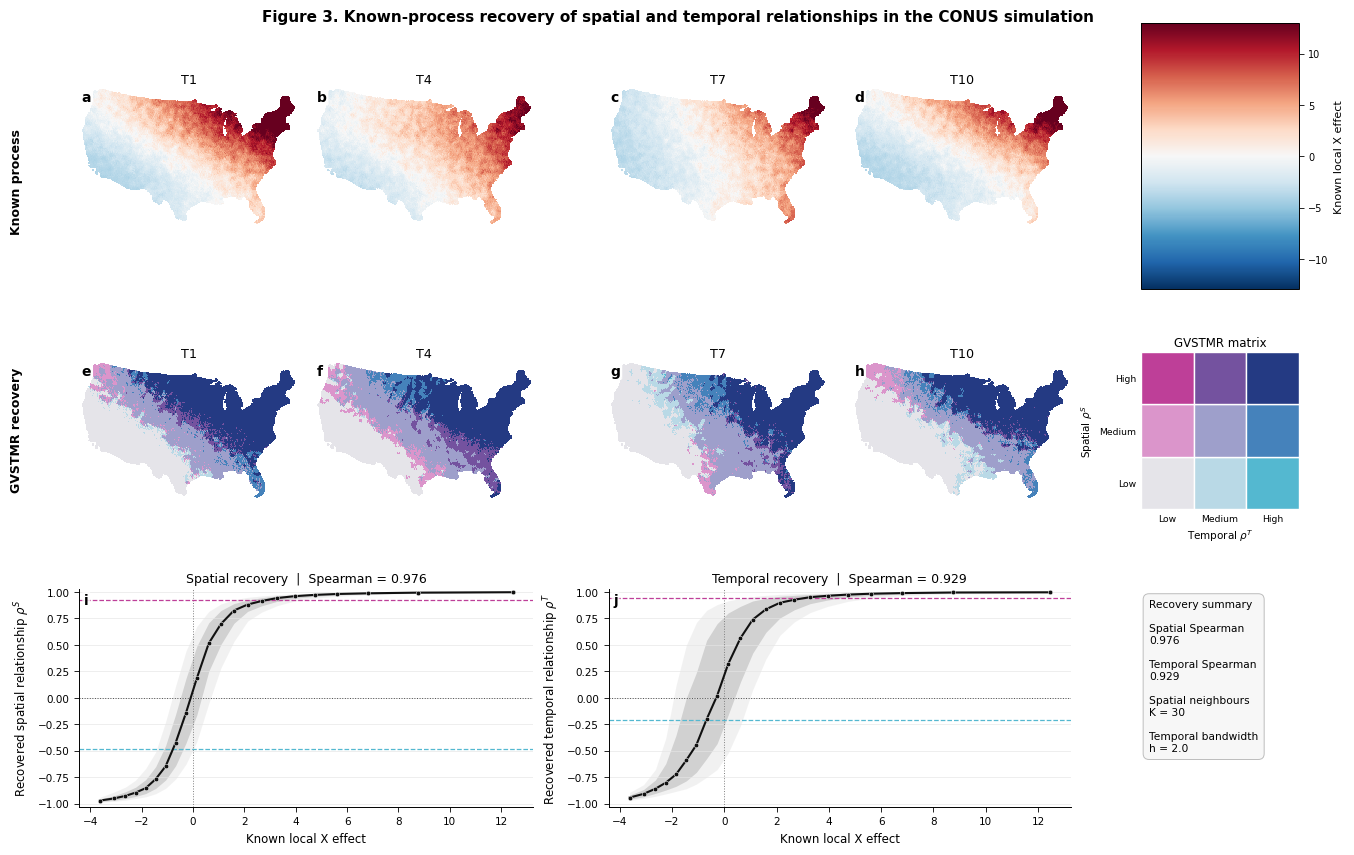


✅ FIGURE 3 FIXED
Removed polygon boundary overlay.
Disabled polygon antialias seams.
Replaced saturated hexbin with median + IQR + P10–P90 curves.
Output:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/FIGURES/PNG_600DPI/Figure_03_Simulation_Known_Process_Recovery_FIXED.png


In [ ]:
# ==========================================================================================
# FIGURE 3 — FIXED FINAL VERSION
#
# KNOWN-PROCESS RECOVERY IN THE CONUS SIMULATION
#
# FIXES:
#   ✓ removes erroneous polygon-boundary overlay
#   ✓ removes internal line / stripe artefacts
#   ✓ disables polygon antialias seams
#   ✓ uses the SAME scale for T1/T4/T7/T10
#   ✓ replaces saturated hexbin plots with binned median + IQR recovery curves
#   ✓ adds compact, separate legends
#   ✓ no overlapping titles / labels
#
# REPLACE THE OLD FIGURE-3 CELL WITH THIS WHOLE CELL
# ==========================================================================================

print("=" * 110)
print("FIGURE 3 — FIXED SIMULATION KNOWN-PROCESS RECOVERY")
print("=" * 110)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from scipy.stats import spearmanr


# ==========================================================================================
# 1. CHECK REQUIRED DATA
# ==========================================================================================

if "TRUE_BETA_X" not in SIM_DIRECT.columns:
    raise RuntimeError(
        "TRUE_BETA_X is missing from SIM_DIRECT."
    )

required_cols = [
    "HEX_ID",
    "TIME",
    "TRUE_BETA_X",
    "RHO_S",
    "RHO_T",
    "GV_CELL",
    "geometry",
]

missing = [
    c
    for c in required_cols
    if c not in SIM_DIRECT.columns
]

if missing:
    raise RuntimeError(
        f"Missing required columns: {missing}"
    )


DALL = SIM_DIRECT.loc[
    SIM_DIRECT["TIME"].isin(MAIN_SIM_TIMES)
].copy()


print(
    "Selected times:",
    MAIN_SIM_TIMES
)

print(
    "Hexes per time:",
    DALL.groupby("TIME")["HEX_ID"].nunique().to_dict()
)


# ==========================================================================================
# 2. CLEAN MAP HELPERS
#
# IMPORTANT:
# DO NOT plot SIM_BOUNDARY.boundary here.
#
# The filled hexagons already define the CONUS silhouette.
# ==========================================================================================

def clean_map_axis_v2(
    ax,
    bounds
):

    xmin, ymin, xmax, ymax = bounds

    dx = xmax - xmin
    dy = ymax - ymin

    ax.set_xlim(
        xmin - 0.015 * dx,
        xmax + 0.015 * dx
    )

    ax.set_ylim(
        ymin - 0.015 * dy,
        ymax + 0.015 * dy
    )

    ax.set_aspect(
        "equal"
    )

    ax.set_axis_off()


def clean_hex_plot(
    ax,
    gdf,
    colors,
    bounds
):
    """
    Plot polygons without internal edge/boundary artefacts.
    """

    gdf.plot(
        ax=ax,
        color=colors,

        # ------------------------------------------------------
        # CRITICAL CARTOGRAPHIC FIX
        # ------------------------------------------------------
        edgecolor="none",
        linewidth=0.0,
        antialiased=False,

        # Thousands of polygons are rasterized inside the PDF/SVG
        # to avoid hairline seams while labels remain vector.
        rasterized=True
    )

    # Make sure all collections remain seam-free.
    for collection in ax.collections:

        try:
            collection.set_edgecolor(
                "none"
            )
        except Exception:
            pass

        try:
            collection.set_linewidth(
                0.0
            )
        except Exception:
            pass

        try:
            collection.set_antialiased(
                False
            )
        except Exception:
            pass


    clean_map_axis_v2(
        ax,
        bounds
    )


def panel_label_v2(
    ax,
    label
):

    ax.text(
        0.01,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
        zorder=30,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.82,
            boxstyle="round,pad=0.12"
        )
    )


# ==========================================================================================
# 3. TRUE-EFFECT COLOR SCALE
#
# One common diverging range for all 4 simulation times.
# ==========================================================================================

beta_all = DALL[
    "TRUE_BETA_X"
].to_numpy(
    dtype=float
)

beta_all = beta_all[
    np.isfinite(beta_all)
]

q_low, q_high = np.percentile(
    beta_all,
    [
        2,
        98
    ]
)

beta_limit = max(
    abs(q_low),
    abs(q_high)
)

TRUE_NORM = TwoSlopeNorm(
    vmin=-beta_limit,
    vcenter=0.0,
    vmax=beta_limit
)

TRUE_CMAP = plt.get_cmap(
    "RdBu_r"
)


# ==========================================================================================
# 4. RECOVERY STATISTICS
# ==========================================================================================

rho_spatial = float(
    spearmanr(
        SIM_DIRECT[
            "TRUE_BETA_X"
        ],
        SIM_DIRECT[
            "RHO_S"
        ],
        nan_policy="omit"
    ).statistic
)

rho_temporal = float(
    spearmanr(
        SIM_DIRECT[
            "TRUE_BETA_X"
        ],
        SIM_DIRECT[
            "RHO_T"
        ],
        nan_policy="omit"
    ).statistic
)


print(
    f"Spatial recovery Spearman : {rho_spatial:.4f}"
)

print(
    f"Temporal recovery Spearman: {rho_temporal:.4f}"
)


# ==========================================================================================
# 5. BINNED RECOVERY FUNCTION
#
# Continuous TRUE_BETA_X gradient is divided into quantile bins.
# For each bin:
#
#   black point = median recovered relationship
#   dark band   = IQR
#   light band  = P10–P90
#
# This is much more publication-friendly than the previous saturated hexbin.
# ==========================================================================================

def recovery_gradient_panel(
    ax,
    data,
    response_col,
    title,
    low_threshold,
    high_threshold,
    n_bins=22
):

    D = data[
        [
            "TRUE_BETA_X",
            response_col
        ]
    ].dropna().copy()


    # ------------------------------------------------------------------
    # Quantile bins maintain comparable support.
    # ------------------------------------------------------------------

    D[
        "_BIN"
    ] = pd.qcut(
        D[
            "TRUE_BETA_X"
        ],
        q=n_bins,
        labels=False,
        duplicates="drop"
    )


    S = (
        D
        .groupby(
            "_BIN"
        )
        .agg(
            X_MED=(
                "TRUE_BETA_X",
                "median"
            ),

            Y_MED=(
                response_col,
                "median"
            ),

            Y_P10=(
                response_col,
                lambda x:
                    np.nanpercentile(
                        x,
                        10
                    )
            ),

            Y_P25=(
                response_col,
                lambda x:
                    np.nanpercentile(
                        x,
                        25
                    )
            ),

            Y_P75=(
                response_col,
                lambda x:
                    np.nanpercentile(
                        x,
                        75
                    )
            ),

            Y_P90=(
                response_col,
                lambda x:
                    np.nanpercentile(
                        x,
                        90
                    )
            ),

            N=(
                response_col,
                "size"
            )
        )
        .reset_index()
        .sort_values(
            "X_MED"
        )
    )


    x = S[
        "X_MED"
    ].to_numpy(
        float
    )


    # ------------------------------------------------------------------
    # P10–P90
    # ------------------------------------------------------------------

    ax.fill_between(
        x,
        S[
            "Y_P10"
        ],
        S[
            "Y_P90"
        ],
        color="#BDBDBD",
        alpha=0.20,
        linewidth=0,
        label="10–90%"
    )


    # ------------------------------------------------------------------
    # IQR
    # ------------------------------------------------------------------

    ax.fill_between(
        x,
        S[
            "Y_P25"
        ],
        S[
            "Y_P75"
        ],
        color="#737373",
        alpha=0.25,
        linewidth=0,
        label="IQR"
    )


    # ------------------------------------------------------------------
    # Median trajectory
    # ------------------------------------------------------------------

    ax.plot(
        x,
        S[
            "Y_MED"
        ],
        color="#111111",
        linewidth=1.5,
        marker="o",
        markersize=3.3,
        markerfacecolor="#111111",
        markeredgecolor="white",
        markeredgewidth=0.35,
        zorder=10,
        label="Median"
    )


    # ------------------------------------------------------------------
    # True-effect zero
    # ------------------------------------------------------------------

    ax.axvline(
        0,
        color="#7F7F7F",
        linewidth=0.7,
        linestyle=":"
    )


    # ------------------------------------------------------------------
    # Relationship zero
    # ------------------------------------------------------------------

    ax.axhline(
        0,
        color="#4D4D4D",
        linewidth=0.7,
        linestyle=":"
    )


    # ------------------------------------------------------------------
    # GVSTMR Low / Medium / High thresholds
    # ------------------------------------------------------------------

    ax.axhline(
        low_threshold,
        color="#54B8D0",
        linewidth=0.9,
        linestyle="--"
    )

    ax.axhline(
        high_threshold,
        color="#BE3F98",
        linewidth=0.9,
        linestyle="--"
    )


    ax.set_ylim(
        -1.03,
        1.03
    )


    ax.set_xlabel(
        "Known local X effect"
    )


    if response_col == "RHO_S":

        ax.set_ylabel(
            r"Recovered spatial relationship $\rho^S$"
        )

    else:

        ax.set_ylabel(
            r"Recovered temporal relationship $\rho^T$"
        )


    ax.set_title(
        title,
        fontsize=9.0,
        pad=5
    )


    ax.grid(
        axis="y",
        color="#E5E5E5",
        linewidth=0.45,
        zorder=0
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    return S


# ==========================================================================================
# 6. FIGURE LAYOUT
#
# 3 rows × 5 columns
#
# Row 1:
# true effect T1/T4/T7/T10 + colorbar
#
# Row 2:
# GVSTMR cell T1/T4/T7/T10 + 3×3 legend
#
# Row 3:
# spatial recovery + temporal recovery + summary
# ==========================================================================================

fig = plt.figure(
    figsize=(
        13.4,
        8.3
    ),
    constrained_layout=True
)


gs = GridSpec(
    3,
    5,
    figure=fig,

    width_ratios=[
        1,
        1,
        1,
        1,
        0.72
    ],

    height_ratios=[
        1.0,
        1.0,
        0.82
    ]
)


# ==========================================================================================
# 7. ROW 1 — TRUE LOCAL EFFECT
# ==========================================================================================

panel_labels = list(
    "abcdefghij"
)

p = 0


for j, t in enumerate(
    MAIN_SIM_TIMES
):

    D = DALL.loc[
        DALL[
            "TIME"
        ].eq(
            t
        )
    ].copy()


    values = D[
        "TRUE_BETA_X"
    ].to_numpy(
        dtype=float
    )


    colors = TRUE_CMAP(
        TRUE_NORM(
            values
        )
    )


    ax = fig.add_subplot(
        gs[
            0,
            j
        ]
    )


    clean_hex_plot(
        ax=ax,
        gdf=D,
        colors=colors,
        bounds=SIM_BOUNDS
    )


    ax.set_title(
        f"T{t}",
        fontsize=9.2,
        pad=3
    )


    panel_label_v2(
        ax,
        panel_labels[
            p
        ]
    )


    p += 1


# ==========================================================================================
# 8. TRUE-EFFECT COLORBAR — SEPARATE AXIS
# ==========================================================================================

cax = fig.add_subplot(
    gs[
        0,
        4
    ]
)


sm = ScalarMappable(
    norm=TRUE_NORM,
    cmap=TRUE_CMAP
)

sm.set_array([])


cb = fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)


cb.set_label(
    "Known local X effect",
    fontsize=8.0
)


cb.ax.tick_params(
    labelsize=7.0
)


# ==========================================================================================
# 9. ROW 2 — RECOVERED GVSTMR MATRIX CELLS
# ==========================================================================================

for j, t in enumerate(
    MAIN_SIM_TIMES
):

    D = DALL.loc[
        DALL[
            "TIME"
        ].eq(
            t
        )
    ].copy()


    colors = (
        D[
            "GV_CELL"
        ]
        .map(
            GV_PALETTE
        )
        .to_numpy()
    )


    ax = fig.add_subplot(
        gs[
            1,
            j
        ]
    )


    clean_hex_plot(
        ax=ax,
        gdf=D,
        colors=colors,
        bounds=SIM_BOUNDS
    )


    ax.set_title(
        f"T{t}",
        fontsize=9.2,
        pad=3
    )


    panel_label_v2(
        ax,
        panel_labels[
            p
        ]
    )


    p += 1


# ==========================================================================================
# 10. GVSTMR 3×3 LEGEND
# ==========================================================================================

ax_leg = fig.add_subplot(
    gs[
        1,
        4
    ]
)


ax_leg.set_xlim(
    0,
    3
)

ax_leg.set_ylim(
    0,
    3
)

ax_leg.set_aspect(
    "equal"
)


for spatial_level in [
    1,
    2,
    3
]:

    for temporal_level in [
        1,
        2,
        3
    ]:

        cell = (
            (
                spatial_level
                -
                1
            )
            *
            3
            +
            temporal_level
        )


        ax_leg.add_patch(
            Rectangle(
                (
                    temporal_level
                    -
                    1,

                    spatial_level
                    -
                    1
                ),
                1,
                1,
                facecolor=GV_PALETTE[
                    cell
                ],
                edgecolor="white",
                linewidth=1.0
            )
        )


ax_leg.set_xticks(
    [
        0.5,
        1.5,
        2.5
    ]
)

ax_leg.set_xticklabels(
    [
        "Low",
        "Medium",
        "High"
    ],
    fontsize=6.7
)


ax_leg.set_yticks(
    [
        0.5,
        1.5,
        2.5
    ]
)

ax_leg.set_yticklabels(
    [
        "Low",
        "Medium",
        "High"
    ],
    fontsize=6.7
)


ax_leg.set_xlabel(
    r"Temporal $\rho^T$",
    fontsize=7.5,
    labelpad=3
)

ax_leg.set_ylabel(
    r"Spatial $\rho^S$",
    fontsize=7.5,
    labelpad=3
)

ax_leg.set_title(
    "GVSTMR matrix",
    fontsize=8.5,
    pad=4
)

ax_leg.tick_params(
    length=0
)


for spine in ax_leg.spines.values():
    spine.set_visible(
        False
    )


# ==========================================================================================
# 11. ROW 3 — SPATIAL RECOVERY
# ==========================================================================================

ax_s = fig.add_subplot(
    gs[
        2,
        0:2
    ]
)


SPATIAL_BINNED = recovery_gradient_panel(
    ax=ax_s,
    data=SIM_DIRECT,
    response_col="RHO_S",
    title=(
        "Spatial recovery  |  "
        f"Spearman = {rho_spatial:.3f}"
    ),
    low_threshold=SIM_THRESHOLDS[
        "SPATIAL_LOW"
    ],
    high_threshold=SIM_THRESHOLDS[
        "SPATIAL_HIGH"
    ],
    n_bins=22
)


panel_label_v2(
    ax_s,
    "i"
)


# ==========================================================================================
# 12. ROW 3 — TEMPORAL RECOVERY
# ==========================================================================================

ax_t = fig.add_subplot(
    gs[
        2,
        2:4
    ]
)


TEMPORAL_BINNED = recovery_gradient_panel(
    ax=ax_t,
    data=SIM_DIRECT,
    response_col="RHO_T",
    title=(
        "Temporal recovery  |  "
        f"Spearman = {rho_temporal:.3f}"
    ),
    low_threshold=SIM_THRESHOLDS[
        "TEMPORAL_LOW"
    ],
    high_threshold=SIM_THRESHOLDS[
        "TEMPORAL_HIGH"
    ],
    n_bins=22
)


panel_label_v2(
    ax_t,
    "j"
)


# ==========================================================================================
# 13. SUMMARY BOX — SEPARATE FROM PLOTS
# ==========================================================================================

ax_info = fig.add_subplot(
    gs[
        2,
        4
    ]
)

ax_info.set_axis_off()


summary_text = (
    "Recovery summary\n\n"
    f"Spatial Spearman\n"
    f"{rho_spatial:.3f}\n\n"
    f"Temporal Spearman\n"
    f"{rho_temporal:.3f}\n\n"
    f"Spatial neighbours\n"
    f"K = {SIM_THRESHOLDS['K_SPATIAL']}\n\n"
    f"Temporal bandwidth\n"
    f"h = {SIM_THRESHOLDS['TEMPORAL_BANDWIDTH']}"
)


ax_info.text(
    0.05,
    0.95,
    summary_text,
    transform=ax_info.transAxes,
    ha="left",
    va="top",
    fontsize=7.7,
    linespacing=1.25,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#F7F7F7",
        edgecolor="#BDBDBD",
        linewidth=0.7
    )
)


# ==========================================================================================
# 14. ROW LABELS
# ==========================================================================================

fig.text(
    0.006,
    0.805,
    "Known process",
    rotation=90,
    ha="center",
    va="center",
    fontsize=9.0,
    fontweight="bold"
)


fig.text(
    0.006,
    0.505,
    "GVSTMR recovery",
    rotation=90,
    ha="center",
    va="center",
    fontsize=9.0,
    fontweight="bold"
)


# ==========================================================================================
# 15. TITLE
# ==========================================================================================

fig.suptitle(
    "Figure 3. Known-process recovery of spatial and temporal relationships in the CONUS simulation",
    fontsize=11.0,
    fontweight="bold",
    y=1.012
)


# ==========================================================================================
# 16. SAVE UNDER NEW NAME
# ==========================================================================================

save_figure(
    fig,
    "Figure_03_Simulation_Known_Process_Recovery_FIXED"
)


plt.show()

plt.close(
    fig
)


# ==========================================================================================
# 17. SAVE BINNED FIGURE DATA
# ==========================================================================================

SPATIAL_BINNED.to_csv(
    DATA_ROOT
    /
    "FIG03_SPATIAL_RECOVERY_BINNED.csv",
    index=False
)


TEMPORAL_BINNED.to_csv(
    DATA_ROOT
    /
    "FIG03_TEMPORAL_RECOVERY_BINNED.csv",
    index=False
)


print("\n" + "=" * 110)
print("✅ FIGURE 3 FIXED")
print("=" * 110)

print(
    "Removed polygon boundary overlay."
)

print(
    "Disabled polygon antialias seams."
)

print(
    "Replaced saturated hexbin with median + IQR + P10–P90 curves."
)

print(
    "Output:"
)

print(
    PNG_ROOT
    /
    "Figure_03_Simulation_Known_Process_Recovery_FIXED.png"
)

FIGURE 4 — FINAL LAYOUT FIX
Saved: Figure_04_GVSTMR_Simulation_and_Real_World_FINAL


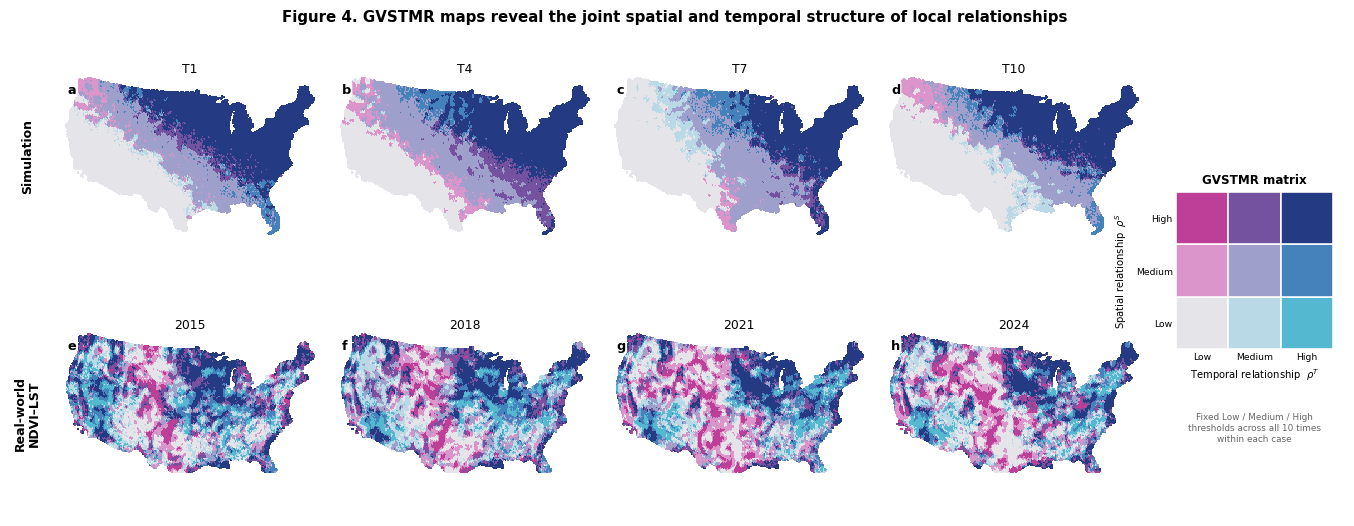


✅ FIGURE 4 — FINAL LAYOUT COMPLETE

Major fix:
Simulation and Real-world labels now occupy their OWN GridSpec column.
There is no fig.text() row-label positioning anymore.
Therefore row labels cannot overlap panels a/e.

Output:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/FIGURES/PNG_600DPI/Figure_04_GVSTMR_Simulation_and_Real_World_FINAL.png


In [ ]:
# ==========================================================================================
# FIGURE 4 — FINAL LAYOUT FIX
#
# GVSTMR SIGNATURE FIGURE
#
# FIX:
#   ✓ dedicated column for row labels
#   ✓ NO fig.text()
#   ✓ row labels can NEVER touch the maps
#   ✓ panel letters moved inside map panels
#   ✓ independent legend column
#   ✓ no polygon boundaries / seams
#   ✓ manually controlled margins and spacing
#
# ==========================================================================================

print("=" * 110)
print("FIGURE 4 — FINAL LAYOUT FIX")
print("=" * 110)

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

SIM_SHOW = [
    1,
    4,
    7,
    10
]

REAL_SHOW = [
    2015,
    2018,
    2021,
    2024
]


# ==========================================================================================
# 2. CLEAN HEX MAP
# ==========================================================================================

def fig04_clean_map(
    ax,
    gdf,
    column,
    palette,
    bounds
):

    colors = (
        gdf[
            column
        ]
        .map(
            palette
        )
        .fillna(
            "#EEEEEE"
        )
        .to_numpy()
    )


    gdf.plot(
        ax=ax,
        color=colors,

        # ------------------------------------------------------
        # No polygon-line artefacts
        # ------------------------------------------------------
        edgecolor="none",
        linewidth=0.0,
        antialiased=False,
        rasterized=True
    )


    # Extra insurance against seams.
    for collection in ax.collections:

        try:
            collection.set_edgecolor(
                "none"
            )
        except Exception:
            pass

        try:
            collection.set_linewidth(
                0
            )
        except Exception:
            pass

        try:
            collection.set_antialiased(
                False
            )
        except Exception:
            pass


    xmin, ymin, xmax, ymax = bounds

    dx = xmax - xmin
    dy = ymax - ymin


    ax.set_xlim(
        xmin - 0.012 * dx,
        xmax + 0.012 * dx
    )

    ax.set_ylim(
        ymin - 0.012 * dy,
        ymax + 0.012 * dy
    )


    ax.set_aspect(
        "equal"
    )

    ax.set_axis_off()


# ==========================================================================================
# 3. PANEL LETTER
#
# Put INSIDE panel instead of hanging outside.
# ==========================================================================================

def fig04_panel_label(
    ax,
    label
):

    ax.text(
        0.018,
        0.955,
        label,

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9.3,
        fontweight="bold",

        zorder=30,

        bbox=dict(
            boxstyle="round,pad=0.10",
            facecolor="white",
            edgecolor="none",
            alpha=0.82
        )
    )


# ==========================================================================================
# 4. ROW LABEL
#
# Uses a dedicated GridSpec cell.
# Therefore it cannot overlap the map.
# ==========================================================================================

def fig04_row_label(
    ax,
    text
):

    ax.set_axis_off()

    ax.text(
        0.52,
        0.50,

        text,

        transform=ax.transAxes,

        rotation=90,

        ha="center",
        va="center",

        fontsize=9.0,
        fontweight="bold",

        linespacing=1.12
    )


# ==========================================================================================
# 5. LEGEND FUNCTION
# ==========================================================================================

def fig04_matrix_legend(
    ax,
    palette
):

    ax.set_xlim(
        0,
        3
    )

    ax.set_ylim(
        0,
        3
    )

    ax.set_aspect(
        "equal"
    )


    for spatial_level in [
        1,
        2,
        3
    ]:

        for temporal_level in [
            1,
            2,
            3
        ]:

            cell = (
                (
                    spatial_level
                    -
                    1
                )
                *
                3
                +
                temporal_level
            )


            ax.add_patch(

                Rectangle(

                    (
                        temporal_level
                        -
                        1,

                        spatial_level
                        -
                        1
                    ),

                    1,
                    1,

                    facecolor=palette[
                        cell
                    ],

                    edgecolor="white",

                    linewidth=1.15
                )

            )


    # ------------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------------

    ax.set_xticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_xticklabels(
        [
            "Low",
            "Medium",
            "High"
        ],
        fontsize=6.7
    )


    ax.set_yticks(
        [
            0.5,
            1.5,
            2.5
        ]
    )

    ax.set_yticklabels(
        [
            "Low",
            "Medium",
            "High"
        ],
        fontsize=6.7
    )


    ax.tick_params(
        length=0,
        pad=2
    )


    ax.set_xlabel(
        r"Temporal relationship  $\rho^T$",
        fontsize=7.2,
        labelpad=4
    )


    ax.set_ylabel(
        r"Spatial relationship  $\rho^S$",
        fontsize=7.2,
        labelpad=5
    )


    ax.set_title(
        "GVSTMR matrix",
        fontsize=8.6,
        fontweight="bold",
        pad=6
    )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# ==========================================================================================
# 6. FIGURE
#
# IMPORTANT:
#
# Column 0 = ROW LABEL ONLY
# Column 1 = map 1
# Column 2 = map 2
# Column 3 = map 3
# Column 4 = map 4
# Column 5 = LEGEND ONLY
#
# Therefore no text can physically enter the map columns.
# ==========================================================================================

fig = plt.figure(
    figsize=(
        13.8,
        5.65
    )
)


gs = GridSpec(

    nrows=2,

    ncols=6,

    figure=fig,


    # ------------------------------------------------------------------
    # First column deliberately reserved for vertical row text.
    # ------------------------------------------------------------------

    width_ratios=[
        0.13,
        1.00,
        1.00,
        1.00,
        1.00,
        0.72
    ],


    height_ratios=[
        1,
        1
    ],


    # ------------------------------------------------------------------
    # Manually controlled figure margins.
    #
    # We do NOT use constrained_layout here.
    # ------------------------------------------------------------------

    left=0.018,

    right=0.985,

    bottom=0.075,

    top=0.895,

    wspace=0.095,

    hspace=0.24
)


# ==========================================================================================
# 7. DEDICATED ROW LABELS
# ==========================================================================================

ax_sim_label = fig.add_subplot(
    gs[
        0,
        0
    ]
)


fig04_row_label(
    ax_sim_label,
    "Simulation"
)


ax_real_label = fig.add_subplot(
    gs[
        1,
        0
    ]
)


fig04_row_label(
    ax_real_label,
    "Real-world\nNDVI–LST"
)


# ==========================================================================================
# 8. SIMULATION MAPS
# ==========================================================================================

panel_letters = [
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h"
]


panel_index = 0


for j, t in enumerate(
    SIM_SHOW
):

    D = SIM_DIRECT.loc[
        SIM_DIRECT[
            "TIME"
        ].eq(
            t
        )
    ].copy()


    ax = fig.add_subplot(
        gs[
            0,
            j + 1
        ]
    )


    fig04_clean_map(
        ax=ax,

        gdf=D,

        column="GV_CELL",

        palette=GV_PALETTE,

        bounds=SIM_BOUNDS
    )


    ax.set_title(
        f"T{t}",
        fontsize=8.9,
        pad=2.5
    )


    fig04_panel_label(
        ax,
        panel_letters[
            panel_index
        ]
    )


    panel_index += 1


# ==========================================================================================
# 9. REAL-WORLD MAPS
# ==========================================================================================

for j, year in enumerate(
    REAL_SHOW
):

    D = REAL_DIRECT.loc[
        REAL_DIRECT[
            "YEAR"
        ].eq(
            year
        )
    ].copy()


    ax = fig.add_subplot(
        gs[
            1,
            j + 1
        ]
    )


    fig04_clean_map(
        ax=ax,

        gdf=D,

        column="GV_CELL",

        palette=GV_PALETTE,

        bounds=REAL_BOUNDS
    )


    ax.set_title(
        str(
            year
        ),
        fontsize=8.9,
        pad=2.5
    )


    fig04_panel_label(
        ax,
        panel_letters[
            panel_index
        ]
    )


    panel_index += 1


# ==========================================================================================
# 10. LEGEND COLUMN
#
# Use the entire right column as a container.
# Matrix occupies only center section.
# ==========================================================================================

legend_container = fig.add_subplot(
    gs[
        :,
        5
    ]
)


legend_container.set_axis_off()


# ------------------------------------------------------------------------------------------
# Matrix itself
# ------------------------------------------------------------------------------------------

legend_ax = legend_container.inset_axes(
    [
        0.08,
        0.30,
        0.86,
        0.46
    ]
)


fig04_matrix_legend(
    legend_ax,
    GV_PALETTE
)


# ------------------------------------------------------------------------------------------
# Explanation BELOW matrix — with its own space.
# ------------------------------------------------------------------------------------------

legend_container.text(

    0.51,

    0.225,

    (
        "Fixed Low / Medium / High\n"
        "thresholds across all 10 times\n"
        "within each case"
    ),

    transform=legend_container.transAxes,

    ha="center",
    va="top",

    fontsize=6.4,

    color="#666666",

    linespacing=1.30
)


# ==========================================================================================
# 11. TITLE
#
# Separate from GridSpec using reserved top margin.
# ==========================================================================================

fig.suptitle(

    (
        "Figure 4. GVSTMR maps reveal the joint spatial and temporal "
        "structure of local relationships"
    ),

    fontsize=10.8,

    fontweight="bold",

    y=0.972
)


# ==========================================================================================
# 12. SAVE
# ==========================================================================================

save_figure(
    fig,
    "Figure_04_GVSTMR_Simulation_and_Real_World_FINAL"
)


plt.show()


plt.close(
    fig
)


print("\n" + "=" * 110)
print("✅ FIGURE 4 — FINAL LAYOUT COMPLETE")
print("=" * 110)


print(
    "\nMajor fix:"
)

print(
    "Simulation and Real-world labels now occupy their OWN GridSpec column."
)

print(
    "There is no fig.text() row-label positioning anymore."
)

print(
    "Therefore row labels cannot overlap panels a/e."
)

print(
    "\nOutput:"
)

print(
    PNG_ROOT
    /
    "Figure_04_GVSTMR_Simulation_and_Real_World_FINAL.png"
)

FIGURE 5 — YEAR COLORS FROM GVSTMR MATRIX
Saved: Figure_05_GVSTMR_Distributional_Structure_YEAR_COLORS


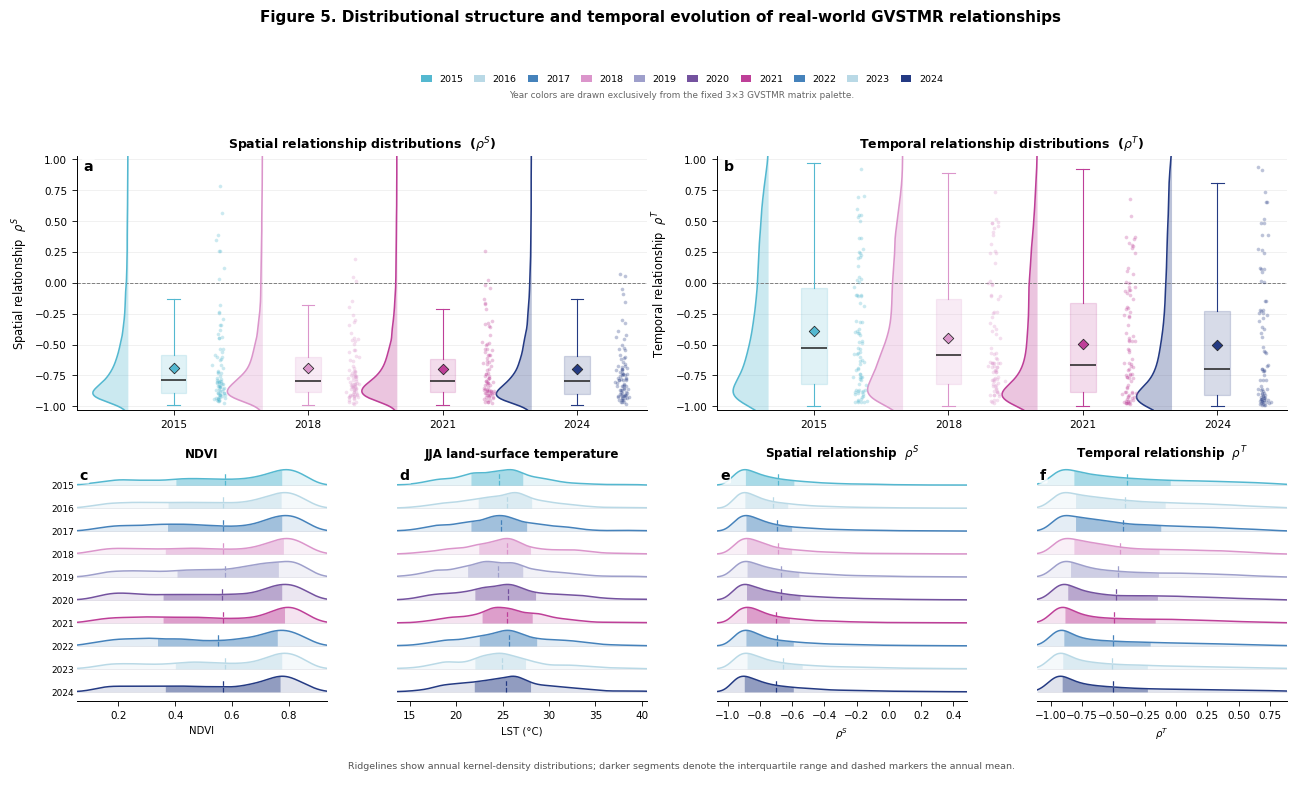


✅ FIGURE 5 — YEAR COLORS LOCKED

Main-year colors:
2015 #54B8D0
2018 #DB95CB
2021 #BE3F98
2024 #243A83

Saved year mapping:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/METADATA/GVSTMR_FIXED_YEAR_COLOR_MAPPING.csv

Figure:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/FIGURES/PNG_600DPI/Figure_05_GVSTMR_Distributional_Structure_YEAR_COLORS.png


In [ ]:
# ==========================================================================================
# FIGURE 5 — FINAL YEAR-COLOR VERSION
#
# KEY RULE:
#   YEAR = COLOR
#
# Every year receives one color taken ONLY from the master GVSTMR 3×3 palette.
# The same year keeps the same color in EVERY panel.
#
# Selected main years:
#   2015 = cyan
#   2018 = pink
#   2021 = magenta
#   2024 = dark blue
#
# Since 2015–2024 contains 10 years but the GVSTMR matrix contains 9 colors,
# one matrix color must necessarily be reused. Repetition is restricted to
# non-main years.
#
# ==========================================================================================

print("=" * 110)
print("FIGURE 5 — YEAR COLORS FROM GVSTMR MATRIX")
print("=" * 110)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

from scipy.stats import gaussian_kde


# ==========================================================================================
# 1. MASTER GVSTMR MATRIX PALETTE — LOCKED FOR PAPER
# ==========================================================================================

GV_PALETTE = {

    # Spatial Low
    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",

    # Spatial Medium
    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",

    # Spatial High
    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}


# ==========================================================================================
# 2. FIXED YEAR → GVSTMR COLOR MAPPING
#
# IMPORTANT:
# Keep this mapping for ALL subsequent figures whenever YEAR is encoded by color.
#
# All colors come directly from GV_PALETTE.
# ==========================================================================================

YEAR_COLOR = {

    2015: GV_PALETTE[3],   # cyan
    2016: GV_PALETTE[2],   # pale cyan
    2017: GV_PALETTE[6],   # blue

    2018: GV_PALETTE[4],   # pink
    2019: GV_PALETTE[5],   # lavender
    2020: GV_PALETTE[8],   # purple

    2021: GV_PALETTE[7],   # magenta
    2022: GV_PALETTE[6],   # blue — repeated non-main color
    2023: GV_PALETTE[2],   # pale cyan — repeated non-main color

    2024: GV_PALETTE[9],   # dark blue
}


# ==========================================================================================
# 3. DATA
# ==========================================================================================

D = REAL_DIRECT.copy()

D["YEAR"] = pd.to_numeric(
    D["YEAR"],
    errors="coerce"
).astype(int)


SELECTED_YEARS = [
    2015,
    2018,
    2021,
    2024
]


ALL_YEARS = list(
    range(
        2015,
        2025
    )
)


required = [
    "YEAR",
    "NDVI",
    "LST_MEAN_C",
    "RHO_S",
    "RHO_T",
]


missing = [
    c
    for c in required
    if c not in D.columns
]


if missing:

    raise RuntimeError(
        f"Missing Figure-5 fields: {missing}"
    )


# ==========================================================================================
# 4. SAFE KDE
# ==========================================================================================

def safe_kde(
    values,
    grid
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]


    if len(values) < 3:

        return np.zeros_like(
            grid,
            dtype=float
        )


    if np.std(values) < 1e-10:

        center = np.mean(values)

        width = max(
            abs(center) * 0.01,
            1e-3
        )

        return np.exp(
            -0.5 *
            (
                (grid - center)
                /
                width
            ) ** 2
        )


    try:

        return gaussian_kde(
            values
        )(
            grid
        )

    except Exception:

        center = np.median(values)

        width = max(
            np.std(values),
            1e-3
        )

        return np.exp(
            -0.5 *
            (
                (grid - center)
                /
                width
            ) ** 2
        )


# ==========================================================================================
# 5. PANEL LABEL
# ==========================================================================================

def panel_label(
    ax,
    label
):

    ax.text(

        0.012,
        0.985,

        label,

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=10.2,
        fontweight="bold",

        zorder=30,

        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.82,
            boxstyle="round,pad=0.10"
        )
    )


# ==========================================================================================
# 6. TOP PANELS
#
# Fire Fig.3 grammar:
#
# density + box + sampled observations + mean
#
# EACH YEAR GETS ITS OWN GVSTMR COLOR.
# ==========================================================================================

def density_box_points_panel(
    ax,
    data,
    value_col,
    years,
    title,
    ylabel,
    fixed_ylim=(-1.03, 1.03),
    seed=123
):

    local_rng = np.random.default_rng(
        seed
    )


    positions = np.arange(
        len(years)
    )


    y_grid = np.linspace(
        fixed_ylim[0],
        fixed_ylim[1],
        320
    )


    for i, year in enumerate(
        years
    ):

        values = (
            data.loc[
                data["YEAR"].eq(year),
                value_col
            ]
            .dropna()
            .to_numpy(float)
        )


        if len(values) < 5:

            continue


        # ------------------------------------------------------------------
        # THIS IS THE KEY CHANGE:
        # COLOR COMES FROM YEAR, NOT VARIABLE.
        # ------------------------------------------------------------------

        color = YEAR_COLOR[
            year
        ]


        # ------------------------------------------------------------------
        # KDE
        # ------------------------------------------------------------------

        density = safe_kde(
            values,
            y_grid
        )


        if density.max() > 0:

            density = (
                density
                /
                density.max()
                *
                0.26
            )


        anchor = (
            i
            -
            0.34
        )


        ax.fill_betweenx(

            y_grid,

            anchor
            -
            density,

            anchor,

            color=color,

            alpha=0.30,

            linewidth=0,

            zorder=2
        )


        ax.plot(

            anchor
            -
            density,

            y_grid,

            color=color,

            linewidth=1.15,

            zorder=3
        )


        # ------------------------------------------------------------------
        # BOX
        # ------------------------------------------------------------------

        box = ax.boxplot(

            [
                values
            ],

            positions=[
                i
            ],

            widths=0.19,

            patch_artist=True,

            showfliers=False,

            whis=1.5,

            manage_ticks=False,

            zorder=7
        )


        for patch in box[
            "boxes"
        ]:

            patch.set_facecolor(
                color
            )

            patch.set_alpha(
                0.18
            )

            patch.set_edgecolor(
                color
            )

            patch.set_linewidth(
                0.9
            )


        for whisker in box[
            "whiskers"
        ]:

            whisker.set_color(
                color
            )

            whisker.set_linewidth(
                0.8
            )


        for cap in box[
            "caps"
        ]:

            cap.set_color(
                color
            )

            cap.set_linewidth(
                0.8
            )


        for median in box[
            "medians"
        ]:

            median.set_color(
                "#202020"
            )

            median.set_linewidth(
                1.1
            )


        # ------------------------------------------------------------------
        # INDIVIDUAL HEXAGONS
        # ------------------------------------------------------------------

        n_show = min(
            85,
            len(values)
        )


        idx = local_rng.choice(
            len(values),
            size=n_show,
            replace=False
        )


        sample_values = values[
            idx
        ]


        jitter = local_rng.normal(
            0,
            0.020,
            size=n_show
        )


        ax.scatter(

            np.full(
                n_show,
                i + 0.34
            )
            +
            jitter,

            sample_values,

            s=7,

            facecolor=color,

            edgecolor="white",

            linewidth=0.18,

            alpha=0.30,

            rasterized=True,

            zorder=5
        )


        # ------------------------------------------------------------------
        # MEAN
        # ------------------------------------------------------------------

        ax.scatter(

            i,

            np.mean(values),

            marker="D",

            s=29,

            facecolor=color,

            edgecolor="#202020",

            linewidth=0.55,

            zorder=10
        )


    # ----------------------------------------------------------------------
    # AXIS
    # ----------------------------------------------------------------------

    ax.axhline(
        0,
        color="#777777",
        linestyle="--",
        linewidth=0.65
    )


    ax.set_xlim(
        -0.72,
        len(years)
        -
        0.48
    )


    ax.set_ylim(
        fixed_ylim
    )


    ax.set_xticks(
        positions
    )


    ax.set_xticklabels(
        [
            str(y)
            for y in years
        ],
        fontsize=7.7
    )


    ax.set_ylabel(
        ylabel,
        fontsize=8.3
    )


    ax.set_title(
        title,
        fontsize=9.0,
        fontweight="bold",
        pad=5
    )


    ax.grid(
        axis="y",
        color="#EAEAEA",
        linewidth=0.45,
        zorder=0
    )


    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )


# ==========================================================================================
# 7. RIDGELINE PANELS
#
# SAME YEAR = SAME COLOR in NDVI, LST, rhoS and rhoT.
# ==========================================================================================

def ridgeline_panel(
    ax,
    data,
    value_col,
    years,
    title,
    xlabel,
    show_year_labels=True,
    qrange=(1, 99)
):

    all_values = (
        data[
            value_col
        ]
        .dropna()
        .to_numpy(float)
    )


    lo, hi = np.percentile(
        all_values,
        qrange
    )


    span = (
        hi - lo
    )


    if span <= 0:

        span = 1


    xmin = (
        lo
        -
        0.07 * span
    )

    xmax = (
        hi
        +
        0.07 * span
    )


    x_grid = np.linspace(
        xmin,
        xmax,
        450
    )


    for row_i, year in enumerate(
        years
    ):

        values = (
            data.loc[
                data["YEAR"].eq(year),
                value_col
            ]
            .dropna()
            .to_numpy(float)
        )


        base = (
            len(years)
            -
            1
            -
            row_i
        )


        # ------------------------------------------------------------------
        # SAME YEAR COLOR IN EVERY RIDGELINE PANEL
        # ------------------------------------------------------------------

        color = YEAR_COLOR[
            year
        ]


        density = safe_kde(
            values,
            x_grid
        )


        if density.max() > 0:

            density = (
                density
                /
                density.max()
                *
                0.68
            )


        # ------------------------------------------------------------------
        # BASELINE
        # ------------------------------------------------------------------

        ax.hlines(

            base,

            xmin,

            xmax,

            color="#E5E4E9",

            linewidth=0.50,

            zorder=0
        )


        # ------------------------------------------------------------------
        # FULL DISTRIBUTION
        # ------------------------------------------------------------------

        ax.fill_between(

            x_grid,

            base,

            base + density,

            color=color,

            alpha=0.14,

            linewidth=0,

            zorder=1
        )


        ax.plot(

            x_grid,

            base + density,

            color=color,

            linewidth=1.10,

            alpha=1.0,

            zorder=3
        )


        # ------------------------------------------------------------------
        # IQR
        # ------------------------------------------------------------------

        q25, q75 = np.percentile(
            values,
            [
                25,
                75
            ]
        )


        mask = (
            (x_grid >= q25)
            &
            (x_grid <= q75)
        )


        ax.fill_between(

            x_grid[
                mask
            ],

            base,

            base
            +
            density[
                mask
            ],

            color=color,

            alpha=0.42,

            linewidth=0,

            zorder=2
        )


        # ------------------------------------------------------------------
        # MEAN
        # ------------------------------------------------------------------

        mean_value = float(
            np.mean(values)
        )


        ax.vlines(

            mean_value,

            base,

            base + 0.53,

            color=color,

            linestyle="--",

            linewidth=0.90,

            zorder=4
        )


    # ----------------------------------------------------------------------
    # AXIS
    # ----------------------------------------------------------------------

    ax.set_xlim(
        xmin,
        xmax
    )


    ax.set_ylim(
        -0.38,
        len(years) - 0.10
    )


    ax.set_yticks(
        np.arange(
            len(years)
        )
    )


    if show_year_labels:

        ax.set_yticklabels(

            [
                str(y)
                for y in reversed(
                    years
                )
            ],

            fontsize=6.5
        )

    else:

        ax.set_yticklabels(
            []
        )


    ax.set_xlabel(
        xlabel,
        fontsize=7.3,
        labelpad=4
    )


    ax.set_title(
        title,
        fontsize=8.6,
        fontweight="bold",
        pad=5
    )


    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.spines["left"].set_visible(
        False
    )


    ax.tick_params(
        axis="y",
        length=0,
        pad=2
    )


# ==========================================================================================
# 8. FIGURE LAYOUT
#
# row 0 = YEAR COLOR LEGEND
# row 1 = top Fire-Fig.3-style panels
# row 2 = Fire-Fig.4-style ridgelines
# row 3 = note
# ==========================================================================================

fig = plt.figure(

    figsize=(
        13.2,
        8.35
    )
)


gs = GridSpec(

    nrows=4,

    ncols=4,

    figure=fig,

    height_ratios=[
        0.15,
        1.10,
        1.02,
        0.09
    ],

    left=0.058,

    right=0.975,

    bottom=0.055,

    top=0.905,

    wspace=0.28,

    hspace=0.40
)


# ==========================================================================================
# 9. YEAR COLOR LEGEND
# ==========================================================================================

ax_legend = fig.add_subplot(
    gs[
        0,
        :
    ]
)


ax_legend.set_axis_off()


year_handles = [

    Patch(

        facecolor=YEAR_COLOR[
            year
        ],

        edgecolor="none",

        label=str(
            year
        )
    )

    for year in ALL_YEARS
]


ax_legend.legend(

    handles=year_handles,

    loc="center",

    ncol=10,

    frameon=False,

    fontsize=6.8,

    handlelength=1.15,

    handleheight=0.75,

    columnspacing=1.15,

    bbox_to_anchor=(
        0.50,
        0.62
    )
)


ax_legend.text(

    0.50,

    0.05,

    "Year colors are drawn exclusively from the fixed 3×3 GVSTMR matrix palette.",

    transform=ax_legend.transAxes,

    ha="center",

    va="bottom",

    fontsize=6.4,

    color="#666666"
)


# ==========================================================================================
# 10. TOP a — SPATIAL
# ==========================================================================================

ax_a = fig.add_subplot(
    gs[
        1,
        0:2
    ]
)


density_box_points_panel(

    ax=ax_a,

    data=D,

    value_col="RHO_S",

    years=SELECTED_YEARS,

    title=r"Spatial relationship distributions  ($\rho^S$)",

    ylabel=r"Spatial relationship  $\rho^S$",

    seed=123
)


panel_label(
    ax_a,
    "a"
)


# ==========================================================================================
# 11. TOP b — TEMPORAL
# ==========================================================================================

ax_b = fig.add_subplot(
    gs[
        1,
        2:4
    ]
)


density_box_points_panel(

    ax=ax_b,

    data=D,

    value_col="RHO_T",

    years=SELECTED_YEARS,

    title=r"Temporal relationship distributions  ($\rho^T$)",

    ylabel=r"Temporal relationship  $\rho^T$",

    seed=456
)


panel_label(
    ax_b,
    "b"
)


# ==========================================================================================
# 12. RIDGELINES
# ==========================================================================================

RIDGE_SPECS = [

    (
        "NDVI",
        "NDVI",
        "NDVI"
    ),

    (
        "LST_MEAN_C",
        "JJA land-surface temperature",
        "LST (°C)"
    ),

    (
        "RHO_S",
        r"Spatial relationship  $\rho^S$",
        r"$\rho^S$"
    ),

    (
        "RHO_T",
        r"Temporal relationship  $\rho^T$",
        r"$\rho^T$"
    ),
]


letters = [
    "c",
    "d",
    "e",
    "f"
]


for j, (
    variable,
    title,
    xlabel
) in enumerate(
    RIDGE_SPECS
):

    ax = fig.add_subplot(
        gs[
            2,
            j
        ]
    )


    ridgeline_panel(

        ax=ax,

        data=D,

        value_col=variable,

        years=ALL_YEARS,

        title=title,

        xlabel=xlabel,

        # Only first panel needs year text.
        show_year_labels=(
            j == 0
        )
    )


    panel_label(
        ax,
        letters[
            j
        ]
    )


# ==========================================================================================
# 13. BOTTOM NOTE
# ==========================================================================================

ax_note = fig.add_subplot(
    gs[
        3,
        :
    ]
)


ax_note.set_axis_off()


ax_note.text(

    0.50,

    0.50,

    (
        "Ridgelines show annual kernel-density distributions; "
        "darker segments denote the interquartile range and "
        "dashed markers the annual mean."
    ),

    transform=ax_note.transAxes,

    ha="center",

    va="center",

    fontsize=6.8,

    color="#555555"
)


# ==========================================================================================
# 14. TITLE
# ==========================================================================================

fig.suptitle(

    (
        "Figure 5. Distributional structure and temporal evolution "
        "of real-world GVSTMR relationships"
    ),

    fontsize=11.0,

    fontweight="bold",

    y=0.973
)


# ==========================================================================================
# 15. SAVE
# ==========================================================================================

save_figure(

    fig,

    "Figure_05_GVSTMR_Distributional_Structure_YEAR_COLORS"
)


plt.show()

plt.close(
    fig
)


# ==========================================================================================
# 16. SAVE YEAR COLOR MAP
#
# USE THIS IN FIGURES 6–11.
# ==========================================================================================

YEAR_COLOR_TABLE = pd.DataFrame({

    "YEAR":
        ALL_YEARS,

    "COLOR":
        [
            YEAR_COLOR[
                y
            ]
            for y in ALL_YEARS
        ]
})


YEAR_COLOR_TABLE.to_csv(

    META_ROOT
    /
    "GVSTMR_FIXED_YEAR_COLOR_MAPPING.csv",

    index=False
)


print("\n" + "=" * 110)
print("✅ FIGURE 5 — YEAR COLORS LOCKED")
print("=" * 110)


print("\nMain-year colors:")

for year in SELECTED_YEARS:

    print(
        year,
        YEAR_COLOR[
            year
        ]
    )


print(
    "\nSaved year mapping:"
)

print(
    META_ROOT
    /
    "GVSTMR_FIXED_YEAR_COLOR_MAPPING.csv"
)


print(
    "\nFigure:"
)

print(
    PNG_ROOT
    /
    "Figure_05_GVSTMR_Distributional_Structure_YEAR_COLORS.png"
)

FIGURE 6 — TEMPORAL COVARIANCE GEOMETRY
Saved: Figure_06_GVSTMR_Temporal_Covariance_Ellipses_LINKEDIN_STYLE


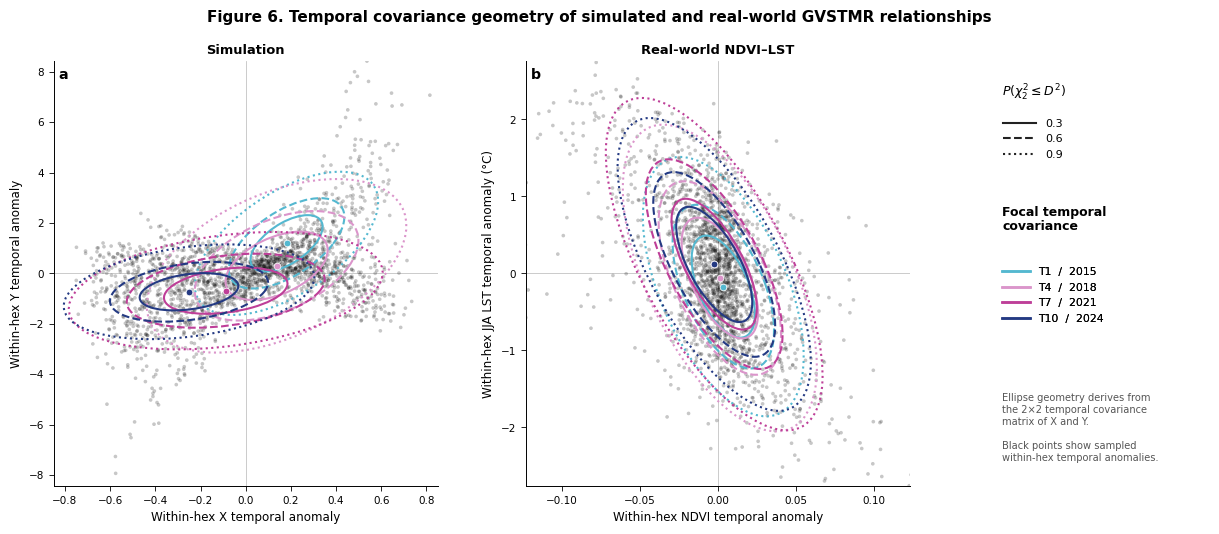


✅ FIGURE 6 — LINKEDIN-STYLE TEMPORAL COVARIANCE COMPLETE

Simulation covariance:


,CASE,FOCAL_TIME,N_HEX,CENTER_X,CENTER_Y,VAR_X_TEMPORAL,COV_XY_TEMPORAL,VAR_Y_TEMPORAL,TEMPORAL_CORRELATION,TEMPORAL_BANDWIDTH
0,Simulation,1,12864,0.180764,1.192796,0.035722,0.146212,1.753447,0.584210,2.0
1,Simulation,4,12864,0.136818,0.301078,0.071607,0.198669,2.574794,0.462681,2.0
2,Simulation,7,12864,-0.088336,-0.686400,0.104771,0.107773,1.177441,0.306844,2.0
3,Simulation,10,12864,-0.250896,-0.728923,0.066814,0.069483,0.767038,0.306930,2.0



Real-world covariance:


,CASE,FOCAL_TIME,N_HEX,CENTER_X,CENTER_Y,VAR_X_TEMPORAL,COV_XY_TEMPORAL,VAR_Y_TEMPORAL,TEMPORAL_CORRELATION,TEMPORAL_BANDWIDTH
4,Real-world NDVI-LST,2015,12553,0.003444,-0.171751,0.000576,-0.010095,0.615655,-0.536181,2.0
5,Real-world NDVI-LST,2018,12553,0.001218,-0.060052,0.000839,-0.015649,0.860597,-0.582497,2.0
6,Real-world NDVI-LST,2021,12553,-0.002394,0.119999,0.001046,-0.021756,1.010551,-0.669114,2.0
7,Real-world NDVI-LST,2024,12553,-0.002369,0.116274,0.000832,-0.016976,0.784344,-0.664721,2.0



Figure:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/FIGURES/PNG_600DPI/Figure_06_GVSTMR_Temporal_Covariance_Ellipses_LINKEDIN_STYLE.png


In [ ]:
# ==========================================================================================
# FIGURE 6 — FINAL LINKEDIN-STYLE TEMPORAL COVARIANCE ELLIPSES
#
# THIS REPLACES THE OLD rhoT-vs-rhoS RESPONSE-SPACE FIGURE.
#
# VISUAL DESIGN:
#   Same grammar as the LinkedIn covariance-ellipse example:
#
#   • black observations
#   • covariance ellipses
#   • solid / dashed / dotted probability contours:
#         0.30 / 0.60 / 0.90
#   • ellipse color = focal time
#   • legend in an independent right-hand column
#
# SCIENTIFIC INTERPRETATION:
#
# Simulation:
#     within-hex temporal anomaly of X vs temporal anomaly of Y
#
# Real-world:
#     within-hex temporal anomaly of NDVI vs temporal anomaly of JJA LST
#
# For every focal time:
#     1) Gaussian temporal weights, h = 2
#     2) local temporal covariance matrix for EVERY hexagon
#     3) mean covariance matrix across CONUS
#     4) 30%, 60%, 90% probability ellipses
#
# ==========================================================================================


print("=" * 110)
print("FIGURE 6 — TEMPORAL COVARIANCE GEOMETRY")
print("=" * 110)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse, Patch
from matplotlib.lines import Line2D

from scipy.stats import chi2


# ==========================================================================================
# 1. MASTER GVSTMR PALETTE
# ==========================================================================================

GV_PALETTE = {

    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",

    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",

    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}


# ==========================================================================================
# 2. FIXED SELECTED-TIME COLORS
#
# SAME COLOR MEANS THE SAME RELATIVE POSITION IN BOTH CASES.
#
# T1  <-> 2015
# T4  <-> 2018
# T7  <-> 2021
# T10 <-> 2024
# ==========================================================================================

TIME_COLORS_SIM = {

    1:
        GV_PALETTE[3],     # cyan

    4:
        GV_PALETTE[4],     # pink

    7:
        GV_PALETTE[7],     # magenta

    10:
        GV_PALETTE[9],     # dark blue
}


TIME_COLORS_REAL = {

    2015:
        GV_PALETTE[3],

    2018:
        GV_PALETTE[4],

    2021:
        GV_PALETTE[7],

    2024:
        GV_PALETTE[9],
}


SIM_SELECTED = [
    1,
    4,
    7,
    10
]


REAL_SELECTED = [
    2015,
    2018,
    2021,
    2024
]


# ==========================================================================================
# 3. PROBABILITY CONTOURS
#
# Same visual logic as supplied LinkedIn example.
# ==========================================================================================

PROBABILITY_LEVELS = {

    0.30:
        "-",

    0.60:
        "--",

    0.90:
        ":",
}


# ==========================================================================================
# 4. TEMPORAL BANDWIDTH
#
# Same temporal bandwidth used by direct GVSTMR.
# ==========================================================================================

H_TEMPORAL = 2.0


# ==========================================================================================
# 5. BUILD COMPLETE HEX × TIME MATRICES
# ==========================================================================================

def build_complete_temporal_matrix(
    data,
    time_col,
    x_col,
    y_col,
    times
):

    D = data[
        [
            "HEX_ID",
            time_col,
            x_col,
            y_col
        ]
    ].copy()


    D[
        "HEX_ID"
    ] = D[
        "HEX_ID"
    ].astype(
        str
    )


    # --------------------------------------------------------------------------------------
    # Complete temporal records only.
    # --------------------------------------------------------------------------------------

    coverage = (

        D.groupby(
            "HEX_ID"
        )

        .agg(

            N_TIME=(
                time_col,
                "nunique"
            ),

            NX=(
                x_col,
                lambda x:
                    int(
                        x.notna().sum()
                    )
            ),

            NY=(
                y_col,
                lambda x:
                    int(
                        x.notna().sum()
                    )
            )
        )
    )


    valid_ids = coverage.index[

        (
            coverage[
                "N_TIME"
            ].eq(
                len(
                    times
                )
            )
        )

        &

        (
            coverage[
                "NX"
            ].eq(
                len(
                    times
                )
            )
        )

        &

        (
            coverage[
                "NY"
            ].eq(
                len(
                    times
                )
            )
        )

    ].astype(
        str
    ).tolist()


    D = D.loc[
        D[
            "HEX_ID"
        ].isin(
            valid_ids
        )
    ].copy()


    order = sorted(
        valid_ids
    )


    X = (

        D.pivot(
            index=time_col,
            columns="HEX_ID",
            values=x_col
        )

        .loc[
            times,
            order
        ]

        .to_numpy(
            float
        )
    )


    Y = (

        D.pivot(
            index=time_col,
            columns="HEX_ID",
            values=y_col
        )

        .loc[
            times,
            order
        ]

        .to_numpy(
            float
        )
    )


    return (
        X,
        Y,
        order
    )


# ==========================================================================================
# 6. TEMPORAL ANOMALIES
#
# Remove each hexagon's 10-time baseline.
#
# This isolates WITHIN-HEX temporal co-variation instead of allowing
# between-region spatial differences to dominate the covariance ellipse.
# ==========================================================================================

def temporal_anomalies(
    X,
    Y
):

    X = np.asarray(
        X,
        dtype=float
    )


    Y = np.asarray(
        Y,
        dtype=float
    )


    X_anom = (

        X

        -
        np.mean(
            X,
            axis=0,
            keepdims=True
        )
    )


    Y_anom = (

        Y

        -
        np.mean(
            Y,
            axis=0,
            keepdims=True
        )
    )


    return (
        X_anom,
        Y_anom
    )


# ==========================================================================================
# 7. LOCAL TEMPORAL COVARIANCE MATRICES
#
# For focal time t:
#
#   w_j(t) = exp[-0.5 ((time_j - t)/h)^2]
#
# For every hex i:
#
#   Sigma_i,t =
#
#   [ Var_T(X)    Cov_T(X,Y) ]
#   [ Cov_T(X,Y)  Var_T(Y)   ]
#
# Then calculate the arithmetic mean of all local PSD covariance matrices.
# ==========================================================================================

def temporal_covariance_at_focal_time(
    X_anom,
    Y_anom,
    times,
    focal_time,
    bandwidth=2.0
):

    times_numeric = np.asarray(
        times,
        dtype=float
    )


    focal_numeric = float(
        focal_time
    )


    # --------------------------------------------------------------------------------------
    # Gaussian temporal weights.
    # --------------------------------------------------------------------------------------

    weights = np.exp(

        -0.5

        *

        (
            (
                times_numeric
                -
                focal_numeric
            )

            /
            float(
                bandwidth
            )
        ) ** 2
    )


    weights = (

        weights

        /
        weights.sum()
    )


    # --------------------------------------------------------------------------------------
    # Weighted local mean for every hex.
    # --------------------------------------------------------------------------------------

    mean_x = np.sum(

        weights[
            :,
            None
        ]

        *
        X_anom,

        axis=0
    )


    mean_y = np.sum(

        weights[
            :,
            None
        ]

        *
        Y_anom,

        axis=0
    )


    dx = (

        X_anom

        -
        mean_x[
            None,
            :
        ]
    )


    dy = (

        Y_anom

        -
        mean_y[
            None,
            :
        ]
    )


    # --------------------------------------------------------------------------------------
    # LOCAL weighted variances / covariance.
    # --------------------------------------------------------------------------------------

    var_x = np.sum(

        weights[
            :,
            None
        ]

        *
        dx ** 2,

        axis=0
    )


    var_y = np.sum(

        weights[
            :,
            None
        ]

        *
        dy ** 2,

        axis=0
    )


    cov_xy = np.sum(

        weights[
            :,
            None
        ]

        *
        dx
        *
        dy,

        axis=0
    )


    # --------------------------------------------------------------------------------------
    # National summary:
    # arithmetic mean of local covariance matrices.
    #
    # Average of PSD covariance matrices remains PSD.
    # --------------------------------------------------------------------------------------

    cov_matrix = np.array(

        [

            [
                np.mean(
                    var_x
                ),

                np.mean(
                    cov_xy
                )
            ],

            [
                np.mean(
                    cov_xy
                ),

                np.mean(
                    var_y
                )
            ]

        ],

        dtype=float
    )


    # --------------------------------------------------------------------------------------
    # Mean location of local weighted centers.
    # --------------------------------------------------------------------------------------

    center = np.array(

        [

            np.mean(
                mean_x
            ),

            np.mean(
                mean_y
            )

        ],

        dtype=float
    )


    # --------------------------------------------------------------------------------------
    # Correlation implied by covariance matrix.
    # --------------------------------------------------------------------------------------

    denominator = np.sqrt(

        cov_matrix[
            0,
            0
        ]

        *

        cov_matrix[
            1,
            1
        ]
    )


    if denominator > 0:

        correlation = (

            cov_matrix[
                0,
                1
            ]

            /
            denominator
        )

    else:

        correlation = np.nan


    return {

        "CENTER":
            center,

        "COV":
            cov_matrix,

        "CORR":
            float(
                correlation
            ),

        "WEIGHTS":
            weights,

        "N_HEX":
            X_anom.shape[
                1
            ],
    }


# ==========================================================================================
# 8. DRAW PROBABILITY ELLIPSE FROM 2×2 COVARIANCE MATRIX
#
# Ellipse:
#
# (z - mu)' Sigma^-1 (z - mu) = chi2.ppf(p, df=2)
#
# ==========================================================================================

def add_covariance_ellipse(
    ax,
    center,
    covariance,
    probability,
    color,
    linestyle,
    linewidth=1.45
):

    covariance = np.asarray(
        covariance,
        dtype=float
    )


    # --------------------------------------------------------------------------------------
    # Eigen decomposition.
    # --------------------------------------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance
    )


    order = np.argsort(
        eigenvalues
    )[
        ::-1
    ]


    eigenvalues = eigenvalues[
        order
    ]


    eigenvectors = eigenvectors[
        :,
        order
    ]


    # Numerical insurance.
    eigenvalues = np.clip(
        eigenvalues,
        1e-12,
        None
    )


    # --------------------------------------------------------------------------------------
    # Probability radius.
    # --------------------------------------------------------------------------------------

    radius2 = chi2.ppf(
        probability,
        df=2
    )


    width = (

        2

        *
        np.sqrt(
            eigenvalues[
                0
            ]
            *
            radius2
        )
    )


    height = (

        2

        *
        np.sqrt(
            eigenvalues[
                1
            ]
            *
            radius2
        )
    )


    angle = np.degrees(

        np.arctan2(

            eigenvectors[
                1,
                0
            ],

            eigenvectors[
                0,
                0
            ]
        )
    )


    ellipse = Ellipse(

        xy=(
            center[
                0
            ],
            center[
                1
            ]
        ),

        width=width,

        height=height,

        angle=angle,

        facecolor="none",

        edgecolor=color,

        linestyle=linestyle,

        linewidth=linewidth,

        zorder=8
    )


    ax.add_patch(
        ellipse
    )


    return ellipse


# ==========================================================================================
# 9. PREPARE SIMULATION MATRICES
# ==========================================================================================

SIM_TIMES_ALL = list(
    range(
        1,
        11
    )
)


SIM_X, SIM_Y, SIM_IDS = build_complete_temporal_matrix(

    data=SIM_DIRECT,

    time_col="TIME",

    x_col="X",

    y_col="Y",

    times=SIM_TIMES_ALL
)


SIM_XA, SIM_YA = temporal_anomalies(
    SIM_X,
    SIM_Y
)


# ==========================================================================================
# 10. PREPARE REAL-WORLD MATRICES
# ==========================================================================================

REAL_YEARS_ALL = list(
    range(
        2015,
        2025
    )
)


REAL_X, REAL_Y, REAL_IDS = build_complete_temporal_matrix(

    data=REAL_DIRECT,

    time_col="YEAR",

    x_col="NDVI",

    y_col="LST_MEAN_C",

    times=REAL_YEARS_ALL
)


REAL_XA, REAL_YA = temporal_anomalies(
    REAL_X,
    REAL_Y
)


# ==========================================================================================
# 11. COMPUTE SELECTED TEMPORAL COVARIANCE MATRICES
# ==========================================================================================

SIM_COV_RESULTS = {

    t:
        temporal_covariance_at_focal_time(

            X_anom=SIM_XA,

            Y_anom=SIM_YA,

            times=SIM_TIMES_ALL,

            focal_time=t,

            bandwidth=H_TEMPORAL
        )

    for t in SIM_SELECTED
}


REAL_COV_RESULTS = {

    year:
        temporal_covariance_at_focal_time(

            X_anom=REAL_XA,

            Y_anom=REAL_YA,

            times=REAL_YEARS_ALL,

            focal_time=year,

            bandwidth=H_TEMPORAL
        )

    for year in REAL_SELECTED
}


# ==========================================================================================
# 12. POOLED BACKGROUND POINTS
#
# Exactly as in the reference visual:
# black observations behind colored covariance ellipses.
# ==========================================================================================

def sample_temporal_anomaly_points(
    X_anom,
    Y_anom,
    n_points,
    seed
):

    x = X_anom.ravel()
    y = Y_anom.ravel()


    valid = (

        np.isfinite(
            x
        )

        &

        np.isfinite(
            y
        )
    )


    x = x[
        valid
    ]


    y = y[
        valid
    ]


    rng_local = np.random.default_rng(
        seed
    )


    n = min(
        n_points,
        len(
            x
        )
    )


    idx = rng_local.choice(

        len(
            x
        ),

        size=n,

        replace=False
    )


    return (
        x[
            idx
        ],
        y[
            idx
        ]
    )


SIM_PX, SIM_PY = sample_temporal_anomaly_points(

    SIM_XA,

    SIM_YA,

    n_points=2200,

    seed=123
)


REAL_PX, REAL_PY = sample_temporal_anomaly_points(

    REAL_XA,

    REAL_YA,

    n_points=2200,

    seed=456
)


# ==========================================================================================
# 13. AXIS LIMITS INCLUDING OUTER 90% ELLIPSES
# ==========================================================================================

def covariance_plot_limits(
    px,
    py,
    covariance_results
):

    x_lo, x_hi = np.percentile(
        px,
        [
            0.5,
            99.5
        ]
    )


    y_lo, y_hi = np.percentile(
        py,
        [
            0.5,
            99.5
        ]
    )


    q90 = chi2.ppf(
        0.90,
        df=2
    )


    for result in covariance_results.values():

        center = result[
            "CENTER"
        ]


        cov = result[
            "COV"
        ]


        # Projection of Mahalanobis ellipse on axes.
        rx = np.sqrt(

            q90

            *
            cov[
                0,
                0
            ]
        )


        ry = np.sqrt(

            q90

            *
            cov[
                1,
                1
            ]
        )


        x_lo = min(
            x_lo,
            center[
                0
            ]
            -
            1.08
            *
            rx
        )


        x_hi = max(
            x_hi,
            center[
                0
            ]
            +
            1.08
            *
            rx
        )


        y_lo = min(
            y_lo,
            center[
                1
            ]
            -
            1.08
            *
            ry
        )


        y_hi = max(
            y_hi,
            center[
                1
            ]
            +
            1.08
            *
            ry
        )


    # --------------------------------------------------------------------------------------
    # Symmetric anomaly axes around zero.
    # --------------------------------------------------------------------------------------

    xmax = max(
        abs(
            x_lo
        ),
        abs(
            x_hi
        )
    )


    ymax = max(
        abs(
            y_lo
        ),
        abs(
            y_hi
        )
    )


    return (

        (
            -xmax,
            xmax
        ),

        (
            -ymax,
            ymax
        )
    )


SIM_XLIM, SIM_YLIM = covariance_plot_limits(

    SIM_PX,
    SIM_PY,
    SIM_COV_RESULTS
)


REAL_XLIM, REAL_YLIM = covariance_plot_limits(

    REAL_PX,
    REAL_PY,
    REAL_COV_RESULTS
)


# ==========================================================================================
# 14. LINKEDIN-STYLE PANEL
# ==========================================================================================

def covariance_panel(
    ax,
    px,
    py,
    results,
    color_map,
    title,
    xlabel,
    ylabel,
    xlim,
    ylim
):

    # --------------------------------------------------------------------------------------
    # Raw observations.
    # --------------------------------------------------------------------------------------

    ax.scatter(

        px,

        py,

        s=7,

        facecolor="black",

        edgecolor="none",

        alpha=0.22,

        rasterized=True,

        zorder=2
    )


    # --------------------------------------------------------------------------------------
    # Ellipse families.
    # --------------------------------------------------------------------------------------

    for focal_time, result in results.items():

        color = color_map[
            focal_time
        ]


        center = result[
            "CENTER"
        ]


        covariance = result[
            "COV"
        ]


        for probability, linestyle in PROBABILITY_LEVELS.items():

            add_covariance_ellipse(

                ax=ax,

                center=center,

                covariance=covariance,

                probability=probability,

                color=color,

                linestyle=linestyle,

                linewidth=1.50
            )


        # ----------------------------------------------------------------------------------
        # Covariance center.
        # ----------------------------------------------------------------------------------

        ax.scatter(

            center[
                0
            ],

            center[
                1
            ],

            s=23,

            facecolor=color,

            edgecolor="white",

            linewidth=0.55,

            zorder=12
        )


    # --------------------------------------------------------------------------------------
    # Zero-anomaly reference.
    # --------------------------------------------------------------------------------------

    ax.axhline(

        0,

        color="#BDBDBD",

        linewidth=0.55,

        linestyle="-",

        zorder=0
    )


    ax.axvline(

        0,

        color="#BDBDBD",

        linewidth=0.55,

        linestyle="-",

        zorder=0
    )


    ax.set_xlim(
        xlim
    )


    ax.set_ylim(
        ylim
    )


    ax.set_xlabel(
        xlabel,
        fontsize=8.6
    )


    ax.set_ylabel(
        ylabel,
        fontsize=8.6
    )


    ax.set_title(

        title,

        fontsize=9.4,

        fontweight="bold",

        pad=5
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


# ==========================================================================================
# 15. FIGURE LAYOUT
#
# panel a = Simulation
# panel b = Real-world
# panel c = dedicated LinkedIn-style legend
# ==========================================================================================

fig = plt.figure(

    figsize=(
        12.7,
        5.7
    )
)


gs = GridSpec(

    nrows=1,

    ncols=3,

    figure=fig,

    width_ratios=[
        1.00,
        1.00,
        0.55
    ],

    left=0.070,

    right=0.980,

    bottom=0.13,

    top=0.875,

    wspace=0.27
)


# ==========================================================================================
# 16. PANEL a — SIMULATION
# ==========================================================================================

ax_a = fig.add_subplot(
    gs[
        0,
        0
    ]
)


covariance_panel(

    ax=ax_a,

    px=SIM_PX,

    py=SIM_PY,

    results=SIM_COV_RESULTS,

    color_map=TIME_COLORS_SIM,

    title="Simulation",

    xlabel="Within-hex X temporal anomaly",

    ylabel="Within-hex Y temporal anomaly",

    xlim=SIM_XLIM,

    ylim=SIM_YLIM
)


panel_label(
    ax_a,
    "a"
)


# ==========================================================================================
# 17. PANEL b — REAL-WORLD NDVI–LST
# ==========================================================================================

ax_b = fig.add_subplot(
    gs[
        0,
        1
    ]
)


covariance_panel(

    ax=ax_b,

    px=REAL_PX,

    py=REAL_PY,

    results=REAL_COV_RESULTS,

    color_map=TIME_COLORS_REAL,

    title="Real-world NDVI–LST",

    xlabel="Within-hex NDVI temporal anomaly",

    ylabel="Within-hex JJA LST temporal anomaly (°C)",

    xlim=REAL_XLIM,

    ylim=REAL_YLIM
)


panel_label(
    ax_b,
    "b"
)


# ==========================================================================================
# 18. DEDICATED LEGEND PANEL
#
# This mimics the reference figure:
#
# first:
#     probability / line-style legend
#
# second:
#     temporal covariance / color legend
# ==========================================================================================

ax_leg = fig.add_subplot(
    gs[
        0,
        2
    ]
)


ax_leg.set_axis_off()


# ------------------------------------------------------------------------------------------
# Probability contour legend
# ------------------------------------------------------------------------------------------

ax_leg.text(

    0.02,

    0.95,

    r"$P(\chi^2_2 \leq D^2)$",

    transform=ax_leg.transAxes,

    ha="left",

    va="top",

    fontsize=9.0,

    fontweight="bold"
)


prob_handles = [

    Line2D(

        [
            0
        ],

        [
            0
        ],

        color="#222222",

        linewidth=1.5,

        linestyle=PROBABILITY_LEVELS[
            p
        ],

        label=f"{p:.1f}"
    )

    for p in [
        0.30,
        0.60,
        0.90
    ]
]


leg1 = ax_leg.legend(

    handles=prob_handles,

    loc="upper left",

    bbox_to_anchor=(
        0.00,
        0.875
    ),

    frameon=False,

    fontsize=8.0,

    handlelength=3.0,

    borderaxespad=0
)


ax_leg.add_artist(
    leg1
)


# ------------------------------------------------------------------------------------------
# Time-color legend
# ------------------------------------------------------------------------------------------

ax_leg.text(

    0.02,

    0.66,

    "Focal temporal\ncovariance",

    transform=ax_leg.transAxes,

    ha="left",

    va="top",

    fontsize=9.0,

    fontweight="bold",

    linespacing=1.15
)


time_handles = [

    Line2D(

        [
            0
        ],

        [
            0
        ],

        color=TIME_COLORS_SIM[
            t
        ],

        linewidth=1.8,

        linestyle="-",

        label=(
            f"T{t}  /  "
            f"{REAL_SELECTED[i]}"
        )
    )

    for i, t in enumerate(
        SIM_SELECTED
    )
]


leg2 = ax_leg.legend(

    handles=time_handles,

    loc="upper left",

    bbox_to_anchor=(
        0.00,
        0.525
    ),

    frameon=False,

    fontsize=7.8,

    handlelength=2.5,

    borderaxespad=0
)


ax_leg.add_artist(
    leg2
)


# ------------------------------------------------------------------------------------------
# Method interpretation
# ------------------------------------------------------------------------------------------

ax_leg.text(

    0.02,

    0.22,

    (
        "Ellipse geometry derives from\n"
        "the 2×2 temporal covariance\n"
        "matrix of X and Y.\n\n"
        "Black points show sampled\n"
        "within-hex temporal anomalies."
    ),

    transform=ax_leg.transAxes,

    ha="left",

    va="top",

    fontsize=7.1,

    color="#555555",

    linespacing=1.25
)


# ==========================================================================================
# 19. TITLE
# ==========================================================================================

fig.suptitle(

    (
        "Figure 6. Temporal covariance geometry of simulated and "
        "real-world GVSTMR relationships"
    ),

    fontsize=11.0,

    fontweight="bold",

    y=0.965
)


# ==========================================================================================
# 20. SAVE FIGURE
# ==========================================================================================

save_figure(

    fig,

    "Figure_06_GVSTMR_Temporal_Covariance_Ellipses_LINKEDIN_STYLE"
)


plt.show()


plt.close(
    fig
)


# ==========================================================================================
# 21. SAVE ACTUAL MATRICES / CORRELATIONS
#
# Useful for Methods, Results, caption and Supplementary Material.
# ==========================================================================================

summary_rows = []


for case_name, results in [

    (
        "Simulation",
        SIM_COV_RESULTS
    ),

    (
        "Real-world NDVI-LST",
        REAL_COV_RESULTS
    )
]:

    for focal_time, result in results.items():

        cov = result[
            "COV"
        ]


        center = result[
            "CENTER"
        ]


        summary_rows.append({

            "CASE":
                case_name,

            "FOCAL_TIME":
                focal_time,

            "N_HEX":
                result[
                    "N_HEX"
                ],

            "CENTER_X":
                center[
                    0
                ],

            "CENTER_Y":
                center[
                    1
                ],

            "VAR_X_TEMPORAL":
                cov[
                    0,
                    0
                ],

            "COV_XY_TEMPORAL":
                cov[
                    0,
                    1
                ],

            "VAR_Y_TEMPORAL":
                cov[
                    1,
                    1
                ],

            "TEMPORAL_CORRELATION":
                result[
                    "CORR"
                ],

            "TEMPORAL_BANDWIDTH":
                H_TEMPORAL,
        })


FIG06_SUMMARY = pd.DataFrame(
    summary_rows
)


FIG06_SUMMARY.to_csv(

    DATA_ROOT
    /
    "FIG06_TEMPORAL_COVARIANCE_MATRICES.csv",

    index=False
)


print("\n" + "=" * 110)
print("✅ FIGURE 6 — LINKEDIN-STYLE TEMPORAL COVARIANCE COMPLETE")
print("=" * 110)


print(
    "\nSimulation covariance:"
)

display(

    FIG06_SUMMARY.loc[
        FIG06_SUMMARY[
            "CASE"
        ].eq(
            "Simulation"
        )
    ]
)


print(
    "\nReal-world covariance:"
)

display(

    FIG06_SUMMARY.loc[
        FIG06_SUMMARY[
            "CASE"
        ].eq(
            "Real-world NDVI-LST"
        )
    ]
)


print(
    "\nFigure:"
)

print(

    PNG_ROOT
    /
    "Figure_06_GVSTMR_Temporal_Covariance_Ellipses_LINKEDIN_STYLE.png"
)

FIGURE 7 — CONTINUOUS GRADIENT TRANSLATION — FIXED
Saved: Figure_07_Environmental_Gradient_to_GVSTMR_FINAL


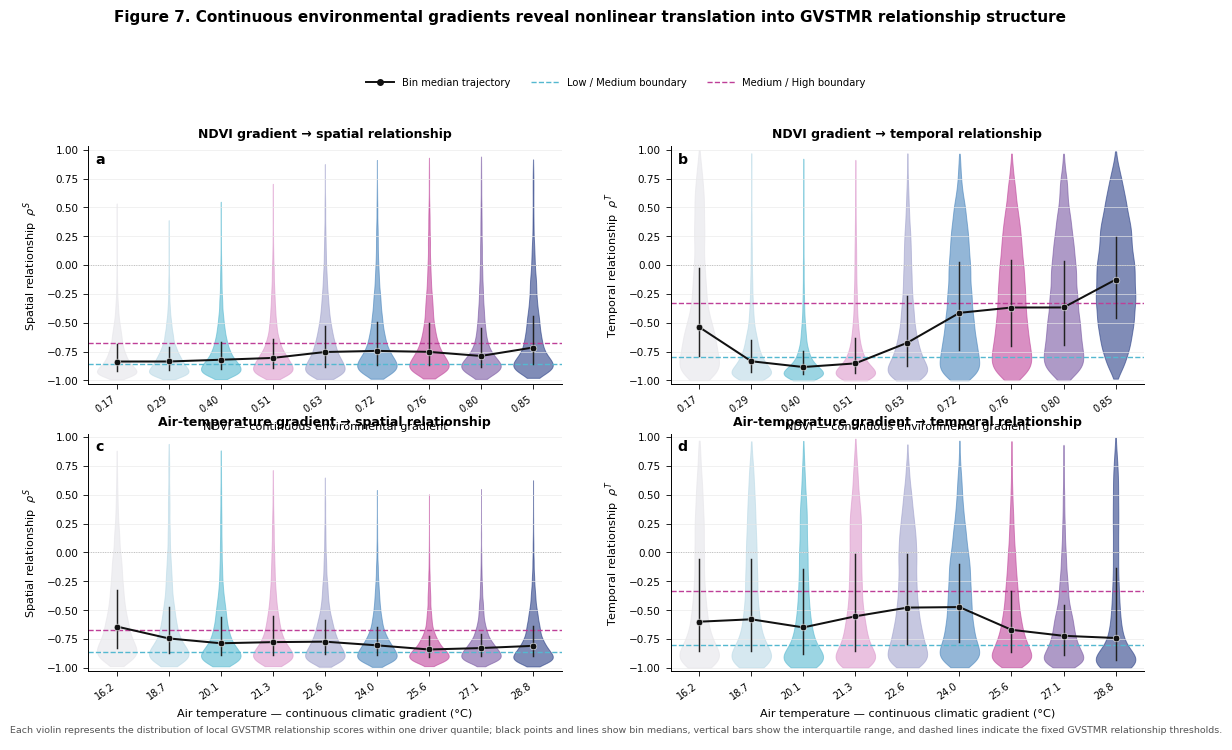


✅ FIGURE 7 COMPLETE

MathText labels:
Spatial: $\rho^S$
Temporal: $\rho^T$

9 driver bins = 9 fixed GVSTMR colors.

Figure:
/content/GVSTMR_CARTOGRAPHY_MAIN_FIGURES/FIGURES/PNG_600DPI/Figure_07_Environmental_Gradient_to_GVSTMR_FINAL.png


In [ ]:
# ==========================================================================================
# FIGURE 7 — FINAL FIXED VERSION
#
# CONTINUOUS ENVIRONMENTAL GRADIENTS → GVSTMR RELATIONSHIP TRANSLATION
#
# VISUAL LOGIC:
#   Fire-paper Figure 11 style
#
#   a) NDVI gradient     → spatial relationship rhoS
#   b) NDVI gradient     → temporal relationship rhoT
#   c) TEMP_C gradient   → spatial relationship rhoS
#   d) TEMP_C gradient   → temporal relationship rhoT
#
# EACH DRIVER IS DIVIDED INTO 9 QUANTILE BINS.
# THE 9 BINS USE THE EXACT 9 COLORS OF THE GVSTMR MATRIX.
#
# IMPORTANT FIX:
#   No string replacement for MathText labels.
#   Labels are written explicitly:
#       r"$\rho^S$"
#       r"$\rho^T$"
#
# ==========================================================================================

print("=" * 110)
print("FIGURE 7 — CONTINUOUS GRADIENT TRANSLATION — FIXED")
print("=" * 110)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ==========================================================================================
# 1. MASTER GVSTMR PALETTE
# ==========================================================================================

GV_PALETTE = {

    # Spatial Low
    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",

    # Spatial Medium
    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",

    # Spatial High
    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}


BIN_COLORS = [
    GV_PALETTE[i]
    for i in range(
        1,
        10
    )
]


# ==========================================================================================
# 2. DATA
# ==========================================================================================

D = REAL_DIRECT.copy()


required = [
    "NDVI",
    "TEMP_C",
    "RHO_S",
    "RHO_T",
]


missing = [
    c
    for c in required
    if c not in D.columns
]


if missing:

    raise RuntimeError(
        f"Figure 7 missing required columns: {missing}\n"
        f"Available columns:\n{list(D.columns)}"
    )


# ==========================================================================================
# 3. PANEL LABEL
# ==========================================================================================

def fig07_panel_label(
    ax,
    label
):

    ax.text(

        0.015,
        0.975,

        label,

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=10.2,
        fontweight="bold",

        zorder=30,

        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.84,
            boxstyle="round,pad=0.10"
        )
    )


# ==========================================================================================
# 4. GRADIENT TRANSLATION PANEL
#
# Driver:
#   divided into 9 fixed quantile bins
#
# For each bin:
#   violin   = distribution of local relationship score
#   dot      = median
#   black line = median trajectory
#   vertical bar = IQR
#
# Horizontal dashed lines:
#   fixed Low/Medium/High GVSTMR relationship thresholds
# ==========================================================================================

def gradient_translation_panel(
    ax,
    data,
    driver_col,
    response_col,
    title,
    xlabel,
    ylabel,
    threshold_low,
    threshold_high,
    n_bins=9
):

    DD = data[
        [
            driver_col,
            response_col
        ]
    ].dropna().copy()


    # --------------------------------------------------------------------------------------
    # 9 quantile bins -> 9 GVSTMR colors
    # --------------------------------------------------------------------------------------

    DD[
        "_BIN"
    ] = pd.qcut(

        DD[
            driver_col
        ],

        q=n_bins,

        labels=False,

        duplicates="drop"
    )


    bins = sorted(
        DD[
            "_BIN"
        ].dropna().unique()
    )


    if len(
        bins
    ) != 9:

        raise RuntimeError(
            f"{driver_col}: expected 9 quantile bins but obtained {len(bins)}."
        )


    positions = np.arange(
        1,
        10
    )


    distributions = []

    driver_median = []

    response_median = []

    response_q25 = []

    response_q75 = []

    support = []


    for b in bins:

        subset = DD.loc[
            DD[
                "_BIN"
            ].eq(
                b
            )
        ]


        values = subset[
            response_col
        ].to_numpy(
            float
        )


        distributions.append(
            values
        )


        driver_median.append(

            float(
                subset[
                    driver_col
                ].median()
            )
        )


        response_median.append(

            float(
                np.median(
                    values
                )
            )
        )


        response_q25.append(

            float(
                np.percentile(
                    values,
                    25
                )
            )
        )


        response_q75.append(

            float(
                np.percentile(
                    values,
                    75
                )
            )
        )


        support.append(
            len(
                values
            )
        )


    # ======================================================================================
    # VIOLINS
    # ======================================================================================

    vp = ax.violinplot(

        distributions,

        positions=positions,

        widths=0.76,

        showmeans=False,

        showmedians=False,

        showextrema=False,

        points=150
    )


    for i, body in enumerate(
        vp[
            "bodies"
        ]
    ):

        body.set_facecolor(
            BIN_COLORS[
                i
            ]
        )

        body.set_edgecolor(
            BIN_COLORS[
                i
            ]
        )

        body.set_linewidth(
            0.70
        )

        body.set_alpha(
            0.58
        )


    # ======================================================================================
    # IQR + MEDIAN
    # ======================================================================================

    for i, x in enumerate(
        positions
    ):

        # IQR
        ax.plot(

            [
                x,
                x
            ],

            [
                response_q25[
                    i
                ],
                response_q75[
                    i
                ]
            ],

            color="#222222",

            linewidth=1.05,

            zorder=8
        )


        # Median
        ax.scatter(

            x,

            response_median[
                i
            ],

            s=23,

            facecolor="#111111",

            edgecolor="white",

            linewidth=0.40,

            zorder=10
        )


    # ======================================================================================
    # BLACK MEDIAN TRAJECTORY
    # ======================================================================================

    ax.plot(

        positions,

        response_median,

        color="#111111",

        linewidth=1.45,

        marker="o",

        markersize=3.3,

        markerfacecolor="#111111",

        markeredgecolor="white",

        markeredgewidth=0.35,

        zorder=9
    )


    # ======================================================================================
    # FIXED GVSTMR THRESHOLDS
    # ======================================================================================

    ax.axhline(

        threshold_low,

        color=GV_PALETTE[
            3
        ],

        linewidth=1.0,

        linestyle="--",

        zorder=1
    )


    ax.axhline(

        threshold_high,

        color=GV_PALETTE[
            7
        ],

        linewidth=1.0,

        linestyle="--",

        zorder=1
    )


    # Zero relationship
    ax.axhline(

        0,

        color="#666666",

        linewidth=0.65,

        linestyle=":",

        zorder=1
    )


    # ======================================================================================
    # X LABELS = DRIVER MEDIAN OF EACH BIN
    # ======================================================================================

    if driver_col == "NDVI":

        tick_labels = [
            f"{v:.2f}"
            for v in driver_median
        ]

    else:

        tick_labels = [
            f"{v:.1f}"
            for v in driver_median
        ]


    ax.set_xticks(
        positions
    )


    ax.set_xticklabels(

        tick_labels,

        rotation=35,

        ha="right",

        fontsize=7.0
    )


    ax.set_xlim(
        0.45,
        9.55
    )


    ax.set_ylim(
        -1.03,
        1.03
    )


    # ======================================================================================
    # AXIS LABELS — EXPLICIT VALID MATHTEXT
    # ======================================================================================

    ax.set_xlabel(

        xlabel,

        fontsize=8.1,

        labelpad=5
    )


    ax.set_ylabel(

        ylabel,

        fontsize=8.1,

        labelpad=5
    )


    ax.set_title(

        title,

        fontsize=9.0,

        fontweight="bold",

        pad=6
    )


    ax.grid(

        axis="y",

        color="#E9E9E9",

        linewidth=0.45,

        zorder=0
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    # ======================================================================================
    # SAVE TABLE FOR THIS PANEL
    # ======================================================================================

    summary = pd.DataFrame({

        "BIN":
            np.arange(
                1,
                10
            ),

        "DRIVER":
            driver_col,

        "RESPONSE":
            response_col,

        "DRIVER_MEDIAN":
            driver_median,

        "RHO_P25":
            response_q25,

        "RHO_MEDIAN":
            response_median,

        "RHO_P75":
            response_q75,

        "N":
            support,

        "COLOR":
            BIN_COLORS,
    })


    return summary


# ==========================================================================================
# 5. FIGURE LAYOUT
#
# row 0 = independent legend / explanation
# row 1 = NDVI -> rhoS / rhoT
# row 2 = TEMP -> rhoS / rhoT
# row 3 = note
# ==========================================================================================

fig = plt.figure(

    figsize=(
        11.8,
        8.0
    )
)


gs = GridSpec(

    nrows=4,

    ncols=2,

    figure=fig,

    height_ratios=[
        0.12,
        1,
        1,
        0.08
    ],

    left=0.075,

    right=0.970,

    bottom=0.060,

    top=0.900,

    wspace=0.23,

    hspace=0.38
)


# ==========================================================================================
# 6. LEGEND ROW
# ==========================================================================================

ax_leg = fig.add_subplot(
    gs[
        0,
        :
    ]
)


ax_leg.set_axis_off()


legend_handles = [

    Line2D(

        [0],
        [0],

        color="#111111",

        marker="o",

        markersize=4,

        linewidth=1.4,

        label="Bin median trajectory"
    ),


    Line2D(

        [0],
        [0],

        color=GV_PALETTE[
            3
        ],

        linestyle="--",

        linewidth=1.0,

        label="Low / Medium boundary"
    ),


    Line2D(

        [0],
        [0],

        color=GV_PALETTE[
            7
        ],

        linestyle="--",

        linewidth=1.0,

        label="Medium / High boundary"
    ),
]


ax_leg.legend(

    handles=legend_handles,

    loc="center",

    ncol=3,

    frameon=False,

    fontsize=7.2,

    handlelength=2.8,

    columnspacing=2.0
)


# ==========================================================================================
# 7. a — NDVI → SPATIAL
# ==========================================================================================

ax_a = fig.add_subplot(
    gs[
        1,
        0
    ]
)


TABLE_A = gradient_translation_panel(

    ax=ax_a,

    data=D,

    driver_col="NDVI",

    response_col="RHO_S",

    title="NDVI gradient → spatial relationship",

    xlabel="NDVI — continuous environmental gradient",

    # ------------------------------------------------------------------
    # VALID MATHTEXT
    # ------------------------------------------------------------------

    ylabel=r"Spatial relationship  $\rho^S$",

    threshold_low=REAL_THRESHOLDS[
        "SPATIAL_LOW"
    ],

    threshold_high=REAL_THRESHOLDS[
        "SPATIAL_HIGH"
    ]
)


fig07_panel_label(
    ax_a,
    "a"
)


# ==========================================================================================
# 8. b — NDVI → TEMPORAL
# ==========================================================================================

ax_b = fig.add_subplot(
    gs[
        1,
        1
    ]
)


TABLE_B = gradient_translation_panel(

    ax=ax_b,

    data=D,

    driver_col="NDVI",

    response_col="RHO_T",

    title="NDVI gradient → temporal relationship",

    xlabel="NDVI — continuous environmental gradient",

    # ------------------------------------------------------------------
    # VALID MATHTEXT
    # ------------------------------------------------------------------

    ylabel=r"Temporal relationship  $\rho^T$",

    threshold_low=REAL_THRESHOLDS[
        "TEMPORAL_LOW"
    ],

    threshold_high=REAL_THRESHOLDS[
        "TEMPORAL_HIGH"
    ]
)


fig07_panel_label(
    ax_b,
    "b"
)


# ==========================================================================================
# 9. c — AIR TEMPERATURE → SPATIAL
# ==========================================================================================

ax_c = fig.add_subplot(
    gs[
        2,
        0
    ]
)


TABLE_C = gradient_translation_panel(

    ax=ax_c,

    data=D,

    driver_col="TEMP_C",

    response_col="RHO_S",

    title="Air-temperature gradient → spatial relationship",

    xlabel="Air temperature — continuous climatic gradient (°C)",

    ylabel=r"Spatial relationship  $\rho^S$",

    threshold_low=REAL_THRESHOLDS[
        "SPATIAL_LOW"
    ],

    threshold_high=REAL_THRESHOLDS[
        "SPATIAL_HIGH"
    ]
)


fig07_panel_label(
    ax_c,
    "c"
)


# ==========================================================================================
# 10. d — AIR TEMPERATURE → TEMPORAL
# ==========================================================================================

ax_d = fig.add_subplot(
    gs[
        2,
        1
    ]
)


TABLE_D = gradient_translation_panel(

    ax=ax_d,

    data=D,

    driver_col="TEMP_C",

    response_col="RHO_T",

    title="Air-temperature gradient → temporal relationship",

    xlabel="Air temperature — continuous climatic gradient (°C)",

    ylabel=r"Temporal relationship  $\rho^T$",

    threshold_low=REAL_THRESHOLDS[
        "TEMPORAL_LOW"
    ],

    threshold_high=REAL_THRESHOLDS[
        "TEMPORAL_HIGH"
    ]
)


fig07_panel_label(
    ax_d,
    "d"
)


# ==========================================================================================
# 11. NOTE ROW
# ==========================================================================================

ax_note = fig.add_subplot(
    gs[
        3,
        :
    ]
)


ax_note.set_axis_off()


ax_note.text(

    0.50,

    0.50,

    (
        "Each violin represents the distribution of local GVSTMR relationship scores "
        "within one driver quantile; black points and lines show bin medians, "
        "vertical bars show the interquartile range, and dashed lines indicate "
        "the fixed GVSTMR relationship thresholds."
    ),

    transform=ax_note.transAxes,

    ha="center",

    va="center",

    fontsize=6.8,

    color="#555555"
)


# ==========================================================================================
# 12. TITLE
# ==========================================================================================

fig.suptitle(

    (
        "Figure 7. Continuous environmental gradients reveal "
        "nonlinear translation into GVSTMR relationship structure"
    ),

    fontsize=11.0,

    fontweight="bold",

    y=0.973
)


# ==========================================================================================
# 13. SAVE
# ==========================================================================================

save_figure(

    fig,

    "Figure_07_Environmental_Gradient_to_GVSTMR_FINAL"
)


plt.show()


plt.close(
    fig
)


# ==========================================================================================
# 14. SAVE FIGURE DATA
# ==========================================================================================

FIG07_DATA = pd.concat(

    [
        TABLE_A.assign(
            PANEL="a"
        ),

        TABLE_B.assign(
            PANEL="b"
        ),

        TABLE_C.assign(
            PANEL="c"
        ),

        TABLE_D.assign(
            PANEL="d"
        ),
    ],

    ignore_index=True
)


FIG07_DATA.to_csv(

    DATA_ROOT
    /
    "FIG07_CONTINUOUS_GRADIENT_TRANSLATION.csv",

    index=False
)


print("\n" + "=" * 110)
print("✅ FIGURE 7 COMPLETE")
print("=" * 110)


print(
    "\nMathText labels:"
)

print(
    r"Spatial: $\rho^S$"
)

print(
    r"Temporal: $\rho^T$"
)


print(
    "\n9 driver bins = 9 fixed GVSTMR colors."
)


print(
    "\nFigure:"
)

print(

    PNG_ROOT
    /
    "Figure_07_Environmental_Gradient_to_GVSTMR_FINAL.png"
)

In [ ]:
# ==========================================================================================
# CELL 0 — COMMON GVSTMR ENGINE
# Run ONCE before MGWR / GTWR / GGPR cells
#
# OUTPUT: /content/GVSTMR_MODELWISE_GVSTMR
# NO GOOGLE DRIVE WRITE
# ==========================================================================================

from pathlib import Path
import zipfile
import shutil
import warnings
import re
import json
import gc

import numpy as np
import pandas as pd

from scipy.spatial import cKDTree
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

warnings.filterwarnings("ignore")

# ==========================================================================================
# SETTINGS
# ==========================================================================================

CONTENT = Path("/content")

WORK = CONTENT / "GVSTMR_MODELWISE_GVSTMR"
EXTRACT = WORK / "_extracted"
OUTPUT = WORK / "outputs"

EXTRACT.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2015, 2025))
SIM_TIMES = list(range(1, 11))

K_SPATIAL = 30

# Conceptual figure:
# t-2, t-1, t, t+1, t+2
TEMP_HALF_WINDOW = 2

# Same 3×3 GVSTMR color grammar everywhere
# row = spatial Low/Medium/High
# col = temporal Low/Medium/High
GV_PALETTE = {
    1: "#E5E4E9",  # Low S / Low T
    2: "#B9D9E6",  # Low S / Med T
    3: "#54B8D0",  # Low S / High T

    4: "#DB95CB",  # Med S / Low T
    5: "#9E9FCB",  # Med S / Med T
    6: "#4582BB",  # Med S / High T

    7: "#BE3F98",  # High S / Low T
    8: "#74529F",  # High S / Med T
    9: "#243A83",  # High S / High T
}

CLASS_NAME = {
    1: "Low",
    2: "Medium",
    3: "High"
}

print("=" * 110)
print("GVSTMR — MODEL-vs-OBSERVATION ENGINE")
print("=" * 110)
print("Spatial neighborhood :", K_SPATIAL, "nearest neighbors + focal hex")
print("Temporal window      :", f"t±{TEMP_HALF_WINDOW}")
print("Output               :", OUTPUT)
print("Google Drive write   : NO")


# ==========================================================================================
# 1. EXTRACT GVSTMR ZIP FILES LOCALLY
# ==========================================================================================

zip_files = sorted(
    p for p in CONTENT.glob("GVSTMR*.zip")
    if p.is_file()
)

print("\nZIP files found:")
for p in zip_files:
    print(" -", p.name)

for zp in zip_files:

    dest = EXTRACT / zp.stem
    marker = dest / "_EXTRACTION_COMPLETE.txt"

    if marker.exists():
        continue

    dest.mkdir(parents=True, exist_ok=True)

    print("\nExtracting:", zp.name)

    with zipfile.ZipFile(zp, "r") as z:
        z.extractall(dest)

    marker.write_text(
        f"Extracted from {zp.name}",
        encoding="utf-8"
    )


# ==========================================================================================
# 2. FIND TABLES — NEVER SEARCH GOOGLE DRIVE
# ==========================================================================================

def refresh_table_files():

    files = []

    for suffix in ("*.parquet", "*.csv"):

        for p in CONTENT.rglob(suffix):

            s = str(p)

            if s.startswith("/content/drive/"):
                continue

            # Do not use our own generated outputs as model inputs
            if str(OUTPUT) in s:
                continue

            files.append(p)

    return sorted(set(files))


TABLE_FILES = refresh_table_files()

print("\nLocal input tables indexed:", f"{len(TABLE_FILES):,}")


def read_table(path):

    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    raise ValueError(path)


def norm_name(x):

    return re.sub(
        r"[^A-Z0-9]+",
        "",
        str(x).upper()
    )


def choose_column(df, candidates, required=True):

    # exact first
    for c in candidates:
        if c in df.columns:
            return c

    normalized = {
        norm_name(c): c
        for c in df.columns
    }

    for c in candidates:
        nc = norm_name(c)

        if nc in normalized:
            return normalized[nc]

    if required:
        raise KeyError(
            f"Could not find any of {candidates}\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return None


def locate_exact_table(
    basenames,
    required_cols=None,
    prefer_terms=None,
    exclude_terms=None
):

    required_cols = required_cols or []
    prefer_terms = [
        str(x).upper()
        for x in (prefer_terms or [])
    ]
    exclude_terms = [
        str(x).upper()
        for x in (exclude_terms or [])
    ]

    wanted = {
        str(x).lower()
        for x in basenames
    }

    candidates = [
        p for p in TABLE_FILES
        if p.name.lower() in wanted
    ]

    def score(p):

        s = str(p).upper()

        return sum(
            5 for x in prefer_terms
            if x in s
        )

    candidates = sorted(
        candidates,
        key=score,
        reverse=True
    )

    for p in candidates:

        ps = str(p).upper()

        if any(x in ps for x in exclude_terms):
            continue

        try:
            d = read_table(p)

        except Exception:
            continue

        if all(c in d.columns for c in required_cols):

            print("Using:", p)
            return d, p

    return None, None


def locate_table_by_columns(
    required_cols,
    path_terms=None,
    exclude_terms=None,
    required_any_tokens=None
):

    path_terms = [
        str(x).upper()
        for x in (path_terms or [])
    ]

    exclude_terms = [
        str(x).upper()
        for x in (exclude_terms or [])
    ]

    required_any_tokens = [
        str(x).upper()
        for x in (required_any_tokens or [])
    ]

    def score(p):

        s = str(p).upper()

        q = sum(
            4 for x in path_terms
            if x in s
        )

        q += sum(
            1 for x in required_any_tokens
            if x in p.name.upper()
        )

        return q

    candidates = sorted(
        TABLE_FILES,
        key=score,
        reverse=True
    )

    for p in candidates:

        ps = str(p).upper()

        if any(x in ps for x in exclude_terms):
            continue

        # Avoid opening completely unrelated files first
        if path_terms and not any(
            x in ps
            for x in path_terms
        ):
            continue

        try:
            d = read_table(p)

        except Exception:
            continue

        if not all(
            c in d.columns
            for c in required_cols
        ):
            continue

        if required_any_tokens:

            all_text = " ".join(
                str(c).upper()
                for c in d.columns
            )

            if not any(
                x in all_text
                for x in required_any_tokens
            ):
                continue

        print("Using:", p)
        return d, p

    return None, None


# ==========================================================================================
# 3. REAL PANEL
# ==========================================================================================

def get_real_panel():

    # First use existing runtime PANEL if available.
    if "PANEL" in globals():

        p = globals()["PANEL"]

        if isinstance(p, pd.DataFrame):

            if {
                "HEX_ID",
                "YEAR",
                "LST_MEAN_C"
            }.issubset(p.columns):

                print("Using runtime object: PANEL")
                return p.copy()

    names = [
        "CONUS_HEX_YEAR_LST_RESULTS.parquet",
        "CONUS_HEX_YEAR_LST_PANEL.parquet",
        "CONUS_HEX_YEAR_LST_RESULTS.csv",
        "CONUS_HEX_YEAR_LST_PANEL.csv",
    ]

    d, p = locate_exact_table(
        names,
        required_cols=[
            "HEX_ID",
            "YEAR",
            "LST_MEAN_C"
        ]
    )

    if d is not None:
        return d

    d, p = locate_table_by_columns(
        required_cols=[
            "HEX_ID",
            "YEAR",
            "LST_MEAN_C"
        ],
        path_terms=[
            "2015_2024",
            "MODEL_INPUT",
            "HEX_YEAR",
            "PANEL"
        ]
    )

    if d is None:

        raise RuntimeError(
            "\nCould not locate real 2015–2024 panel.\n"
            "Expected a table containing:\n"
            "HEX_ID, YEAR, LST_MEAN_C\n"
        )

    return d


# ==========================================================================================
# 4. SIMULATION PANEL
# ==========================================================================================

def get_sim_panel():

    if "SIM_PANEL" in globals():

        s = globals()["SIM_PANEL"]

        if isinstance(s, pd.DataFrame):

            if {
                "HEX_ID",
                "TIME",
                "X",
                "Y"
            }.issubset(s.columns):

                print("Using runtime object: SIM_PANEL")
                return s.copy()

    d, p = locate_exact_table(
        [
            "SIMULATION_PANEL_T1_T10.parquet",
            "GVSTMR_ALL_T1_T10_ATTRIBUTES.parquet"
        ],
        required_cols=[
            "HEX_ID",
            "TIME",
            "X",
            "Y"
        ],
        prefer_terms=[
            "SIMULATION",
            "V2"
        ]
    )

    if d is None:

        raise RuntimeError(
            "\nCould not locate Simulation T1–T10 panel.\n"
            "Expected SIMULATION_PANEL_T1_T10.parquet\n"
        )

    return d


# ==========================================================================================
# 5. ROW-WISE COVARIANCE + CORRELATION
#
# Gives the actual covariance-matrix quantities used in the conceptual figure:
#
# [ Var(Model)       Cov(Model,Obs) ]
# [ Cov(Model,Obs)   Var(Obs)       ]
#
# rho = Cov / sqrt(Var_model * Var_obs)
# ==========================================================================================

def row_covcorr(A, B, min_n=3):

    A = np.asarray(A, float)
    B = np.asarray(B, float)

    valid = (
        np.isfinite(A)
        &
        np.isfinite(B)
    )

    n = valid.sum(axis=1)

    Av = np.where(valid, A, 0.0)
    Bv = np.where(valid, B, 0.0)

    sumA = Av.sum(axis=1)
    sumB = Bv.sum(axis=1)

    meanA = np.divide(
        sumA,
        n,
        out=np.full(len(n), np.nan),
        where=n > 0
    )

    meanB = np.divide(
        sumB,
        n,
        out=np.full(len(n), np.nan),
        where=n > 0
    )

    da = np.where(
        valid,
        A - meanA[:, None],
        0.0
    )

    db = np.where(
        valid,
        B - meanB[:, None],
        0.0
    )

    den_n = np.maximum(
        n - 1,
        1
    )

    varA = (
        (da * da).sum(axis=1)
        /
        den_n
    )

    varB = (
        (db * db).sum(axis=1)
        /
        den_n
    )

    cov = (
        (da * db).sum(axis=1)
        /
        den_n
    )

    denom = np.sqrt(
        varA * varB
    )

    rho = np.divide(
        cov,
        denom,
        out=np.full(len(n), np.nan),
        where=denom > 1e-12
    )

    bad = (
        (n < min_n)
        |
        (~np.isfinite(rho))
    )

    varA[bad] = np.nan
    varB[bad] = np.nan
    cov[bad] = np.nan
    rho[bad] = np.nan

    rho = np.clip(
        rho,
        -1.0,
        1.0
    )

    return varA, varB, cov, rho, n


# ==========================================================================================
# 6. CLASSIFICATION
# ==========================================================================================

def classify_3(values, low_cut, high_cut):

    v = np.asarray(values, float)

    out = np.full(
        len(v),
        np.nan
    )

    ok = np.isfinite(v)

    out[
        ok & (v <= low_cut)
    ] = 1

    out[
        ok
        & (v > low_cut)
        & (v <= high_cut)
    ] = 2

    out[
        ok & (v > high_cut)
    ] = 3

    return out


# ==========================================================================================
# 7. MAIN GVSTMR MODEL-vs-OBSERVATION FUNCTION
# ==========================================================================================

def build_model_gvstmr(
    df,
    id_col,
    time_col,
    model_col,
    obs_col,
    x_col,
    y_col,
    case_name,
    model_name,
    output_dir,
    keep_cols=None,
    k_spatial=K_SPATIAL,
    half_window=TEMP_HALF_WINDOW
):

    print("\n" + "=" * 110)
    print(model_name, "|", case_name)
    print("=" * 110)

    keep_cols = keep_cols or []

    cols = [
        id_col,
        time_col,
        model_col,
        obs_col,
        x_col,
        y_col,
    ]

    cols += [
        c for c in keep_cols
        if c in df.columns
        and c not in cols
    ]

    d = df[cols].copy()

    d = d.rename(
        columns={
            id_col: "HEX_ID",
            time_col: "TIME",
            model_col: "MODEL_VALUE",
            obs_col: "OBS_VALUE",
            x_col: "X_KM",
            y_col: "Y_KM",
        }
    )

    d["HEX_ID"] = (
        d["HEX_ID"]
        .astype(str)
    )

    d["TIME"] = pd.to_numeric(
        d["TIME"],
        errors="coerce"
    )

    for c in [
        "MODEL_VALUE",
        "OBS_VALUE",
        "X_KM",
        "Y_KM"
    ]:

        d[c] = pd.to_numeric(
            d[c],
            errors="coerce"
        )

    d = d.dropna(
        subset=[
            "HEX_ID",
            "TIME",
            "X_KM",
            "Y_KM"
        ]
    )

    dup = d.duplicated(
        ["HEX_ID", "TIME"]
    )

    if dup.any():

        raise RuntimeError(
            f"{model_name} {case_name}: "
            f"{dup.sum():,} duplicate HEX_ID × TIME rows found."
        )

    times = sorted(
        d["TIME"]
        .dropna()
        .unique()
        .tolist()
    )

    coords = (
        d[
            [
                "HEX_ID",
                "X_KM",
                "Y_KM"
            ]
        ]
        .drop_duplicates("HEX_ID")
        .sort_values("HEX_ID")
        .reset_index(drop=True)
    )

    ids = coords[
        "HEX_ID"
    ].tolist()

    n_hex = len(ids)
    n_time = len(times)

    print("Hexes :", f"{n_hex:,}")
    print("Times :", times)

    # ------------------------------------------------------------------
    # Matrices: time × hex
    # ------------------------------------------------------------------

    MODEL = (
        d.pivot(
            index="TIME",
            columns="HEX_ID",
            values="MODEL_VALUE"
        )
        .reindex(
            index=times,
            columns=ids
        )
        .to_numpy(float)
    )

    OBS = (
        d.pivot(
            index="TIME",
            columns="HEX_ID",
            values="OBS_VALUE"
        )
        .reindex(
            index=times,
            columns=ids
        )
        .to_numpy(float)
    )

    # ------------------------------------------------------------------
    # Spatial neighbors
    # focal + k nearest
    # ------------------------------------------------------------------

    xy = coords[
        ["X_KM", "Y_KM"]
    ].to_numpy(float)

    tree = cKDTree(xy)

    k_query = min(
        int(k_spatial) + 1,
        n_hex
    )

    _, nbr = tree.query(
        xy,
        k=k_query
    )

    if nbr.ndim == 1:
        nbr = nbr[:, None]

    # ------------------------------------------------------------------
    # Output arrays
    # ------------------------------------------------------------------

    shape = (
        n_time,
        n_hex
    )

    VAR_MODEL_S = np.full(
        shape,
        np.nan
    )

    VAR_OBS_S = np.full(
        shape,
        np.nan
    )

    COV_S = np.full(
        shape,
        np.nan
    )

    RHO_S = np.full(
        shape,
        np.nan
    )

    N_S = np.zeros(
        shape,
        dtype=np.int16
    )

    VAR_MODEL_T = np.full(
        shape,
        np.nan
    )

    VAR_OBS_T = np.full(
        shape,
        np.nan
    )

    COV_T = np.full(
        shape,
        np.nan
    )

    RHO_T = np.full(
        shape,
        np.nan
    )

    N_T = np.zeros(
        shape,
        dtype=np.int16
    )

    # ------------------------------------------------------------------
    # A. SPATIAL covariance/correlation
    # ------------------------------------------------------------------

    for ti in range(n_time):

        A = MODEL[
            ti
        ][nbr]

        B = OBS[
            ti
        ][nbr]

        va, vb, cov, rho, nn = row_covcorr(
            A,
            B,
            min_n=3
        )

        VAR_MODEL_S[ti] = va
        VAR_OBS_S[ti] = vb
        COV_S[ti] = cov
        RHO_S[ti] = rho
        N_S[ti] = nn

    # ------------------------------------------------------------------
    # B. TEMPORAL covariance/correlation
    #
    # conceptual centered window:
    # t-2 ... t ... t+2
    #
    # At first/last years only available observations are used.
    # Minimum = 3 paired times.
    # ------------------------------------------------------------------

    for ti in range(n_time):

        lo = max(
            0,
            ti - half_window
        )

        hi = min(
            n_time,
            ti + half_window + 1
        )

        A = MODEL[
            lo:hi
        ].T

        B = OBS[
            lo:hi
        ].T

        va, vb, cov, rho, nn = row_covcorr(
            A,
            B,
            min_n=3
        )

        VAR_MODEL_T[ti] = va
        VAR_OBS_T[ti] = vb
        COV_T[ti] = cov
        RHO_T[ti] = rho
        N_T[ti] = nn

    # ------------------------------------------------------------------
    # C. Build long output
    # ------------------------------------------------------------------

    result = pd.MultiIndex.from_product(
        [
            times,
            ids
        ],
        names=[
            "TIME",
            "HEX_ID"
        ]
    ).to_frame(
        index=False
    )

    result[
        "MODEL_VALUE"
    ] = MODEL.reshape(-1)

    result[
        "OBS_VALUE"
    ] = OBS.reshape(-1)

    result[
        "VAR_MODEL_S"
    ] = VAR_MODEL_S.reshape(-1)

    result[
        "VAR_OBS_S"
    ] = VAR_OBS_S.reshape(-1)

    result[
        "COV_MODEL_OBS_S"
    ] = COV_S.reshape(-1)

    result[
        "RHO_S"
    ] = RHO_S.reshape(-1)

    result[
        "N_SPATIAL_PAIRS"
    ] = N_S.reshape(-1)

    result[
        "VAR_MODEL_T"
    ] = VAR_MODEL_T.reshape(-1)

    result[
        "VAR_OBS_T"
    ] = VAR_OBS_T.reshape(-1)

    result[
        "COV_MODEL_OBS_T"
    ] = COV_T.reshape(-1)

    result[
        "RHO_T"
    ] = RHO_T.reshape(-1)

    result[
        "N_TEMPORAL_PAIRS"
    ] = N_T.reshape(-1)

    result = result.merge(
        coords,
        on="HEX_ID",
        how="left",
        validate="m:1"
    )

    # ------------------------------------------------------------------
    # D. Fixed global tertiles pooled across ALL times in this case/model
    # ------------------------------------------------------------------

    valid_s = result[
        "RHO_S"
    ].to_numpy(float)

    valid_s = valid_s[
        np.isfinite(valid_s)
    ]

    valid_t = result[
        "RHO_T"
    ].to_numpy(float)

    valid_t = valid_t[
        np.isfinite(valid_t)
    ]

    if len(valid_s) == 0 or len(valid_t) == 0:

        raise RuntimeError(
            f"{model_name} {case_name}: "
            "No valid rho values were produced."
        )

    S_LOW, S_HIGH = np.quantile(
        valid_s,
        [
            1 / 3,
            2 / 3
        ]
    )

    T_LOW, T_HIGH = np.quantile(
        valid_t,
        [
            1 / 3,
            2 / 3
        ]
    )

    result[
        "SPATIAL_CLASS"
    ] = classify_3(
        result["RHO_S"],
        S_LOW,
        S_HIGH
    )

    result[
        "TEMPORAL_CLASS"
    ] = classify_3(
        result["RHO_T"],
        T_LOW,
        T_HIGH
    )

    result[
        "GV_CELL"
    ] = np.where(
        np.isfinite(
            result[
                "SPATIAL_CLASS"
            ]
        )
        &
        np.isfinite(
            result[
                "TEMPORAL_CLASS"
            ]
        ),
        (
            (
                result[
                    "SPATIAL_CLASS"
                ]
                -
                1
            )
            *
            3
            +
            result[
                "TEMPORAL_CLASS"
            ]
        ),
        np.nan
    )

    result[
        "GV_COLOR"
    ] = (
        result[
            "GV_CELL"
        ]
        .map(
            GV_PALETTE
        )
    )

    result[
        "SPATIAL_LEVEL"
    ] = (
        result[
            "SPATIAL_CLASS"
        ]
        .map(
            CLASS_NAME
        )
    )

    result[
        "TEMPORAL_LEVEL"
    ] = (
        result[
            "TEMPORAL_CLASS"
        ]
        .map(
            CLASS_NAME
        )
    )

    result[
        "MODEL"
    ] = model_name

    result[
        "CASE"
    ] = case_name

    # ------------------------------------------------------------------
    # Reattach requested extra columns
    # ------------------------------------------------------------------

    extra = [
        c for c in keep_cols
        if c in d.columns
        and c not in result.columns
    ]

    if extra:

        e = d[
            [
                "HEX_ID",
                "TIME",
                *extra
            ]
        ].copy()

        result = result.merge(
            e,
            on=[
                "HEX_ID",
                "TIME"
            ],
            how="left",
            validate="1:1"
        )

    # ------------------------------------------------------------------
    # E. Metrics — SUPPORTING diagnostics only
    # NEVER used to construct GVSTMR cells
    # ------------------------------------------------------------------

    yy = result[
        "OBS_VALUE"
    ].to_numpy(float)

    pp = result[
        "MODEL_VALUE"
    ].to_numpy(float)

    ok = (
        np.isfinite(yy)
        &
        np.isfinite(pp)
    )

    yy = yy[ok]
    pp = pp[ok]

    metrics = pd.DataFrame([{
        "MODEL":
            model_name,

        "CASE":
            case_name,

        "N":
            len(yy),

        "R2":
            r2_score(
                yy,
                pp
            )
            if len(yy) >= 3
            else np.nan,

        "RMSE":
            mean_squared_error(
                yy,
                pp
            ) ** 0.5
            if len(yy)
            else np.nan,

        "MAE":
            mean_absolute_error(
                yy,
                pp
            )
            if len(yy)
            else np.nan,

        "BIAS":
            float(
                np.mean(
                    pp - yy
                )
            )
            if len(yy)
            else np.nan,

        "PEARSON_R":
            float(
                np.corrcoef(
                    yy,
                    pp
                )[0, 1]
            )
            if len(yy) >= 3
            else np.nan,

        "MEAN_RHO_S":
            float(
                np.nanmean(
                    result[
                        "RHO_S"
                    ]
                )
            ),

        "MEDIAN_RHO_S":
            float(
                np.nanmedian(
                    result[
                        "RHO_S"
                    ]
                )
            ),

        "MEAN_RHO_T":
            float(
                np.nanmean(
                    result[
                        "RHO_T"
                    ]
                )
            ),

        "MEDIAN_RHO_T":
            float(
                np.nanmedian(
                    result[
                        "RHO_T"
                    ]
                )
            ),
    }])

    cuts = pd.DataFrame([{
        "MODEL":
            model_name,

        "CASE":
            case_name,

        "K_SPATIAL":
            k_spatial,

        "TEMP_HALF_WINDOW":
            half_window,

        "SPATIAL_LOW_CUT":
            S_LOW,

        "SPATIAL_HIGH_CUT":
            S_HIGH,

        "TEMPORAL_LOW_CUT":
            T_LOW,

        "TEMPORAL_HIGH_CUT":
            T_HIGH,
    }])

    # ------------------------------------------------------------------
    # SAVE
    # ------------------------------------------------------------------

    output_dir = Path(
        output_dir
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    prefix = (
        f"{model_name}_{case_name}"
        .upper()
        .replace(" ", "_")
        .replace("-", "_")
    )

    result.to_parquet(
        output_dir
        /
        f"{prefix}_GVSTMR_ALL_TIMES.parquet",
        index=False
    )

    cuts.to_csv(
        output_dir
        /
        f"{prefix}_GVSTMR_THRESHOLDS.csv",
        index=False
    )

    metrics.to_csv(
        output_dir
        /
        f"{prefix}_MODEL_METRICS.csv",
        index=False
    )

    for tt in times:

        q = result.loc[
            result[
                "TIME"
            ].eq(tt)
        ].copy()

        q.to_parquet(
            output_dir
            /
            f"{prefix}_GVSTMR_{int(tt)}.parquet",
            index=False
        )

    print("\nThresholds:")
    display(cuts)

    print("\nModel diagnostics:")
    display(metrics)

    print(
        "\nSaved:",
        output_dir
    )

    return result, cuts, metrics


print("\n✅ COMMON GVSTMR ENGINE READY")
print("NO FILE WRITTEN TO GOOGLE DRIVE.")

GVSTMR — MODEL-vs-OBSERVATION ENGINE
Spatial neighborhood : 30 nearest neighbors + focal hex
Temporal window      : t±2
Output               : /content/GVSTMR_MODELWISE_GVSTMR/outputs
Google Drive write   : NO

ZIP files found:
 - GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip
 - GVSTMR_FINAL_2015_2024.zip
 - GVSTMR_SIMULATION_CONUS_10T_V2.zip

Extracting: GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip

Extracting: GVSTMR_FINAL_2015_2024.zip

Extracting: GVSTMR_SIMULATION_CONUS_10T_V2.zip

Local input tables indexed: 196

✅ COMMON GVSTMR ENGINE READY
NO FILE WRITTEN TO GOOGLE DRIVE.


In [ ]:
# ==========================================================================================
# CELL 1 — MGWR → GVSTMR
#
# REAL       : 2015–2024
# SIMULATION : T1–T10
#
# NO MGWR REFIT
# NO GOOGLE DRIVE WRITE
# ==========================================================================================

print("=" * 110)
print("MGWR → MODEL-vs-OBSERVATION GVSTMR")
print("=" * 110)

MGWR_OUT = OUTPUT / "MGWR"
MGWR_OUT.mkdir(
    parents=True,
    exist_ok=True
)

FEATURES = [
    "TEMP_C",
    "SW_RAD_WM2",
    "RH",
    "WIND_MS",
    "PRECIP_MM",
    "NDVI",
    "SOIL_MM",
    "ELEV_M"
]

SHORT = {
    "TEMP_C":
        ["TEMP", "TEMPC"],

    "SW_RAD_WM2":
        ["SWRAD", "SWRADWM2"],

    "RH":
        ["RH"],

    "WIND_MS":
        ["WIND", "WINDMS"],

    "PRECIP_MM":
        ["PRECIP", "PRECIPMM"],

    "NDVI":
        ["NDVI"],

    "SOIL_MM":
        ["SOIL", "SOILMM"],

    "ELEV_M":
        ["ELEV", "ELEVM"],
}


# ==========================================================================================
# HELPER — coefficient column detection
# ==========================================================================================

def find_beta_column(df, feature):

    aliases = [
        feature,
        *SHORT.get(
            feature,
            []
        )
    ]

    exact = []

    for a in aliases:

        exact += [
            f"BETA_{a}",
            f"B_{a}",
            f"COEF_{a}",
            f"LOCAL_BETA_{a}",
            f"MGWR_BETA_{a}",
        ]

    # Exact normalized search
    colnorm = {
        norm_name(c): c
        for c in df.columns
    }

    for x in exact:

        nx = norm_name(x)

        if nx in colnorm:
            return colnorm[nx]

    # Fuzzy fallback
    for c in df.columns:

        nc = norm_name(c)

        if not (
            "BETA" in nc
            or nc.startswith("B")
            or "COEF" in nc
        ):
            continue

        for a in aliases:

            if norm_name(a) in nc:
                return c

    raise KeyError(
        f"Could not find MGWR beta for {feature}\n"
        f"Columns:\n{list(df.columns)}"
    )


def find_intercept_column(df):

    candidates = [
        "BETA_INTERCEPT",
        "B_INTERCEPT",
        "BETA_INT",
        "B_INT",
        "COEF_INTERCEPT",
        "INTERCEPT_BETA",
        "LOCAL_INTERCEPT"
    ]

    colnorm = {
        norm_name(c): c
        for c in df.columns
    }

    for c in candidates:

        if norm_name(c) in colnorm:
            return colnorm[
                norm_name(c)
            ]

    for c in df.columns:

        nc = norm_name(c)

        if (
            "INTERCEPT" in nc
            and
            (
                "BETA" in nc
                or nc.startswith("B")
                or "COEF" in nc
            )
        ):
            return c

    raise KeyError(
        "MGWR intercept coefficient not found.\n"
        f"Columns:\n{list(df.columns)}"
    )


# ==========================================================================================
# PART A — REAL MGWR, 2015–2024
# ==========================================================================================

print("\n" + "=" * 110)
print("PART A — REAL MGWR 2015–2024")
print("=" * 110)

REAL_PANEL = get_real_panel()

REAL_PANEL = REAL_PANEL.loc[
    REAL_PANEL[
        "YEAR"
    ].isin(
        YEARS
    )
].copy()

REAL_PANEL[
    "HEX_ID"
] = REAL_PANEL[
    "HEX_ID"
].astype(str)

# coordinate aliases
rx = choose_column(
    REAL_PANEL,
    [
        "X_KM",
        "CX_KM"
    ]
)

ry = choose_column(
    REAL_PANEL,
    [
        "Y_KM",
        "CY_KM"
    ]
)

# ----------------------------------------------------------------------
# Locate FULL MGWR local coefficient table
# ----------------------------------------------------------------------

real_mgwr = None
real_mgwr_path = None

preferred_names = [
    "MGWR_LOCAL_RESULTS.csv",
    "MGWR_LOCAL_RESULTS.parquet",
    "MGWR_FULL_LOCAL_RESULTS.csv",
    "MGWR_FULL_LOCAL_RESULTS.parquet",
    "MGWR_LOCAL_ALL_HEX.parquet"
]

for p in TABLE_FILES:

    ps = str(p).upper()

    if "MGWR" not in ps:
        continue

    if "SIMULATION" in ps:
        continue

    if p.name.upper() not in {
        x.upper()
        for x in preferred_names
    }:
        continue

    try:
        q = read_table(p)

    except Exception:
        continue

    if "HEX_ID" not in q.columns:
        continue

    try:

        _ = find_intercept_column(
            q
        )

        for f in FEATURES:
            _ = find_beta_column(
                q,
                f
            )

        real_mgwr = q
        real_mgwr_path = p
        break

    except Exception:
        continue


# broader fallback
if real_mgwr is None:

    candidates = [
        p for p in TABLE_FILES
        if "MGWR" in str(p).upper()
        and "SIMULATION" not in str(p).upper()
        and (
            "LOCAL" in p.name.upper()
            or "RESULT" in p.name.upper()
        )
    ]

    for p in candidates:

        try:
            q = read_table(p)

        except Exception:
            continue

        if "HEX_ID" not in q.columns:
            continue

        try:

            _ = find_intercept_column(
                q
            )

            for f in FEATURES:
                _ = find_beta_column(
                    q,
                    f
                )

            real_mgwr = q
            real_mgwr_path = p
            break

        except Exception:
            continue


if real_mgwr is None:

    raise RuntimeError(
        "\nREAL MGWR local coefficient table not found.\n"
        "Expected the FULL-CONUS MGWR output containing HEX_ID + "
        "intercept + 8 local beta columns."
    )

print(
    "REAL MGWR coefficients:",
    real_mgwr_path
)

real_mgwr[
    "HEX_ID"
] = real_mgwr[
    "HEX_ID"
].astype(str)

b0_col = find_intercept_column(
    real_mgwr
)

beta_cols = {
    f: find_beta_column(
        real_mgwr,
        f
    )
    for f in FEATURES
}

print("\nCoefficient mapping:")
print("Intercept ->", b0_col)

for k, v in beta_cols.items():
    print(k, "->", v)


# ----------------------------------------------------------------------
# Reproduce the SAME climatological standardization used by full MGWR
#
# This is NOT an annual MGWR fit.
# One fixed MGWR coefficient surface is applied to yearly covariates.
# ----------------------------------------------------------------------

mg_ids = set(
    real_mgwr[
        "HEX_ID"
    ]
)

RP = REAL_PANEL.loc[
    REAL_PANEL[
        "HEX_ID"
    ].isin(
        mg_ids
    )
].copy()

clim = (
    RP.groupby(
        "HEX_ID",
        as_index=False
    )[FEATURES]
    .mean()
)

means = clim[
    FEATURES
].mean()

scales = clim[
    FEATURES
].std(
        ddof=0
    )

scales = scales.replace(
    0,
    np.nan
)

coef_keep = [
    "HEX_ID",
    b0_col,
    *beta_cols.values()
]

coef = (
    real_mgwr[
        coef_keep
    ]
    .drop_duplicates(
        "HEX_ID"
    )
)

RP = RP.merge(
    coef,
    on="HEX_ID",
    how="inner",
    validate="m:1"
)

RP[
    "MGWR_MODEL_LST_C"
] = pd.to_numeric(
    RP[
        b0_col
    ],
    errors="coerce"
)

for f in FEATURES:

    z = (
        pd.to_numeric(
            RP[f],
            errors="coerce"
        )
        -
        means[f]
    ) / scales[f]

    RP[
        "MGWR_MODEL_LST_C"
    ] += (
        pd.to_numeric(
            RP[
                beta_cols[f]
            ],
            errors="coerce"
        )
        *
        z
    )

print(
    "\nAnnual MGWR predictions created:",
    f"{RP['MGWR_MODEL_LST_C'].notna().sum():,}"
)

MGWR_REAL, MGWR_REAL_CUTS, MGWR_REAL_METRICS = build_model_gvstmr(
    df=RP,
    id_col="HEX_ID",
    time_col="YEAR",
    model_col="MGWR_MODEL_LST_C",
    obs_col="LST_MEAN_C",
    x_col=rx,
    y_col=ry,
    case_name="REAL",
    model_name="MGWR",
    output_dir=MGWR_OUT / "REAL"
)


# ==========================================================================================
# PART B — SIMULATION MGWR, T1–T10
# ==========================================================================================

print("\n" + "=" * 110)
print("PART B — SIMULATION MGWR T1–T10")
print("=" * 110)

SIM = get_sim_panel()

SIM[
    "HEX_ID"
] = SIM[
    "HEX_ID"
].astype(str)

# Locate original simulation MGWR local output
sim_mgwr, sim_mgwr_path = locate_exact_table(
    [
        "MGWR_LOCAL_ALL_HEX.parquet"
    ],
    required_cols=[
        "HEX_ID",
        "BETA_INTERCEPT",
        "BETA_X"
    ],
    prefer_terms=[
        "SIMULATION",
        "03_MGWR"
    ]
)

if sim_mgwr is None:

    raise RuntimeError(
        "Simulation MGWR_LOCAL_ALL_HEX.parquet not found."
    )

sim_mgwr[
    "HEX_ID"
] = sim_mgwr[
    "HEX_ID"
].astype(str)

sim_ids = set(
    sim_mgwr[
        "HEX_ID"
    ]
)

SP = SIM.loc[
    SIM[
        "HEX_ID"
    ].isin(
        sim_ids
    )
].copy()

# Same scaler used by climatological simulation MGWR:
# first climatological X for each hex, then global StandardScaler.
sim_clim_x = (
    SP.groupby(
        "HEX_ID"
    )[
        "X"
    ]
    .mean()
)

sim_x_mean = float(
    sim_clim_x.mean()
)

sim_x_scale = float(
    sim_clim_x.std(
        ddof=0
    )
)

if not np.isfinite(
    sim_x_scale
) or sim_x_scale <= 0:

    raise RuntimeError(
        "Invalid simulation climatological X scale."
    )

SP = SP.merge(
    sim_mgwr[
        [
            "HEX_ID",
            "BETA_INTERCEPT",
            "BETA_X"
        ]
    ],
    on="HEX_ID",
    how="inner",
    validate="m:1"
)

SP[
    "X_MGWR_Z"
] = (
    SP[
        "X"
    ].to_numpy(float)
    -
    sim_x_mean
) / sim_x_scale

SP[
    "MGWR_MODEL_Y"
] = (
    SP[
        "BETA_INTERCEPT"
    ].to_numpy(float)
    +
    SP[
        "BETA_X"
    ].to_numpy(float)
    *
    SP[
        "X_MGWR_Z"
    ].to_numpy(float)
)

MGWR_SIM, MGWR_SIM_CUTS, MGWR_SIM_METRICS = build_model_gvstmr(
    df=SP,
    id_col="HEX_ID",
    time_col="TIME",
    model_col="MGWR_MODEL_Y",
    obs_col="Y",
    x_col="X_KM",
    y_col="Y_KM",
    case_name="SIMULATION",
    model_name="MGWR",
    output_dir=MGWR_OUT / "SIMULATION",
    keep_cols=[
        "Y_SIGNAL",
        "TRUE_BETA_X"
    ]
)

# Save model prediction panel for later cartography
SP[
    [
        "HEX_ID",
        "TIME",
        "X_KM",
        "Y_KM",
        "X",
        "Y",
        "Y_SIGNAL",
        "TRUE_BETA_X",
        "MGWR_MODEL_Y"
    ]
].to_parquet(
    MGWR_OUT
    /
    "SIMULATION"
    /
    "MGWR_SIM_T1_T10_PREDICTIONS.parquet",
    index=False
)

print("\n" + "=" * 110)
print("✅ MGWR REAL + SIMULATION GVSTMR COMPLETE")
print("=" * 110)
print("Output:", MGWR_OUT)
print("NO MGWR ANNUAL REFIT.")
print("NO GOOGLE DRIVE WRITE.")

MGWR → MODEL-vs-OBSERVATION GVSTMR

PART A — REAL MGWR 2015–2024
Using runtime object: PANEL
REAL MGWR coefficients: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_FINAL_2015_2024/01_MODELS/GVSTMR_MGWR_FULL/MGWR_FULL_LOCAL_RESULTS.parquet

Coefficient mapping:
Intercept -> BETA_INTERCEPT
TEMP_C -> BETA_TEMP_C
SW_RAD_WM2 -> BETA_SW_RAD_WM2
RH -> BETA_RH
WIND_MS -> BETA_WIND_MS
PRECIP_MM -> BETA_PRECIP_MM
NDVI -> BETA_NDVI
SOIL_MM -> BETA_SOIL_MM
ELEV_M -> BETA_ELEV_M

Annual MGWR predictions created: 123,001

MGWR | REAL
Hexes : 12,301
Times : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Thresholds:


,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,MGWR,REAL,30,2,0.747122,0.919318,0.342497,0.843977



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,MGWR,REAL,122755,0.912523,1.448029,0.930523,0.008708,0.957478,0.751622,0.855055,0.433664,0.669321



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/MGWR/REAL

PART B — SIMULATION MGWR T1–T10
Using runtime object: SIM_PANEL
Using: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/03_MGWR/MGWR_LOCAL_ALL_HEX.parquet

MGWR | SIMULATION
Hexes : 12,864
Times : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Thresholds:


,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,MGWR,SIMULATION,30,2,0.812991,0.95841,0.803793,0.968941



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,MGWR,SIMULATION,128640,0.985555,0.545527,0.453755,0.008063,0.992835,0.791048,0.915056,0.703329,0.922675



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/MGWR/SIMULATION

✅ MGWR REAL + SIMULATION GVSTMR COMPLETE
Output: /content/GVSTMR_MODELWISE_GVSTMR/outputs/MGWR
NO MGWR ANNUAL REFIT.
NO GOOGLE DRIVE WRITE.


In [ ]:
# ==========================================================================================
# CELL 2 — GTWR → GVSTMR
#
# REAL       : 2015–2024
# SIMULATION : T1–T10
#
# NO GTWR REFIT
# NO GOOGLE DRIVE WRITE
# ==========================================================================================

print("=" * 110)
print("GTWR → MODEL-vs-OBSERVATION GVSTMR")
print("=" * 110)

GTWR_OUT = OUTPUT / "GTWR"
GTWR_OUT.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================================================
# HELPER — find prediction column
# ==========================================================================================

def detect_prediction_column(
    df,
    model_name,
    preferred
):

    for c in preferred:

        if c in df.columns:
            return c

    cols = list(
        df.columns
    )

    # Prefer explicit MODEL + PRED
    for c in cols:

        u = c.upper()

        if (
            model_name.upper() in u
            and
            (
                "PRED" in u
                or "FITTED" in u
            )
        ):
            return c

    for c in cols:

        u = c.upper()

        if (
            "PRED" in u
            or "FITTED" in u
        ):
            return c

    raise KeyError(
        f"{model_name} prediction column not found.\n"
        f"Columns:\n{list(df.columns)}"
    )


# ==========================================================================================
# PART A — REAL GTWR
# ==========================================================================================

print("\n" + "=" * 110)
print("PART A — REAL GTWR 2015–2024")
print("=" * 110)

REAL_PANEL = get_real_panel()

REAL_PANEL = REAL_PANEL.loc[
    REAL_PANEL[
        "YEAR"
    ].isin(
        YEARS
    )
].copy()

REAL_PANEL[
    "HEX_ID"
] = REAL_PANEL[
    "HEX_ID"
].astype(str)

rx = choose_column(
    REAL_PANEL,
    [
        "X_KM",
        "CX_KM"
    ]
)

ry = choose_column(
    REAL_PANEL,
    [
        "Y_KM",
        "CY_KM"
    ]
)

# Search real GTWR table
real_gtwr = None
real_gtwr_path = None

candidate_gtwr = [
    p for p in TABLE_FILES
    if "GTWR" in str(p).upper()
    and "SIMULATION" not in str(p).upper()
    and (
        "FULL" in str(p).upper()
        or "FINAL" in str(p).upper()
        or "RESULT" in str(p).upper()
    )
]

# Prefer large/full panel files
candidate_gtwr = sorted(
    candidate_gtwr,
    key=lambda p: (
        "GTWR_FULL" in str(p).upper(),
        "RESULT" in p.name.upper(),
        p.stat().st_size
        if p.exists()
        else 0
    ),
    reverse=True
)

for p in candidate_gtwr:

    try:
        q = read_table(p)

    except Exception:
        continue

    if not {
        "HEX_ID",
        "YEAR"
    }.issubset(
        q.columns
    ):
        continue

    try:

        pc = detect_prediction_column(
            q,
            "GTWR",
            [
                "GTWR_PRED_LST_C",
                "GTWR_PRED_C",
                "GTWR_PRED",
                "PRED_LST_C",
                "PRED",
                "FITTED_LST_C",
                "FITTED"
            ]
        )

    except Exception:
        continue

    real_gtwr = q
    real_gtwr_path = p
    real_pred_col = pc
    break


if real_gtwr is None:

    # runtime object fallback
    for objname in [
        "GTWR_FULL",
        "GTWR_ALL",
        "GT"
    ]:

        if objname in globals():

            q = globals()[
                objname
            ]

            if not isinstance(
                q,
                pd.DataFrame
            ):
                continue

            if not {
                "HEX_ID",
                "YEAR"
            }.issubset(
                q.columns
            ):
                continue

            try:

                pc = detect_prediction_column(
                    q,
                    "GTWR",
                    [
                        "GTWR_PRED_LST_C",
                        "GTWR_PRED_C",
                        "GTWR_PRED",
                        "PRED",
                        "FITTED"
                    ]
                )

                real_gtwr = q.copy()
                real_gtwr_path = (
                    f"runtime:{objname}"
                )
                real_pred_col = pc
                break

            except Exception:
                pass


if real_gtwr is None:

    raise RuntimeError(
        "\nREAL full GTWR table not found.\n"
        "Need HEX_ID + YEAR + GTWR prediction."
    )

print(
    "REAL GTWR:",
    real_gtwr_path
)

print(
    "Prediction column:",
    real_pred_col
)

real_gtwr[
    "HEX_ID"
] = real_gtwr[
    "HEX_ID"
].astype(str)

real_gtwr = real_gtwr.loc[
    real_gtwr[
        "YEAR"
    ].isin(
        YEARS
    )
].copy()

# Add observed LST / coords if missing
need_from_panel = [
    "LST_MEAN_C"
]

if rx not in real_gtwr.columns:
    need_from_panel.append(
        rx
    )

if ry not in real_gtwr.columns:
    need_from_panel.append(
        ry
    )

if any(
    c not in real_gtwr.columns
    for c in need_from_panel
):

    panel_add = (
        REAL_PANEL[
            [
                "HEX_ID",
                "YEAR",
                "LST_MEAN_C",
                rx,
                ry
            ]
        ]
        .drop_duplicates(
            [
                "HEX_ID",
                "YEAR"
            ]
        )
    )

    # Only columns not already present
    addcols = [
        c for c in [
            "LST_MEAN_C",
            rx,
            ry
        ]
        if c not in real_gtwr.columns
    ]

    real_gtwr = real_gtwr.merge(
        panel_add[
            [
                "HEX_ID",
                "YEAR",
                *addcols
            ]
        ],
        on=[
            "HEX_ID",
            "YEAR"
        ],
        how="left",
        validate="1:1"
    )

gx = (
    rx
    if rx in real_gtwr.columns
    else choose_column(
        real_gtwr,
        [
            "X_KM",
            "CX_KM"
        ]
    )
)

gy = (
    ry
    if ry in real_gtwr.columns
    else choose_column(
        real_gtwr,
        [
            "Y_KM",
            "CY_KM"
        ]
    )
)

GTWR_REAL, GTWR_REAL_CUTS, GTWR_REAL_METRICS = build_model_gvstmr(
    df=real_gtwr,
    id_col="HEX_ID",
    time_col="YEAR",
    model_col=real_pred_col,
    obs_col="LST_MEAN_C",
    x_col=gx,
    y_col=gy,
    case_name="REAL",
    model_name="GTWR",
    output_dir=GTWR_OUT / "REAL"
)


# ==========================================================================================
# PART B — SIMULATION GTWR
# ==========================================================================================

print("\n" + "=" * 110)
print("PART B — SIMULATION GTWR T1–T10")
print("=" * 110)

sim_gtwr, sim_gtwr_path = locate_exact_table(
    [
        "GTWR_ALL_HEX_T1_T10.parquet"
    ],
    required_cols=[
        "HEX_ID",
        "TIME",
        "Y",
        "GTWR_PRED_Y"
    ],
    prefer_terms=[
        "SIMULATION",
        "04_GTWR"
    ]
)

# Fallback — combine cartography T1...T10 files
if sim_gtwr is None:

    pieces = []

    for t in SIM_TIMES:

        q, qp = locate_exact_table(
            [
                f"GTWR_SIM_T{t}.parquet"
            ],
            required_cols=[
                "HEX_ID",
                "GTWR_PRED_Y"
            ],
            prefer_terms=[
                "SIMULATION"
            ]
        )

        if q is None:
            pieces = []
            break

        if "TIME" not in q.columns:
            q[
                "TIME"
            ] = t

        pieces.append(
            q
        )

    if pieces:

        sim_gtwr = pd.concat(
            pieces,
            ignore_index=True
        )

        sim_gtwr_path = (
            "combined GTWR_SIM_T1...T10"
        )


if sim_gtwr is None:

    raise RuntimeError(
        "Simulation GTWR_ALL_HEX_T1_T10.parquet not found."
    )

print(
    "Simulation GTWR:",
    sim_gtwr_path
)

sim_gtwr[
    "HEX_ID"
] = sim_gtwr[
    "HEX_ID"
].astype(str)

# Ensure coords/Y exist by merging SIM_PANEL if necessary
SIM = get_sim_panel()

SIM[
    "HEX_ID"
] = SIM[
    "HEX_ID"
].astype(str)

required_sim_fields = [
    "Y",
    "X_KM",
    "Y_KM"
]

missing = [
    c for c in required_sim_fields
    if c not in sim_gtwr.columns
]

if missing:

    sim_gtwr = sim_gtwr.merge(
        SIM[
            [
                "HEX_ID",
                "TIME",
                *missing
            ]
        ],
        on=[
            "HEX_ID",
            "TIME"
        ],
        how="left",
        validate="1:1"
    )

GTWR_SIM, GTWR_SIM_CUTS, GTWR_SIM_METRICS = build_model_gvstmr(
    df=sim_gtwr,
    id_col="HEX_ID",
    time_col="TIME",
    model_col="GTWR_PRED_Y",
    obs_col="Y",
    x_col="X_KM",
    y_col="Y_KM",
    case_name="SIMULATION",
    model_name="GTWR",
    output_dir=GTWR_OUT / "SIMULATION",
    keep_cols=[
        "BETA_INTERCEPT",
        "BETA_X",
        "LOCAL_ST_BW"
    ]
)

print("\n" + "=" * 110)
print("✅ GTWR REAL + SIMULATION GVSTMR COMPLETE")
print("=" * 110)
print("Output:", GTWR_OUT)
print("NO GTWR REFIT.")
print("NO GOOGLE DRIVE WRITE.")

GTWR → MODEL-vs-OBSERVATION GVSTMR

PART A — REAL GTWR 2015–2024
Using runtime object: PANEL
REAL GTWR: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_FINAL_2015_2024/01_MODELS/GVSTMR_GTWR_FULL/GTWR_FULL_LOCAL_RESULTS.parquet
Prediction column: GTWR_PRED_LST_C

GTWR | REAL
Hexes : 12,096
Times : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Thresholds:


,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,GTWR,REAL,30,2,0.937064,0.976456,0.979547,0.994423



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,GTWR,REAL,120960,0.994012,0.378657,0.260591,-0.004963,0.997004,0.938992,0.960654,0.961464,0.989195



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GTWR/REAL

PART B — SIMULATION GTWR T1–T10
Using: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/04_GTWR/GTWR_ALL_HEX_T1_T10.parquet
Simulation GTWR: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/04_GTWR/GTWR_ALL_HEX_T1_T10.parquet
Using runtime object: SIM_PANEL

GTWR | SIMULATION
Hexes : 12,864
Times : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Thresholds:


,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,GTWR,SIMULATION,30,2,0.912738,0.975362,0.988695,0.997772



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,GTWR,SIMULATION,128640,0.999478,0.103744,0.08254,0.01097,0.999742,0.912304,0.953153,0.973122,0.994892



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GTWR/SIMULATION

✅ GTWR REAL + SIMULATION GVSTMR COMPLETE
Output: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GTWR
NO GTWR REFIT.
NO GOOGLE DRIVE WRITE.


In [ ]:
# ==========================================================================================
# CELL 3 — GGPR → GVSTMR
#
# REAL       : existing annual GGPR predictions 2015–2024
# SIMULATION : exact final GGPR reconstructed from SAVED calibration + SAVED hyperparameters
#              then applied to T1–T10
#
# NO HYPERPARAMETER TUNING
# NO GOOGLE DRIVE WRITE
# ==========================================================================================

print("=" * 110)
print("GGPR → MODEL-vs-OBSERVATION GVSTMR")
print("=" * 110)

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel

GGPR_OUT = OUTPUT / "GGPR"
GGPR_OUT.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================================================
# PART A — REAL ANNUAL GGPR 2015–2024
# ==========================================================================================

print("\n" + "=" * 110)
print("PART A — REAL GGPR 2015–2024")
print("=" * 110)

REAL_GG, REAL_GG_PATH = locate_exact_table(
    [
        "ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_ALL_HEX_2015_2024.parquet",
        "ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_COUPLING_ALL_HEX.parquet"
    ],
    required_cols=[
        "HEX_ID",
        "YEAR",
        "LST_MEAN_C",
        "GGPR_PRED_LST_C"
    ],
    prefer_terms=[
        "ANNUAL_GGPR",
        "2015_2024"
    ]
)

# fallback: combine ten annual files
if REAL_GG is None:

    parts = []

    for year in YEARS:

        q, qp = locate_exact_table(
            [
                f"ANNUAL_GGPR_GEOSHAP_{year}.parquet",
                f"ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_{year}.parquet"
            ],
            required_cols=[
                "HEX_ID",
                "YEAR",
                "LST_MEAN_C",
                "GGPR_PRED_LST_C"
            ],
            prefer_terms=[
                "ANNUAL_GGPR"
            ]
        )

        if q is None:

            parts = []
            break

        parts.append(
            q
        )

    if parts:

        REAL_GG = pd.concat(
            parts,
            ignore_index=True
        )

        REAL_GG_PATH = (
            "combined annual GGPR 2015–2024"
        )


if REAL_GG is None:

    raise RuntimeError(
        "\nAnnual real GGPR output not found.\n"
        "Upload:\n"
        "GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024.zip"
    )

print(
    "REAL GGPR:",
    REAL_GG_PATH
)

REAL_GG[
    "HEX_ID"
] = REAL_GG[
    "HEX_ID"
].astype(str)

REAL_GG = REAL_GG.loc[
    REAL_GG[
        "YEAR"
    ].isin(
        YEARS
    )
].copy()

# Add coordinates if annual table does not contain them
REAL_PANEL = get_real_panel()

REAL_PANEL[
    "HEX_ID"
] = REAL_PANEL[
    "HEX_ID"
].astype(str)

rx = choose_column(
    REAL_PANEL,
    [
        "X_KM",
        "CX_KM"
    ]
)

ry = choose_column(
    REAL_PANEL,
    [
        "Y_KM",
        "CY_KM"
    ]
)

missing_coords = [
    c for c in [
        rx,
        ry
    ]
    if c not in REAL_GG.columns
]

if missing_coords:

    coords_add = (
        REAL_PANEL[
            [
                "HEX_ID",
                "YEAR",
                rx,
                ry
            ]
        ]
        .drop_duplicates(
            [
                "HEX_ID",
                "YEAR"
            ]
        )
    )

    REAL_GG = REAL_GG.merge(
        coords_add[
            [
                "HEX_ID",
                "YEAR",
                *missing_coords
            ]
        ],
        on=[
            "HEX_ID",
            "YEAR"
        ],
        how="left",
        validate="1:1"
    )

gx = (
    rx
    if rx in REAL_GG.columns
    else choose_column(
        REAL_GG,
        [
            "X_KM",
            "CX_KM"
        ]
    )
)

gy = (
    ry
    if ry in REAL_GG.columns
    else choose_column(
        REAL_GG,
        [
            "Y_KM",
            "CY_KM"
        ]
    )
)

# Preserve uncertainty + GeoShapley columns for later cartography
gg_keep = [
    c for c in REAL_GG.columns
    if (
        c.startswith(
            "GEOSHAP_"
        )
        or c in [
            "GGPR_POSTERIOR_SD_C",
            "GGPR_CI95_WIDTH_C",
            "GGPR_RESID_C"
        ]
    )
]

GGPR_REAL, GGPR_REAL_CUTS, GGPR_REAL_METRICS = build_model_gvstmr(
    df=REAL_GG,
    id_col="HEX_ID",
    time_col="YEAR",
    model_col="GGPR_PRED_LST_C",
    obs_col="LST_MEAN_C",
    x_col=gx,
    y_col=gy,
    case_name="REAL",
    model_name="GGPR",
    output_dir=GGPR_OUT / "REAL",
    keep_cols=gg_keep
)


# ==========================================================================================
# PART B — SIMULATION GGPR T1–T10
# ==========================================================================================

print("\n" + "=" * 110)
print("PART B — SIMULATION GGPR T1–T10")
print("=" * 110)

SIM = get_sim_panel()

SIM[
    "HEX_ID"
] = SIM[
    "HEX_ID"
].astype(str)


# ==========================================================================================
# First check whether time-specific GGPR predictions already exist
# ==========================================================================================

SIM_GG = None
SIM_GG_SOURCE = None

sim_candidates = [
    p for p in TABLE_FILES
    if "GGPR" in str(p).upper()
    and "SIMULATION" in str(p).upper()
]

for p in sim_candidates:

    try:
        q = read_table(
            p
        )

    except Exception:
        continue

    if not {
        "HEX_ID",
        "TIME",
        "GGPR_PRED_Y"
    }.issubset(
        q.columns
    ):
        continue

    if q[
        "TIME"
    ].nunique() < 10:
        continue

    SIM_GG = q.copy()
    SIM_GG_SOURCE = p
    break


# ==========================================================================================
# If not saved, reconstruct EXACT final simulation GGPR from saved calibration.
#
# IMPORTANT:
# - NO hyperparameter search
# - NO sample-size sensitivity
# - NO cross-validation
# - NO GeoShapley rerun
#
# It only rebuilds the final GP object deterministically and evaluates T1–T10.
# ==========================================================================================

if SIM_GG is None:

    print(
        "\nNo saved T1–T10 GGPR predictions found."
    )

    print(
        "Reconstructing exact final GGPR from saved calibration + selected hyperparameters..."
    )

    CAL, CAL_PATH = locate_exact_table(
        [
            "GGPR_FINAL_CALIBRATION.csv"
        ],
        required_cols=[
            "HEX_ID",
            "X_KM",
            "Y_KM",
            "X",
            "Y"
        ],
        prefer_terms=[
            "SIMULATION",
            "05_GGPR"
        ]
    )

    TUNE, TUNE_PATH = locate_exact_table(
        [
            "GGPR_HYPERPARAMETER_TUNING.csv"
        ],
        required_cols=[
            "SPATIAL_WEIGHT",
            "LENGTH_SCALE"
        ],
        prefer_terms=[
            "SIMULATION",
            "05_GGPR"
        ]
    )

    if CAL is None:

        raise RuntimeError(
            "Simulation GGPR_FINAL_CALIBRATION.csv not found."
        )

    if TUNE is None:

        raise RuntimeError(
            "Simulation GGPR_HYPERPARAMETER_TUNING.csv not found."
        )

    print(
        "Calibration:",
        CAL_PATH
    )

    print(
        "Tuning table:",
        TUNE_PATH
    )

    # The original tuning table was saved sorted by RMSE ascending.
    if "RMSE" in TUNE.columns:

        best = (
            TUNE.sort_values(
                [
                    "RMSE",
                    "R2"
                ],
                ascending=[
                    True,
                    False
                ]
            )
            .iloc[0]
        )

    else:

        best = TUNE.iloc[
            0
        ]

    BEST_SW = float(
        best[
            "SPATIAL_WEIGHT"
        ]
    )

    BEST_LS = float(
        best[
            "LENGTH_SCALE"
        ]
    )

    print(
        "Final spatial weight:",
        BEST_SW
    )

    print(
        "Final length scale :",
        BEST_LS
    )

    # Original V2 simulation setting
    GGPR_NOISE = 0.03
    RANDOM_STATE = 123


    # ======================================================================================
    # EXACT original Simulation GGPR kernel
    # ======================================================================================

    class SimulationGGPRKernel(Kernel):

        def __init__(
            self,
            spatial_weight=0.10,
            length_scale=1.0
        ):

            self.spatial_weight = spatial_weight
            self.length_scale = length_scale


        def __call__(
            self,
            X,
            Y=None,
            eval_gradient=False
        ):

            X = np.asarray(
                X,
                float
            )

            if Y is None:

                Y = X
                same = True

            else:

                Y = np.asarray(
                    Y,
                    float
                )

                same = False

            # Feature similarity component
            d_feature = (
                X[:, 0][:, None]
                -
                Y[:, 0][None, :]
            )

            ssk = np.exp(
                -0.5
                *
                d_feature**2
            )

            # Geographic Matern 3/2 component
            dx = (
                X[:, 1][:, None]
                -
                Y[:, 1][None, :]
            )

            dy = (
                X[:, 2][:, None]
                -
                Y[:, 2][None, :]
            )

            distance = np.sqrt(
                dx**2
                +
                dy**2
            )

            r = (
                np.sqrt(
                    3.0
                )
                *
                distance
                /
                float(
                    self.length_scale
                )
            )

            matern = (
                1.0
                +
                r
            ) * np.exp(
                -r
            )

            K = (
                ssk
                +
                float(
                    self.spatial_weight
                )
                *
                matern
            )

            if eval_gradient:

                if not same:

                    raise ValueError(
                        "Gradient only supported for Y=None."
                    )

                return (
                    K,
                    np.empty(
                        (
                            len(X),
                            len(X),
                            0
                        )
                    )
                )

            return K


        def diag(
            self,
            X
        ):

            return np.full(
                len(X),
                1.0
                +
                float(
                    self.spatial_weight
                )
            )


        def is_stationary(
            self
        ):

            return True


    # ======================================================================================
    # Reconstruct scalers from SAME saved final calibration sample
    # ======================================================================================

    x_scaler = StandardScaler()

    XZ_CAL = x_scaler.fit_transform(
        CAL[
            ["X"]
        ]
    )

    coord_scaler = StandardScaler()

    CZ_CAL = coord_scaler.fit_transform(
        CAL[
            [
                "X_KM",
                "Y_KM"
            ]
        ]
    )

    y_scaler = StandardScaler()

    YZ_CAL = y_scaler.fit_transform(
        CAL[
            ["Y"]
        ]
    ).ravel()

    A_CAL = np.column_stack(
        [
            XZ_CAL,
            CZ_CAL
        ]
    )

    kernel = SimulationGGPRKernel(
        spatial_weight=BEST_SW,
        length_scale=BEST_LS
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=GGPR_NOISE,
        optimizer=None,
        normalize_y=False,
        random_state=RANDOM_STATE
    )

    print(
        "\nRebuilding final 900-point GP object..."
    )

    gp.fit(
        A_CAL,
        YZ_CAL
    )

    print(
        "Final GGPR reconstructed."
    )


    # ======================================================================================
    # Predict all Hex × T1–T10
    # ======================================================================================

    SIM_GG = SIM[
        [
            "HEX_ID",
            "TIME",
            "X_KM",
            "Y_KM",
            "X",
            "Y",
            "Y_SIGNAL",
            "TRUE_BETA_X"
        ]
    ].copy()

    PRED = np.full(
        len(SIM_GG),
        np.nan
    )

    SD = np.full(
        len(SIM_GG),
        np.nan
    )

    BATCH = 1200

    for start in range(
        0,
        len(SIM_GG),
        BATCH
    ):

        end = min(
            start
            +
            BATCH,
            len(SIM_GG)
        )

        q = SIM_GG.iloc[
            start:end
        ]

        qx = x_scaler.transform(
            q[
                ["X"]
            ]
        )

        qc = coord_scaler.transform(
            q[
                [
                    "X_KM",
                    "Y_KM"
                ]
            ]
        )

        A = np.column_stack(
            [
                qx,
                qc
            ]
        )

        mean_z, std_z = gp.predict(
            A,
            return_std=True
        )

        mean_y = (
            y_scaler
            .inverse_transform(
                mean_z.reshape(
                    -1,
                    1
                )
            )
            .ravel()
        )

        std_y = (
            std_z
            *
            float(
                y_scaler.scale_[
                    0
                ]
            )
        )

        PRED[
            start:end
        ] = mean_y

        SD[
            start:end
        ] = std_y

        if (
            end % 12000 < BATCH
            or end == len(
                SIM_GG
            )
        ):

            print(
                f"GGPR prediction: {end:,}/{len(SIM_GG):,}"
            )

    SIM_GG[
        "GGPR_PRED_Y"
    ] = PRED

    SIM_GG[
        "GGPR_POSTERIOR_SD"
    ] = SD

    SIM_GG[
        "GGPR_CI95_LO"
    ] = (
        PRED
        -
        1.96
        *
        SD
    )

    SIM_GG[
        "GGPR_CI95_HI"
    ] = (
        PRED
        +
        1.96
        *
        SD
    )

    SIM_GG[
        "GGPR_CI95_WIDTH"
    ] = (
        3.92
        *
        SD
    )

    SIM_GG[
        "GGPR_RESID"
    ] = (
        SIM_GG[
            "Y"
        ]
        -
        PRED
    )

    SIM_GG_SOURCE = (
        "reconstructed exact final GGPR "
        "from saved calibration/hyperparameters"
    )

    # Save once so future cartography does NOT need to rebuild GP
    SIM_GG.to_parquet(
        GGPR_OUT
        /
        "SIMULATION_GGPR_T1_T10_PREDICTIONS.parquet",
        index=False
    )

    print(
        "\n✅ T1–T10 GGPR predictions saved locally."
    )


else:

    print(
        "Using existing Simulation GGPR:",
        SIM_GG_SOURCE
    )

    SIM_GG[
        "HEX_ID"
    ] = SIM_GG[
        "HEX_ID"
    ].astype(str)

    # Add missing observed/coordinates from SIM panel
    missing = [
        c for c in [
            "Y",
            "X_KM",
            "Y_KM"
        ]
        if c not in SIM_GG.columns
    ]

    if missing:

        SIM_GG = SIM_GG.merge(
            SIM[
                [
                    "HEX_ID",
                    "TIME",
                    *missing
                ]
            ],
            on=[
                "HEX_ID",
                "TIME"
            ],
            how="left",
            validate="1:1"
        )


# ==========================================================================================
# SIMULATION GGPR → GVSTMR
# ==========================================================================================

GGPR_SIM, GGPR_SIM_CUTS, GGPR_SIM_METRICS = build_model_gvstmr(
    df=SIM_GG,
    id_col="HEX_ID",
    time_col="TIME",
    model_col="GGPR_PRED_Y",
    obs_col="Y",
    x_col="X_KM",
    y_col="Y_KM",
    case_name="SIMULATION",
    model_name="GGPR",
    output_dir=GGPR_OUT / "SIMULATION",
    keep_cols=[
        "GGPR_POSTERIOR_SD",
        "GGPR_CI95_LO",
        "GGPR_CI95_HI",
        "GGPR_CI95_WIDTH",
        "GGPR_RESID",
        "Y_SIGNAL",
        "TRUE_BETA_X"
    ]
)

print("\n" + "=" * 110)
print("✅ GGPR REAL + SIMULATION GVSTMR COMPLETE")
print("=" * 110)
print("Output:", GGPR_OUT)
print("No hyperparameter tuning was rerun.")
print("NO GOOGLE DRIVE WRITE.")

gc.collect()

GGPR → MODEL-vs-OBSERVATION GVSTMR

PART A — REAL GGPR 2015–2024
Using: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024/01_ANNUAL_DATA/ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_ALL_HEX_2015_2024.parquet
REAL GGPR: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024/01_ANNUAL_DATA/ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_ALL_HEX_2015_2024.parquet
Using runtime object: PANEL

GGPR | REAL
Hexes : 12,553
Times : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Thresholds:


,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,GGPR,REAL,30,2,0.839654,0.945593,0.942312,0.983599



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,GGPR,REAL,125530,0.978763,0.713499,0.491702,0.019534,0.989334,0.84182,0.904644,0.910143,0.968904



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GGPR/REAL

PART B — SIMULATION GGPR T1–T10
Using runtime object: SIM_PANEL

No saved T1–T10 GGPR predictions found.
Reconstructing exact final GGPR from saved calibration + selected hyperparameters...
Using: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/05_GGPR/GGPR_FINAL_CALIBRATION.csv
Using: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/05_GGPR/GGPR_HYPERPARAMETER_TUNING.csv
Calibration: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/05_GGPR/GGPR_FINAL_CALIBRATION.csv
Tuning table: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/05_GGPR/GGPR_HYPERPARAMETER_TUNING.csv
Final spatial weight: 0.2
Final length scale : 2.0

Rebuilding final 900-point GP object...
Final GGPR reconstructed.
GGPR prediction: 12,000/128,640
GGPR prediction: 24,000/128,640
GGPR prediction: 36,000/128,640
GGPR prediction: 48,000/128,640
GGPR prediction

,MODEL,CASE,K_SPATIAL,TEMP_HALF_WINDOW,SPATIAL_LOW_CUT,SPATIAL_HIGH_CUT,TEMPORAL_LOW_CUT,TEMPORAL_HIGH_CUT
0,GGPR,SIMULATION,30,2,0.913421,0.975474,0.825301,0.975576



Model diagnostics:


,MODEL,CASE,N,R2,RMSE,MAE,BIAS,PEARSON_R,MEAN_RHO_S,MEDIAN_RHO_S,MEAN_RHO_T,MEDIAN_RHO_T
0,GGPR,SIMULATION,128640,0.980576,0.632595,0.486522,0.204823,0.991481,0.912132,0.953254,0.732326,0.936483



Saved: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GGPR/SIMULATION

✅ GGPR REAL + SIMULATION GVSTMR COMPLETE
Output: /content/GVSTMR_MODELWISE_GVSTMR/outputs/GGPR
No hyperparameter tuning was rerun.
NO GOOGLE DRIVE WRITE.


5868

MGWR simulation           coverage = 100.00%
MGWR real                 coverage =  95.62%
GTWR simulation           coverage = 100.00%
GTWR real                 coverage =  94.03%
GGPR simulation           coverage = 100.00%
GGPR real                 coverage =  97.58%

Raw feature availability for GeoShapley coloring:
TEMP_C      : 125,510
SW_RAD_WM2  : 125,510
RH          : 125,510
WIND_MS     : 125,510
PRECIP_MM   : 125,530
NDVI        : 125,530
SOIL_MM     : 125,530
ELEV_M      : 125,510

GeoShapley environmental features:
TEMP_C       <- GEOSHAP_TEMP_C_C
SW_RAD_WM2   <- GEOSHAP_SW_RAD_WM2_C
RH           <- GEOSHAP_RH_C
WIND_MS      <- GEOSHAP_WIND_MS_C
PRECIP_MM    <- GEOSHAP_PRECIP_MM_C
NDVI         <- GEOSHAP_NDVI_C
SOIL_MM      <- GEOSHAP_SOIL_MM_C
ELEV_M       <- GEOSHAP_ELEV_M_C
GEO location: GEOSHAP_GEO_C


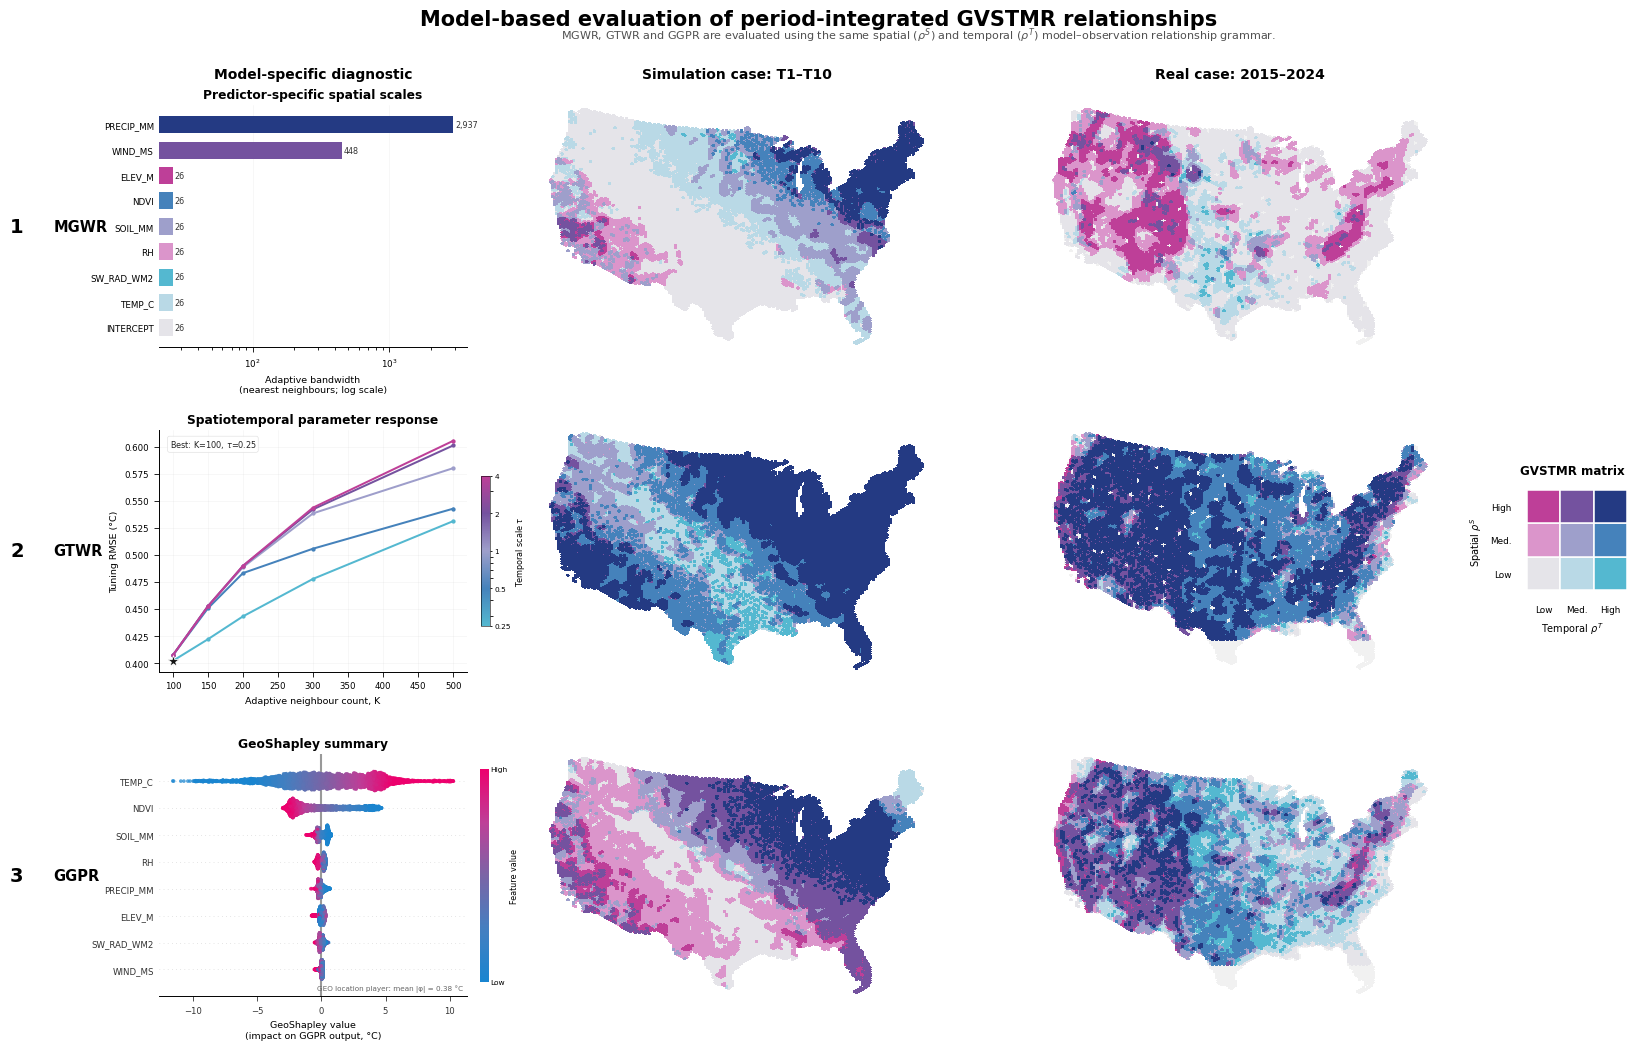


✅ FINAL COMBINED FIGURE COMPLETE

MGWR
  Simulation coverage : 100.00%
  Real-case coverage  : 95.62%

GTWR
  Simulation coverage : 100.00%
  Real-case coverage  : 94.03%

GGPR
  Simulation coverage : 100.00%
  Real-case coverage  : 97.58%

GeoShapley environmental variables plotted:
  TEMP_C <- GEOSHAP_TEMP_C_C
  SW_RAD_WM2 <- GEOSHAP_SW_RAD_WM2_C
  RH <- GEOSHAP_RH_C
  WIND_MS <- GEOSHAP_WIND_MS_C
  PRECIP_MM <- GEOSHAP_PRECIP_MM_C
  NDVI <- GEOSHAP_NDVI_C
  SOIL_MM <- GEOSHAP_SOIL_MM_C
  ELEV_M <- GEOSHAP_ELEV_M_C

Saved:
/content/GVSTMR_MODELWISE_GVSTMR/final_main_figures/MODEL_COMPARISON_PERIOD_GVSTMR_SHAP_FINAL.png
/content/GVSTMR_MODELWISE_GVSTMR/final_main_figures/MODEL_COMPARISON_PERIOD_GVSTMR_SHAP_FINAL.tif
/content/GVSTMR_MODELWISE_GVSTMR/final_main_figures/MODEL_COMPARISON_PERIOD_GVSTMR_SHAP_FINAL.pdf

NO MODEL REFIT.
NO GVSTMR RECALCULATION.
NO GOOGLE DRIVE WRITE.


In [ ]:
# ================================================================================================
# FINAL COMBINED GVSTMR MODEL FIGURE — REVISION 2
#
# ROW 1 — MGWR
# ROW 2 — GTWR
# ROW 3 — GGPR
#
# FIXES:
#   ✓ GTWR: no legend/text overlap
#   ✓ GTWR: tau represented by compact continuous colorbar
#   ✓ GTWR: best solution marked without annotation collision
#   ✓ GeoShapley: REAL SHAP-style beeswarm
#   ✓ GeoShapley points colored by the ACTUAL raw feature values
#   ✓ GEO location player remains neutral gray
#   ✓ no a–i clutter
#   ✓ only 1 MGWR / 2 GTWR / 3 GGPR row labels
#   ✓ identical cartography for all six maps
#   ✓ compact shared GVSTMR matrix
#
# NO MODEL REFIT
# NO GVSTMR RECALCULATION
# NO GOOGLE DRIVE WRITE
# ================================================================================================

from pathlib import Path
import warnings
import re
import sys
import subprocess

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, Normalize, LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

warnings.filterwarnings("ignore")


# ================================================================================================
# 0. SHAP
# ================================================================================================

try:
    import shap
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "shap"
        ]
    )
    import shap


# ================================================================================================
# 1. PATHS
# ================================================================================================

ROOT = Path(
    "/content/GVSTMR_MODELWISE_GVSTMR"
)

FIG_ROOT = (
    ROOT
    /
    "final_main_figures"
)

FIG_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================================================
# 2. REQUIRE PERIOD-GVSTMR RESULTS
# ================================================================================================

if "period_gvstmr" not in globals():

    raise RuntimeError(
        "period_gvstmr() not found.\n"
        "Run the already completed period-GVSTMR setup cell first."
    )


MODELS = [
    "MGWR",
    "GTWR",
    "GGPR"
]


MODEL_DATA = {}


for model in MODELS:

    MODEL_DATA[
        model
    ] = {

        "SIM":
            period_gvstmr(
                model,
                "SIMULATION"
            ),

        "REAL":
            period_gvstmr(
                model,
                "REAL"
            )
    }


# ================================================================================================
# 3. GVSTMR COLOR SYSTEM
# ================================================================================================

GV = {

    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",

    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",

    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}


# continuous color system for GTWR
GTWR_CMAP = LinearSegmentedColormap.from_list(

    "GTWR_tau",

    [
        GV[3],
        GV[6],
        GV[5],
        GV[8],
        GV[7]
    ]
)


# SHAP-style low -> high
SHAP_CMAP = LinearSegmentedColormap.from_list(

    "GeoShapley_low_high",

    [
        "#1985D0",
        "#457FC0",
        "#7B64A6",
        "#BE3F98",
        "#ED006D"
    ]
)


# ================================================================================================
# 4. GEOMETRY
# ================================================================================================

if "HEX_GEOM" not in globals():

    if "load_hex_geometry" not in globals():

        raise RuntimeError(
            "HEX_GEOM / load_hex_geometry() not found."
        )

    HEX_GEOM = load_hex_geometry()


H = HEX_GEOM[
    [
        "HEX_ID",
        "geometry"
    ]
].copy()


H[
    "HEX_ID"
] = H[
    "HEX_ID"
].astype(str)


H = (

    H
    .drop_duplicates(
        "HEX_ID"
    )
    .loc[
        H.geometry.notna()
    ]
    .copy()
)


H = H.loc[
    ~H.geometry.is_empty
].copy()


if H.crs is None:

    raise RuntimeError(
        "HEX geometry has no CRS."
    )


H = H.to_crs(
    "EPSG:5070"
)


# ================================================================================================
# DISPLAY-ONLY BUFFER
# ================================================================================================

PLOT_BUFFER_M = 25.0


H_DISPLAY = H.copy()


H_DISPLAY[
    "geometry"
] = (

    H_DISPLAY.geometry
    .buffer(
        PLOT_BUFFER_M,
        join_style=2
    )
)


xmin, ymin, xmax, ymax = (
    H_DISPLAY.total_bounds
)


dx = xmax - xmin
dy = ymax - ymin


MAP_EXTENT = (

    xmin - 0.012 * dx,
    xmax + 0.012 * dx,

    ymin - 0.012 * dy,
    ymax + 0.012 * dy
)


# ================================================================================================
# 5. MAP PREPARATION
# ================================================================================================

def prepare_map(
    d,
    label
):

    q = d.copy()


    q[
        "HEX_ID"
    ] = q[
        "HEX_ID"
    ].astype(str)


    q[
        "GV_CELL"
    ] = pd.to_numeric(
        q[
            "GV_CELL"
        ],
        errors="coerce"
    )


    g = H_DISPLAY.merge(

        q[
            [
                "HEX_ID",
                "GV_CELL"
            ]
        ],

        on="HEX_ID",

        how="left",

        validate="1:1"
    )


    g = gpd.GeoDataFrame(

        g,

        geometry="geometry",

        crs=H_DISPLAY.crs
    )


    n = len(
        g
    )


    nv = int(
        g[
            "GV_CELL"
        ]
        .notna()
        .sum()
    )


    coverage = (
        100
        *
        nv
        /
        max(
            n,
            1
        )
    )


    print(
        f"{label:<26}"
        f"coverage = {coverage:6.2f}%"
    )


    return (
        g,
        coverage
    )


MAPS = {}
COVERAGE = {}


for model in MODELS:

    MAPS[
        model
    ] = {}


    COVERAGE[
        model
    ] = {}


    MAPS[
        model
    ][
        "SIM"
    ], COVERAGE[
        model
    ][
        "SIM"
    ] = prepare_map(

        MODEL_DATA[
            model
        ][
            "SIM"
        ],

        f"{model} simulation"
    )


    MAPS[
        model
    ][
        "REAL"
    ], COVERAGE[
        model
    ][
        "REAL"
    ] = prepare_map(

        MODEL_DATA[
            model
        ][
            "REAL"
        ],

        f"{model} real"
    )


# ================================================================================================
# 6. CLEAN MAP
# ================================================================================================

def draw_map(
    ax,
    g
):

    # missing cells
    missing = g.loc[
        g[
            "GV_CELL"
        ].isna()
    ]


    if len(
        missing
    ) > 0:

        missing.plot(

            ax=ax,

            facecolor="#F1F1F1",

            edgecolor="none",

            linewidth=0,

            antialiased=False,

            rasterized=True
        )


    # GVSTMR states
    for cell in range(
        1,
        10
    ):

        s = g.loc[
            g[
                "GV_CELL"
            ].eq(
                cell
            )
        ]


        if len(
            s
        ) == 0:

            continue


        s.plot(

            ax=ax,

            facecolor=GV[
                cell
            ],

            edgecolor="none",

            linewidth=0,

            antialiased=False,

            rasterized=True
        )


    ax.set_xlim(
        MAP_EXTENT[
            0
        ],
        MAP_EXTENT[
            1
        ]
    )


    ax.set_ylim(
        MAP_EXTENT[
            2
        ],
        MAP_EXTENT[
            3
        ]
    )


    ax.set_aspect(
        "equal"
    )


    ax.set_axis_off()


# ================================================================================================
# 7. MGWR BANDWIDTH TABLE
# ================================================================================================

def find_mgwr_bandwidths():

    best = None


    for p in Path(
        "/content"
    ).rglob(
        "*.csv"
    ):

        if str(p).startswith(
            "/content/drive/"
        ):

            continue


        if "MGWR" not in str(
            p
        ).upper():

            continue


        try:

            d = pd.read_csv(
                p
            )

        except Exception:

            continue


        if not {

            "VARIABLE",
            "BANDWIDTH_N_NEIGHBORS"

        }.issubset(
            d.columns
        ):

            continue


        score = (
            10
            if "BANDWIDTH" in p.name.upper()
            else 0
        )


        if (
            best is None
            or
            score > best[
                0
            ]
        ):

            best = (
                score,
                d,
                p
            )


    if best is None:

        return (
            None,
            None
        )


    return (
        best[
            1
        ],
        best[
            2
        ]
    )


# ================================================================================================
# 8. MGWR PANEL
# ================================================================================================

def draw_mgwr(
    ax
):

    d, source = (
        find_mgwr_bandwidths()
    )


    if d is None:

        ax.text(
            0.5,
            0.5,
            "MGWR bandwidth table not found",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )

        ax.set_axis_off()

        return


    d = d.copy()


    d[
        "BANDWIDTH_N_NEIGHBORS"
    ] = pd.to_numeric(

        d[
            "BANDWIDTH_N_NEIGHBORS"
        ],

        errors="coerce"
    )


    d = (

        d
        .dropna(
            subset=[
                "BANDWIDTH_N_NEIGHBORS"
            ]
        )
        .sort_values(
            "BANDWIDTH_N_NEIGHBORS",
            ascending=True
        )
        .reset_index(
            drop=True
        )
    )


    colors = [

        GV[
            1 + (
                i % 9
            )
        ]

        for i in range(
            len(
                d
            )
        )
    ]


    bars = ax.barh(

        d[
            "VARIABLE"
        ],

        d[
            "BANDWIDTH_N_NEIGHBORS"
        ],

        color=colors,

        edgecolor="none",

        height=0.67
    )


    ax.set_xscale(
        "log"
    )


    ax.set_xlabel(

        "Adaptive bandwidth\n"
        "(nearest neighbours; log scale)",

        fontsize=6.8,

        labelpad=4
    )


    ax.set_title(

        "Predictor-specific spatial scales",

        fontsize=8.8,

        fontweight="bold",

        pad=5
    )


    ax.tick_params(

        axis="x",

        labelsize=6.3
    )


    ax.tick_params(

        axis="y",

        labelsize=6.3,

        length=0
    )


    ax.grid(

        axis="x",

        alpha=0.14,

        linewidth=0.45
    )


    ax.set_axisbelow(
        True
    )


    for bar, value in zip(

        bars,

        d[
            "BANDWIDTH_N_NEIGHBORS"
        ]
    ):

        ax.text(

            value * 1.035,

            bar.get_y()
            +
            bar.get_height() / 2,

            f"{int(round(value)):,}",

            fontsize=5.8,

            va="center",

            color="#333333"
        )


    for sp in [
        "top",
        "right",
        "left"
    ]:

        ax.spines[
            sp
        ].set_visible(
            False
        )


# ================================================================================================
# 9. GTWR — FIND COMPLETE TUNING TABLE
# ================================================================================================

def find_gtwr_tuning():

    candidates = []


    for p in Path(
        "/content"
    ).rglob(
        "*.csv"
    ):

        if str(p).startswith(
            "/content/drive/"
        ):

            continue


        if "GTWR" not in str(
            p
        ).upper():

            continue


        try:

            d = pd.read_csv(
                p
            )

        except Exception:

            continue


        if not {
            "TAU",
            "K"
        }.issubset(
            d.columns
        ):

            continue


        rmse = None


        for c in [
            "RMSE_C",
            "RMSE"
        ]:

            if c in d.columns:

                rmse = c

                break


        if rmse is None:

            continue


        q = d.copy()


        for c in [
            "TAU",
            "K",
            rmse
        ]:

            q[
                c
            ] = pd.to_numeric(

                q[
                    c
                ],

                errors="coerce"
            )


        q = q.dropna(
            subset=[
                "TAU",
                "K",
                rmse
            ]
        )


        ntau = q[
            "TAU"
        ].nunique()


        nk = q[
            "K"
        ].nunique()


        nc = q[
            [
                "TAU",
                "K"
            ]
        ].drop_duplicates().shape[
            0
        ]


        if (
            ntau < 2
            or
            nk < 3
        ):

            continue


        candidates.append(
            (
                nc,
                q,
                rmse,
                p
            )
        )


    if not candidates:

        return (
            None,
            None,
            None
        )


    candidates = sorted(

        candidates,

        key=lambda x: x[
            0
        ],

        reverse=True
    )


    return (

        candidates[
            0
        ][
            1
        ],

        candidates[
            0
        ][
            2
        ],

        candidates[
            0
        ][
            3
        ]
    )


# ================================================================================================
# 10. CLEAN GTWR PANEL
#
# NO LEGEND INSIDE DATA AREA
# TAU = COLOR
# ================================================================================================

def draw_gtwr(
    ax
):

    d, rmse_col, source = (
        find_gtwr_tuning()
    )


    if d is None:

        ax.text(
            0.5,
            0.5,
            "GTWR tuning table not found",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )

        ax.set_axis_off()

        return


    taus = np.array(
        sorted(
            d[
                "TAU"
            ].unique()
        ),
        dtype=float
    )


    # tau is multiplicative: use log-normalized color scale
    tau_norm = LogNorm(

        vmin=float(
            taus.min()
        ),

        vmax=float(
            taus.max()
        )
    )


    # --------------------------------------------------------------------------------------------
    # DRAW LINES
    # --------------------------------------------------------------------------------------------

    for tau in taus:

        q = (

            d.loc[
                d[
                    "TAU"
                ].eq(
                    tau
                )
            ]

            .groupby(
                "K",
                as_index=False
            )[
                rmse_col
            ]
            .mean()

            .sort_values(
                "K"
            )
        )


        color = GTWR_CMAP(
            tau_norm(
                tau
            )
        )


        ax.plot(

            q[
                "K"
            ],

            q[
                rmse_col
            ],

            color=color,

            linewidth=1.45,

            marker="o",

            markersize=3.1,

            markeredgewidth=0,

            zorder=3
        )


    # --------------------------------------------------------------------------------------------
    # BEST
    # --------------------------------------------------------------------------------------------

    best = (

        d
        .sort_values(
            rmse_col,
            ascending=True
        )
        .iloc[
            0
        ]
    )


    ax.scatter(

        best[
            "K"
        ],

        best[
            rmse_col
        ],

        marker="*",

        s=72,

        color="#111111",

        edgecolor="white",

        linewidth=0.55,

        zorder=10
    )


    # Best information in a fixed clean box:
    # NOT attached to the line.
    ax.text(

        0.035,
        0.965,

        (
            "Best: "
            f"K={int(best['K'])}, "
            rf"$\tau$={best['TAU']:g}"
        ),

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=5.9,

        color="#222222",

        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#DDDDDD",
            linewidth=0.45,
            alpha=0.94
        ),

        zorder=20
    )


    ax.set_title(

        "Spatiotemporal parameter response",

        fontsize=8.8,

        fontweight="bold",

        pad=5
    )


    ax.set_xlabel(

        "Adaptive neighbour count, K",

        fontsize=6.8,

        labelpad=4
    )


    ax.set_ylabel(

        "Tuning RMSE (°C)",

        fontsize=6.8,

        labelpad=4
    )


    ax.tick_params(

        labelsize=6.2
    )


    ax.grid(

        alpha=0.14,

        linewidth=0.45
    )


    ax.set_axisbelow(
        True
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    # --------------------------------------------------------------------------------------------
    # TAU COLORBAR — outside data area, compact
    # --------------------------------------------------------------------------------------------

    cax = inset_axes(

        ax,

        width="3.0%",

        height="62%",

        loc="center right",

        bbox_to_anchor=(
            0.075,
            0.0,
            1,
            1
        ),

        bbox_transform=ax.transAxes,

        borderpad=0
    )


    sm = mpl.cm.ScalarMappable(

        norm=tau_norm,

        cmap=GTWR_CMAP
    )


    cb = plt.colorbar(

        sm,

        cax=cax
    )


    cb.set_ticks(
        taus
    )


    cb.set_ticklabels(
        [
            f"{x:g}"
            for x in taus
        ]
    )


    cb.ax.tick_params(

        labelsize=5.3,

        length=1.5,

        pad=1.5
    )


    cb.set_label(

        r"Temporal scale $\tau$",

        fontsize=5.8,

        labelpad=2
    )


    cb.outline.set_linewidth(
        0.4
    )


# ================================================================================================
# 11. LOAD GGPR + GEOSHAPLEY TABLE
# ================================================================================================

def read_local_table(
    p
):

    if p.suffix.lower() == ".parquet":

        return pd.read_parquet(
            p
        )

    return pd.read_csv(
        p
    )


def get_gg_table():

    # runtime is preferred
    if "load_model_case" in globals():

        try:

            d = load_model_case(
                "GGPR",
                "REAL"
            )


            gcols = [
                c
                for c
                in d.columns
                if c.upper().startswith(
                    "GEOSHAP_"
                )
            ]


            if len(
                gcols
            ) >= 5:

                return d.copy()


        except Exception:

            pass


    best = None


    for ext in [
        "*.parquet",
        "*.csv"
    ]:

        for p in Path(
            "/content"
        ).rglob(
            ext
        ):

            if str(p).startswith(
                "/content/drive/"
            ):

                continue


            u = str(
                p
            ).upper()


            if "GGPR" not in u:

                continue


            try:

                d = read_local_table(
                    p
                )

            except Exception:

                continue


            gcols = [
                c
                for c
                in d.columns
                if c.upper().startswith(
                    "GEOSHAP_"
                )
            ]


            if len(
                gcols
            ) < 5:

                continue


            score = (

                len(
                    gcols
                )

                +

                10 * int(
                    "ANNUAL"
                    in
                    u
                )

                +

                10 * int(
                    "2015_2024"
                    in
                    u
                )
            )


            if (
                best is None
                or
                score > best[
                    0
                ]
            ):

                best = (
                    score,
                    d,
                    p
                )


    if best is None:

        raise RuntimeError(
            "GGPR GeoShapley table not found."
        )


    print(
        "GeoShapley source:",
        best[
            2
        ]
    )


    return best[
        1
    ].copy()


GG = get_gg_table()


# ================================================================================================
# 12. STANDARDISE KEY COLUMNS
# ================================================================================================

GG[
    "HEX_ID"
] = GG[
    "HEX_ID"
].astype(str)


if "TIME" in GG.columns:

    GG[
        "__TIME"
    ] = pd.to_numeric(
        GG[
            "TIME"
        ],
        errors="coerce"
    )


elif "YEAR" in GG.columns:

    GG[
        "__TIME"
    ] = pd.to_numeric(
        GG[
            "YEAR"
        ],
        errors="coerce"
    )


else:

    raise RuntimeError(
        "GGPR GeoShapley table lacks YEAR/TIME."
    )


# ================================================================================================
# 13. RAW FEATURE VALUES
#
# This is the crucial correction.
# GeoShapley values and feature-value colors must refer to the SAME Hex × Year.
# ================================================================================================

FEATURES = [

    "TEMP_C",
    "SW_RAD_WM2",
    "RH",
    "WIND_MS",
    "PRECIP_MM",
    "NDVI",
    "SOIL_MM",
    "ELEV_M"
]


def find_real_predictor_panel():

    # ---------------------------------------------------------
    # existing runtime PANEL
    # ---------------------------------------------------------

    if "PANEL" in globals():

        p = globals()[
            "PANEL"
        ]

        if isinstance(
            p,
            pd.DataFrame
        ):

            if (
                "HEX_ID" in p.columns
                and
                "YEAR" in p.columns
                and
                sum(
                    f in p.columns
                    for f in FEATURES
                ) >= 6
            ):

                return p.copy()


    # ---------------------------------------------------------
    # existing helper
    # ---------------------------------------------------------

    if "get_real_panel" in globals():

        try:

            p = get_real_panel()

            if (
                "HEX_ID" in p.columns
                and
                "YEAR" in p.columns
            ):

                return p.copy()

        except Exception:

            pass


    # ---------------------------------------------------------
    # local files
    # ---------------------------------------------------------

    best = None


    for ext in [
        "*.parquet",
        "*.csv"
    ]:

        for p in Path(
            "/content"
        ).rglob(
            ext
        ):

            if str(p).startswith(
                "/content/drive/"
            ):

                continue


            try:

                d = read_local_table(
                    p
                )

            except Exception:

                continue


            if (
                "HEX_ID" not in d.columns
                or
                "YEAR" not in d.columns
            ):

                continue


            nfeat = sum(
                f in d.columns
                for f in FEATURES
            )


            if nfeat < 6:

                continue


            if (
                best is None
                or
                nfeat > best[
                    0
                ]
            ):

                best = (
                    nfeat,
                    d,
                    p
                )


    if best is None:

        raise RuntimeError(
            "Could not locate the real Hex×Year predictor panel."
        )


    print(
        "Predictor panel:",
        best[
            2
        ]
    )


    return best[
        1
    ].copy()


RP = find_real_predictor_panel()


RP[
    "HEX_ID"
] = RP[
    "HEX_ID"
].astype(str)


RP[
    "__TIME"
] = pd.to_numeric(
    RP[
        "YEAR"
    ],
    errors="coerce"
)


RP = (
    RP.loc[
        RP[
            "__TIME"
        ].between(
            2015,
            2024
        )
    ]
    [
        [
            "HEX_ID",
            "__TIME",
            *[
                f
                for f
                in FEATURES
                if f in RP.columns
            ]
        ]
    ]
    .drop_duplicates(
        [
            "HEX_ID",
            "__TIME"
        ]
    )
)


# ================================================================================================
# MERGE ONLY MISSING RAW FEATURES INTO GGPR TABLE
# ================================================================================================

raw_missing = [
    f
    for f
    in FEATURES
    if f not in GG.columns
]


if raw_missing:

    GG = GG.merge(

        RP[
            [
                "HEX_ID",
                "__TIME",
                *[
                    f
                    for f
                    in raw_missing
                    if f in RP.columns
                ]
            ]
        ],

        on=[
            "HEX_ID",
            "__TIME"
        ],

        how="left",

        validate="m:1"
    )


print(
    "\nRaw feature availability for GeoShapley coloring:"
)


for f in FEATURES:

    if f in GG.columns:

        n = pd.to_numeric(
            GG[
                f
            ],
            errors="coerce"
        ).notna().sum()

        print(
            f"{f:<12}: {n:,}"
        )

    else:

        print(
            f"{f:<12}: MISSING"
        )


# ================================================================================================
# 14. MAP GEOSHAPLEY COMPONENTS TO FEATURES
# ================================================================================================

def norm_name(
    x
):

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(
            x
        ).upper()
    )


geo_columns = [
    c
    for c
    in GG.columns
    if c.upper().startswith(
        "GEOSHAP_"
    )
]


def find_geoshap_col(
    feature
):

    target = norm_name(
        feature
    )


    for c in geo_columns:

        b = re.sub(
            r"^GEOSHAP_",
            "",
            c,
            flags=re.I
        )


        nb = norm_name(
            b
        )


        # exact
        if nb == target:

            return c


        # previous saved form, e.g. TEMP_C_C
        if nb == norm_name(
            feature + "_C"
        ):

            return c


    return None


GEO_PAIRS = []


for feature in FEATURES:

    gc = find_geoshap_col(
        feature
    )


    if (
        gc is not None
        and
        feature in GG.columns
    ):

        GEO_PAIRS.append(
            (
                feature,
                gc
            )
        )


# optional GEO location player
GEO_LOCATION_COL = None


for c in geo_columns:

    base = re.sub(
        r"^GEOSHAP_",
        "",
        c,
        flags=re.I
    )


    if norm_name(
        base
    ) in [
        "GEO",
        "GEOC",
        "LOCATION",
        "SPATIAL"
    ]:

        GEO_LOCATION_COL = c

        break


print(
    "\nGeoShapley environmental features:"
)


for f, c in GEO_PAIRS:

    print(
        f"{f:<12} <- {c}"
    )


print(
    "GEO location:",
    GEO_LOCATION_COL
)


# ================================================================================================
# 15. BUILD REAL SHAP EXPLANATION
# ================================================================================================

def build_geoshap_explanation():

    if len(
        GEO_PAIRS
    ) < 4:

        raise RuntimeError(
            "Too few GeoShapley-feature pairs were matched."
        )


    # --------------------------------------------------------------------------------------------
    # Global importance computed on COMPLETE DATA
    # --------------------------------------------------------------------------------------------

    imp = []


    for feature, gc in GEO_PAIRS:

        v = pd.to_numeric(
            GG[
                gc
            ],
            errors="coerce"
        ).to_numpy(
            float
        )


        imp.append(
            (
                feature,
                gc,
                float(
                    np.nanmean(
                        np.abs(
                            v
                        )
                    )
                )
            )
        )


    imp = sorted(

        imp,

        key=lambda x: x[
            2
        ],

        reverse=True
    )


    # all 8 environmental features
    selected = imp[
        :8
    ]


    names = [
        x[
            0
        ]
        for x
        in selected
    ]


    geocols = [
        x[
            1
        ]
        for x
        in selected
    ]


    # --------------------------------------------------------------------------------------------
    # We sample only for plotting.
    # Importance/order still comes from complete table.
    # --------------------------------------------------------------------------------------------

    cols_needed = (
        geocols
        +
        names
    )


    Q = GG[
        cols_needed
    ].copy()


    for c in cols_needed:

        Q[
            c
        ] = pd.to_numeric(
            Q[
                c
            ],
            errors="coerce"
        )


    # contribution must be present;
    # feature values ideally present as well
    ok = (
        Q[
            geocols
        ]
        .notna()
        .all(
            axis=1
        )
    )


    Q = Q.loc[
        ok
    ].copy()


    MAX_SHAP_POINTS = 5000


    if len(
        Q
    ) > MAX_SHAP_POINTS:

        Q = Q.sample(

            MAX_SHAP_POINTS,

            random_state=123
        )


    values = Q[
        geocols
    ].to_numpy(
        float
    )


    data = Q[
        names
    ].to_numpy(
        float
    )


    # fill occasional missing raw value with feature median
    for j in range(
        data.shape[
            1
        ]
    ):

        med = np.nanmedian(
            data[
                :,
                j
            ]
        )


        if not np.isfinite(
            med
        ):

            med = 0.0


        bad = ~np.isfinite(
            data[
                :,
                j
            ]
        )


        data[
            bad,
            j
        ] = med


    expl = shap.Explanation(

        values=values,

        data=data,

        feature_names=names
    )


    return (
        expl,
        selected
    )


GEO_EXPLANATION, GEO_SELECTED = (
    build_geoshap_explanation()
)


# ================================================================================================
# 16. OFFICIAL SHAP-STYLE BEESWARM
# ================================================================================================

def draw_geoshap(
    ax
):

    # SHAP itself handles:
    #   x          = contribution
    #   y ordering = mean |contribution|
    #   point pile = density
    #   point color= actual feature value

    try:

        shap.plots.beeswarm(

            GEO_EXPLANATION,

            max_display=len(
                GEO_SELECTED
            ),

            order=shap.Explanation.abs.mean(
                0
            ),

            color=SHAP_CMAP,

            alpha=0.72,

            s=7,

            ax=ax,

            show=False,

            color_bar=False,

            plot_size=None,

            group_remaining_features=False
        )


    except TypeError:

        # fallback for an older SHAP version
        plt.sca(
            ax
        )

        shap.summary_plot(

            GEO_EXPLANATION.values,

            GEO_EXPLANATION.data,

            feature_names=GEO_EXPLANATION.feature_names,

            plot_type="dot",

            color=SHAP_CMAP,

            show=False,

            color_bar=False,

            plot_size=None,

            max_display=len(
                GEO_SELECTED
            )
        )


    # --------------------------------------------------------------------------------------------
    # stylistic cleanup
    # --------------------------------------------------------------------------------------------

    ax.set_title(

        "GeoShapley summary",

        fontsize=8.8,

        fontweight="bold",

        pad=5
    )


    ax.set_xlabel(

        "GeoShapley value\n(impact on GGPR output, °C)",

        fontsize=6.8,

        labelpad=4
    )


    ax.tick_params(

        axis="x",

        labelsize=6.1
    )


    ax.tick_params(

        axis="y",

        labelsize=6.2,

        length=0
    )


    for sp in [
        "top",
        "right",
        "left"
    ]:

        ax.spines[
            sp
        ].set_visible(
            False
        )


    # --------------------------------------------------------------------------------------------
    # TRUE SHAP LOW-HIGH FEATURE VALUE COLORBAR
    # --------------------------------------------------------------------------------------------

    cax = inset_axes(

        ax,

        width="2.8%",

        height="88%",

        loc="center right",

        bbox_to_anchor=(
            0.07,
            0.0,
            1,
            1
        ),

        bbox_transform=ax.transAxes,

        borderpad=0
    )


    sm = mpl.cm.ScalarMappable(

        cmap=SHAP_CMAP,

        norm=Normalize(
            0,
            1
        )
    )


    cb = plt.colorbar(

        sm,

        cax=cax
    )


    cb.set_ticks(
        [
            0,
            1
        ]
    )


    cb.set_ticklabels(
        [
            "Low",
            "High"
        ]
    )


    cb.set_label(

        "Feature value",

        fontsize=5.8,

        labelpad=2
    )


    cb.ax.tick_params(

        labelsize=5.4,

        length=0,

        pad=1
    )


    cb.outline.set_visible(
        False
    )


    # --------------------------------------------------------------------------------------------
    # GEO LOCATION PLAYER
    # --------------------------------------------------------------------------------------------

    if GEO_LOCATION_COL is not None:

        geo = pd.to_numeric(

            GG[
                GEO_LOCATION_COL
            ],

            errors="coerce"
        ).to_numpy(
            float
        )


        geo_imp = np.nanmean(
            np.abs(
                geo
            )
        )


        ax.text(

            0.985,
            0.015,

            (
                "GEO location player: "
                f"mean |φ| = {geo_imp:.2f} °C"
            ),

            transform=ax.transAxes,

            ha="right",

            va="bottom",

            fontsize=5.2,

            color="#666666"
        )


# ================================================================================================
# 17. SHARED GVSTMR MATRIX
# ================================================================================================

def draw_matrix(
    parent
):

    parent.set_axis_off()


    ax = parent.inset_axes(

        [
            0.04,
            0.41,
            0.93,
            0.20
        ]
    )


    ax.set_xlim(
        -0.38,
        3.08
    )


    ax.set_ylim(
        -0.38,
        3.27
    )


    for s in range(
        3
    ):

        for t in range(
            3
        ):

            cell = (
                s * 3
                +
                t
                +
                1
            )


            ax.add_patch(

                Rectangle(

                    (
                        t,
                        s
                    ),

                    1,
                    1,

                    facecolor=GV[
                        cell
                    ],

                    edgecolor="white",

                    linewidth=1.1
                )
            )


    ax.set_xticks(

        [
            0.5,
            1.5,
            2.5
        ],

        [
            "Low",
            "Med.",
            "High"
        ]
    )


    ax.set_yticks(

        [
            0.5,
            1.5,
            2.5
        ],

        [
            "Low",
            "Med.",
            "High"
        ]
    )


    ax.tick_params(

        labelsize=6.4,

        length=0,

        pad=2
    )


    ax.set_xlabel(

        r"Temporal $\rho^T$",

        fontsize=7.0,

        labelpad=4
    )


    ax.set_ylabel(

        r"Spatial $\rho^S$",

        fontsize=7.0,

        labelpad=4
    )


    ax.set_title(

        "GVSTMR matrix",

        fontsize=8.6,

        fontweight="bold",

        pad=5
    )


    ax.set_aspect(
        "equal"
    )


    for sp in ax.spines.values():

        sp.set_visible(
            False
        )


# ================================================================================================
# 18. FIGURE
# ================================================================================================

fig = plt.figure(

    figsize=(
        16.7,
        10.8
    ),

    facecolor="white"
)


gs = fig.add_gridspec(

    3,
    4,


    width_ratios=[

        1.07,
        1.62,
        1.62,
        0.43
    ],


    height_ratios=[

        1,
        1,
        1
    ],


    # more left margin:
    # row labels never touch y-axis labels
    left=0.105,

    right=0.988,

    bottom=0.060,

    top=0.885,


    # more separation between rows
    hspace=0.34,

    wspace=0.105
)


AX = {}


for r, model in enumerate(
    MODELS
):

    AX[
        model
    ] = {

        "INFO":
            fig.add_subplot(
                gs[
                    r,
                    0
                ]
            ),

        "SIM":
            fig.add_subplot(
                gs[
                    r,
                    1
                ]
            ),

        "REAL":
            fig.add_subplot(
                gs[
                    r,
                    2
                ]
            )
    }


AX_LEGEND = fig.add_subplot(

    gs[
        :,
        3
    ]
)


# ================================================================================================
# 19. LEFT COLUMN
# ================================================================================================

draw_mgwr(
    AX[
        "MGWR"
    ][
        "INFO"
    ]
)


draw_gtwr(
    AX[
        "GTWR"
    ][
        "INFO"
    ]
)


draw_geoshap(
    AX[
        "GGPR"
    ][
        "INFO"
    ]
)


# ================================================================================================
# 20. SIX MAPS
# ================================================================================================

for model in MODELS:

    draw_map(

        AX[
            model
        ][
            "SIM"
        ],

        MAPS[
            model
        ][
            "SIM"
        ]
    )


    draw_map(

        AX[
            model
        ][
            "REAL"
        ],

        MAPS[
            model
        ][
            "REAL"
        ]
    )


# ================================================================================================
# 21. SHARED MATRIX
# ================================================================================================

draw_matrix(
    AX_LEGEND
)


# ================================================================================================
# 22. TITLES
# ================================================================================================

fig.suptitle(

    "Model-based evaluation of period-integrated GVSTMR relationships",

    fontsize=15,

    fontweight="bold",

    y=0.974
)


fig.text(

    0.56,

    0.947,

    r"MGWR, GTWR and GGPR are evaluated using the same spatial ($\rho^S$) "
    r"and temporal ($\rho^T$) model–observation relationship grammar.",

    ha="center",

    fontsize=8.0,

    color="#505050"
)


# ================================================================================================
# 23. COLUMN TITLES
# ================================================================================================

fig.canvas.draw()


p_info = AX[
    "MGWR"
][
    "INFO"
].get_position()


p_sim = AX[
    "MGWR"
][
    "SIM"
].get_position()


p_real = AX[
    "MGWR"
][
    "REAL"
].get_position()


COLUMN_Y = 0.910


fig.text(

    (
        p_info.x0
        +
        p_info.x1
    ) / 2,

    COLUMN_Y,

    "Model-specific diagnostic",

    ha="center",

    fontsize=10.0,

    fontweight="bold"
)


fig.text(

    (
        p_sim.x0
        +
        p_sim.x1
    ) / 2,

    COLUMN_Y,

    "Simulation case: T1–T10",

    ha="center",

    fontsize=10.0,

    fontweight="bold"
)


fig.text(

    (
        p_real.x0
        +
        p_real.x1
    ) / 2,

    COLUMN_Y,

    "Real case: 2015–2024",

    ha="center",

    fontsize=10.0,

    fontweight="bold"
)


# ================================================================================================
# 24. ROW LABELS — WELL OUTSIDE AXES
# ================================================================================================

for number, model in [

    (
        "1",
        "MGWR"
    ),

    (
        "2",
        "GTWR"
    ),

    (
        "3",
        "GGPR"
    )

]:

    p = AX[
        model
    ][
        "INFO"
    ].get_position()


    yc = (
        p.y0
        +
        p.y1
    ) / 2


    fig.text(

        0.020,

        yc,

        number,

        ha="center",

        va="center",

        fontsize=14,

        fontweight="bold"
    )


    fig.text(

        0.042,

        yc,

        model,

        ha="left",

        va="center",

        fontsize=10.5,

        fontweight="bold"
    )


# ================================================================================================
# 25. SAVE
# ================================================================================================

OUTBASE = (

    FIG_ROOT
    /
    "MODEL_COMPARISON_PERIOD_GVSTMR_SHAP_FINAL"
)


fig.savefig(

    f"{OUTBASE}.png",

    dpi=600,

    bbox_inches="tight",

    facecolor="white"
)


fig.savefig(

    f"{OUTBASE}.tif",

    dpi=600,

    bbox_inches="tight",

    facecolor="white"
)


fig.savefig(

    f"{OUTBASE}.pdf",

    bbox_inches="tight",

    facecolor="white"
)


plt.show()


plt.close(
    fig
)


# ================================================================================================
# 26. REPORT
# ================================================================================================

print(
    "\n" + "=" * 112
)

print(
    "✅ FINAL COMBINED FIGURE COMPLETE"
)

print(
    "=" * 112
)


for model in MODELS:

    print(
        f"\n{model}"
    )

    print(
        f"  Simulation coverage : "
        f"{COVERAGE[model]['SIM']:.2f}%"
    )

    print(
        f"  Real-case coverage  : "
        f"{COVERAGE[model]['REAL']:.2f}%"
    )


print(
    "\nGeoShapley environmental variables plotted:"
)


for f, gc in GEO_PAIRS:

    print(
        " ",
        f,
        "<-",
        gc
    )


print(
    "\nSaved:"
)

print(
    f"{OUTBASE}.png"
)

print(
    f"{OUTBASE}.tif"
)

print(
    f"{OUTBASE}.pdf"
)


print(
    "\nNO MODEL REFIT."
)

print(
    "NO GVSTMR RECALCULATION."
)

print(
    "NO GOOGLE DRIVE WRITE."
)

SIMULATION
Rows : 128,640
Hexes: 12,864
Times: 0         4
1         4
2         4
3         4
4         4
         ..
128635    4
128636    4
128637    4
128638    4
128639    4
Length: 128640, dtype: int64

REAL CASE INPUTS
GeoShapley : /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024/04_UNCERTAINTY_EFFECT_COUPLING/ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_COUPLING_ALL_HEX.parquet
Uncertainty: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_2015_2024/04_UNCERTAINTY_EFFECT_COUPLING/ANNUAL_GGPR_GEOSHAP_UNCERTAINTY_COUPLING_ALL_HEX.parquet
Environmental GeoShapley components: 8
Rows : 125,530
Hexes: 12,553
Years: 0         4
1         4
2         4
3         4
4         4
         ..
125525    4
125526    4
125527    4
125528    4
125529    4
Length: 125530, dtype: int64

Geometry source: /content/GVSTMR_MODELWISE_GVSTMR/_extracted/GVSTMR_SIMULATION_CONUS_10T_V2/07_CARTOGRAPHY_READY/SIMULATION_HEX_GRID.parquet
Geometry

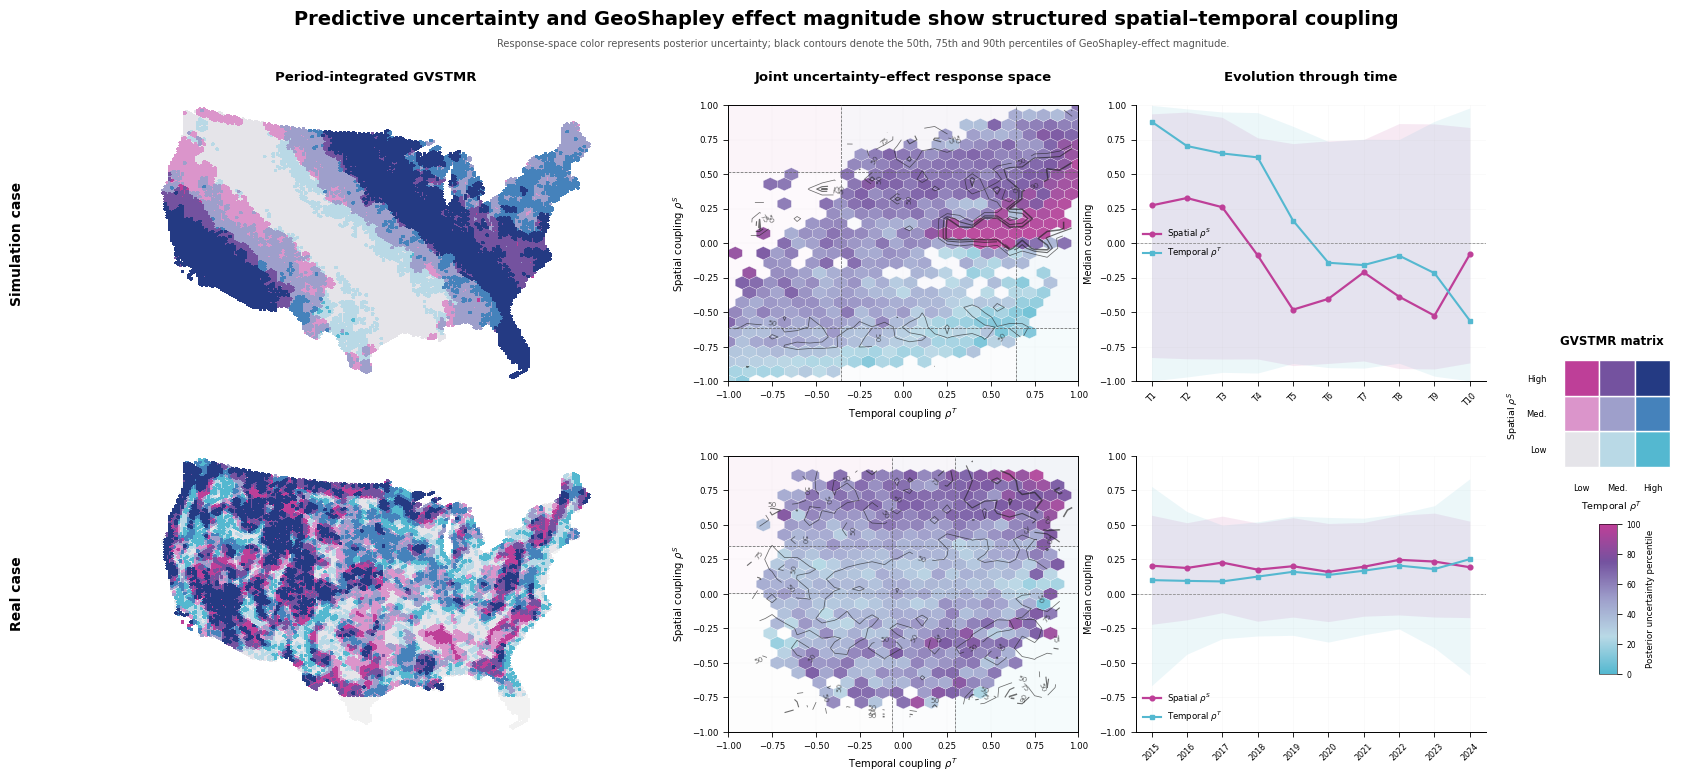


✅ UNCERTAINTY × GEOSHAPLEY FIGURE COMPLETE
Simulation hexes: 12864
Real hexes      : 12553
Figure          : /content/GVSTMR_MODELWISE_GVSTMR/final_main_figures/UNCERTAINTY_GEOSHAPLEY_SIM_REAL_FINAL_V2
NO GGPR REFIT.
NO GEOSHAPLEY RECALCULATION.
NO GOOGLE DRIVE WRITE.


In [ ]:
# ================================================================================================
# FINAL FIX — UNCERTAINTY × GEOSHAPLEY
# Simulation T1–T10 + Real case 2015–2024
#
# FIXES:
#   1. NO GGPR refit
#   2. NO GeoShapley recalculation
#   3. Uses already-created simulation annual table
#   4. Correctly converts WKB geometry -> shapely geometry
#   5. Cleaner response-space visualization:
#          color   = posterior uncertainty percentile
#          contours = GeoShapley-effect percentile
#   6. Simulation + Real case use same visual grammar
#
# NO GOOGLE DRIVE WRITE
# ================================================================================================

from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, Normalize

from scipy.spatial import cKDTree
from scipy.stats import binned_statistic_2d

warnings.filterwarnings("ignore")


# ================================================================================================
# 0. PATHS
# ================================================================================================

ROOT = Path("/content/GVSTMR_MODELWISE_GVSTMR")

FIG_ROOT = ROOT / "final_main_figures"
TABLE_ROOT = ROOT / "final_period_tables"

FIG_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

SIM_PATH = (
    ROOT
    / "derived_simulation"
    / "GGPR_SIMULATION_ANNUAL_GEOSHAP_UNCERTAINTY_T1_T10.parquet"
)

if not SIM_PATH.exists():
    raise RuntimeError(
        "Simulation annual GGPR table not found:\n"
        f"{SIM_PATH}\n\n"
        "The previous corrected simulation cell must finish once."
    )


# ================================================================================================
# 1. PALETTE
# ================================================================================================

GV = {
    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",
    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",
    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}

UNC_CMAP = LinearSegmentedColormap.from_list(
    "GVSTMR_unc",
    [
        GV[3],
        GV[2],
        GV[5],
        GV[8],
        GV[7],
    ]
)


# ================================================================================================
# 2. HELPERS
# ================================================================================================

def read_table(p):

    if p.suffix.lower() == ".parquet":
        return pd.read_parquet(p)

    return pd.read_csv(p)


def is_drive(p):

    return str(p).startswith("/content/drive/")


def get_time_col(df):

    for c in [
        "YEAR",
        "__TIME",
        "TIME",
        "T",
    ]:

        if c in df.columns:
            return c

    return None


def detect_unc_col(df):

    preferred = [
        "GGPR_POSTERIOR_SD_C",
        "POSTERIOR_SD_C",
        "GGPR_POSTERIOR_SD",
        "POSTERIOR_SD",
        "PRED_SD_C",
        "PREDICTIVE_SD_C",
        "UNCERTAINTY_C",
    ]

    for c in preferred:

        if c in df.columns:
            return c

    for c in df.columns:

        u = c.upper()

        if (
            "UNCERTAINT" in u
            or
            (
                "POSTERIOR" in u
                and
                ("SD" in u or "STD" in u)
            )
        ):

            if pd.api.types.is_numeric_dtype(df[c]):
                return c

    return None


def environmental_geoshap_cols(df):

    out = []

    for c in df.columns:

        u = c.upper()

        if not u.startswith("GEOSHAP_"):
            continue

        if any(
            token in u
            for token in [
                "BASE",
                "SUM",
                "RECON",
                "ERROR",
                "RESID",
                "INTERACTION",
            ]
        ):
            continue

        base = re.sub(
            r"^GEOSHAP_",
            "",
            c,
            flags=re.I
        )

        norm = re.sub(
            r"[^A-Z0-9]",
            "",
            base.upper()
        )

        # GEO/location = separate spatial player
        if norm in [
            "GEO",
            "GEOC",
            "LOCATION",
            "SPATIAL",
        ]:
            continue

        if pd.api.types.is_numeric_dtype(df[c]):
            out.append(c)

    return out


# ================================================================================================
# 3. LOAD SIMULATION — ALREADY CALCULATED
# ================================================================================================

SIM_RAW = pd.read_parquet(SIM_PATH)

SIM_RAW["HEX_ID"] = SIM_RAW["HEX_ID"].astype(str)

SIM_RAW["T"] = pd.to_numeric(
    SIM_RAW["TIME"],
    errors="coerce"
)

SIM_RAW["UNC"] = pd.to_numeric(
    SIM_RAW["GGPR_POSTERIOR_SD"],
    errors="coerce"
)

# Only environmental feature in simulation = X
SIM_RAW["EFFECT"] = np.abs(
    pd.to_numeric(
        SIM_RAW["GEOSHAP_X"],
        errors="coerce"
    )
)

SIM_CASE = (
    SIM_RAW[
        [
            "HEX_ID",
            "T",
            "UNC",
            "EFFECT",
        ]
    ]
    .groupby(
        [
            "HEX_ID",
            "T",
        ],
        as_index=False
    )
    .mean()
)

print("=" * 105)
print("SIMULATION")
print("=" * 105)
print("Rows :", f"{len(SIM_CASE):,}")
print("Hexes:", f"{SIM_CASE.HEX_ID.nunique():,}")
print("Times:", SIM_CASE.T.nunique())


# ================================================================================================
# 4. FIND REAL ANNUAL GEOSHAPLEY AND UNCERTAINTY
#
# Search DISK first.
# Separate tables are allowed and merged if necessary.
# ================================================================================================

SEARCH_ROOT = Path("/content")


def real_candidate(df):

    if "HEX_ID" not in df.columns:
        return False

    tc = get_time_col(df)

    if tc is None:
        return False

    t = pd.to_numeric(
        df[tc],
        errors="coerce"
    ).dropna()

    if len(t) == 0:
        return False

    return (
        t.min() >= 2015
        and
        t.max() <= 2024
        and
        t.nunique() >= 8
    )


geo_candidates = []
unc_candidates = []


for ext in [
    "*.parquet",
    "*.csv",
]:

    for p in SEARCH_ROOT.rglob(ext):

        if is_drive(p):
            continue

        if "GGPR" not in str(p).upper():
            continue

        # don't accidentally use simulation
        if "SIMULATION" in str(p).upper():
            continue

        try:
            d = read_table(p)
        except Exception:
            continue

        if not real_candidate(d):
            continue

        tc = get_time_col(d)

        gc = environmental_geoshap_cols(d)
        uc = detect_unc_col(d)

        score = 0

        up = str(p).upper()

        if "ANNUAL" in up:
            score += 30

        if "2015_2024" in up:
            score += 20

        if "FINAL" in up:
            score += 10

        if len(gc) >= 4:

            geo_candidates.append(
                (
                    score + len(gc),
                    d.copy(),
                    tc,
                    gc,
                    p,
                )
            )

        if uc is not None:

            unc_candidates.append(
                (
                    score,
                    d.copy(),
                    tc,
                    uc,
                    p,
                )
            )


# --------------------------------------------------------------------------------
# fallback to runtime only if disk search failed
# --------------------------------------------------------------------------------

if len(geo_candidates) == 0 or len(unc_candidates) == 0:

    for name, obj in list(globals().items()):

        if not isinstance(obj, pd.DataFrame):
            continue

        if not real_candidate(obj):
            continue

        tc = get_time_col(obj)

        gc = environmental_geoshap_cols(obj)
        uc = detect_unc_col(obj)

        if (
            len(gc) >= 4
            and
            len(geo_candidates) == 0
        ):

            geo_candidates.append(
                (
                    0,
                    obj.copy(),
                    tc,
                    gc,
                    f"runtime:{name}",
                )
            )

        if (
            uc is not None
            and
            len(unc_candidates) == 0
        ):

            unc_candidates.append(
                (
                    0,
                    obj.copy(),
                    tc,
                    uc,
                    f"runtime:{name}",
                )
            )


if len(geo_candidates) == 0:

    raise RuntimeError(
        "Could not locate real 2015–2024 annual GeoShapley table."
    )


if len(unc_candidates) == 0:

    raise RuntimeError(
        "Could not locate real 2015–2024 annual uncertainty table."
    )


geo_candidates.sort(
    key=lambda x: x[0],
    reverse=True
)

unc_candidates.sort(
    key=lambda x: x[0],
    reverse=True
)


_, GEO_REAL, GEO_TC, GEO_COLS, GEO_SRC = geo_candidates[0]

_, UNC_REAL, UNC_TC, UNC_COL, UNC_SRC = unc_candidates[0]


print("\n" + "=" * 105)
print("REAL CASE INPUTS")
print("=" * 105)

print("GeoShapley :", GEO_SRC)
print("Uncertainty:", UNC_SRC)
print("Environmental GeoShapley components:", len(GEO_COLS))


# ================================================================================================
# 5. STANDARDIZE REAL TABLES
# ================================================================================================

G = GEO_REAL.copy()

G["HEX_ID"] = G["HEX_ID"].astype(str)

G["T"] = pd.to_numeric(
    G[GEO_TC],
    errors="coerce"
)

G["EFFECT"] = (
    G[GEO_COLS]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .abs()
    .mean(axis=1)
)

G = (
    G[
        [
            "HEX_ID",
            "T",
            "EFFECT",
        ]
    ]
    .groupby(
        [
            "HEX_ID",
            "T",
        ],
        as_index=False
    )
    .mean()
)


U = UNC_REAL.copy()

U["HEX_ID"] = U["HEX_ID"].astype(str)

U["T"] = pd.to_numeric(
    U[UNC_TC],
    errors="coerce"
)

U["UNC"] = pd.to_numeric(
    U[UNC_COL],
    errors="coerce"
)

U = (
    U[
        [
            "HEX_ID",
            "T",
            "UNC",
        ]
    ]
    .groupby(
        [
            "HEX_ID",
            "T",
        ],
        as_index=False
    )
    .mean()
)


REAL_CASE = G.merge(
    U,
    on=[
        "HEX_ID",
        "T",
    ],
    how="inner",
    validate="1:1"
)

REAL_CASE = REAL_CASE.loc[
    REAL_CASE["T"].between(
        2015,
        2024
    )
].copy()


print("Rows :", f"{len(REAL_CASE):,}")
print("Hexes:", f"{REAL_CASE.HEX_ID.nunique():,}")
print("Years:", REAL_CASE.T.nunique())


# ================================================================================================
# 6. LOAD HEX GEOMETRY — FIX WKB BYTES
# ================================================================================================

def find_hex_file():

    preferred = [
        "SIMULATION_HEX_GRID.parquet",
        "HEX_GRID.parquet",
        "CONUS_HEX_GRID.parquet",
    ]

    for filename in preferred:

        hits = [
            p
            for p in SEARCH_ROOT.rglob(filename)
            if not is_drive(p)
        ]

        if hits:
            return hits[0]

    # fallback — any parquet with HEX and GRID
    hits = [
        p
        for p in SEARCH_ROOT.rglob("*.parquet")
        if (
            not is_drive(p)
            and
            "HEX" in p.name.upper()
            and
            "GRID" in p.name.upper()
        )
    ]

    if hits:
        return hits[0]

    return None


HEX_PATH = find_hex_file()

if HEX_PATH is None:

    if "HEX_GEOM" in globals():

        HEX = HEX_GEOM.copy()

    else:

        raise RuntimeError(
            "Hex geometry file not found."
        )

else:

    print("\nGeometry source:", HEX_PATH)

    # --------------------------------------------------------------------------------------------
    # First try GeoPandas directly
    # --------------------------------------------------------------------------------------------

    try:

        HEX = gpd.read_parquet(
            HEX_PATH
        )

    except Exception:

        raw = pd.read_parquet(
            HEX_PATH
        )

        if "geometry" not in raw.columns:

            raise RuntimeError(
                "Hex file has no geometry column."
            )

        first_geom = next(
            (
                x
                for x in raw["geometry"]
                if x is not None
            ),
            None
        )

        # ----------------------------------------------------------------------------------------
        # WKB bytes -> shapely
        # ----------------------------------------------------------------------------------------

        if isinstance(
            first_geom,
            (
                bytes,
                bytearray,
                memoryview,
            )
        ):

            geometry = gpd.GeoSeries.from_wkb(
                raw["geometry"],
                crs="EPSG:5070",
                on_invalid="warn"
            )

        # ----------------------------------------------------------------------------------------
        # WKT text
        # ----------------------------------------------------------------------------------------

        elif isinstance(
            first_geom,
            str
        ):

            geometry = gpd.GeoSeries.from_wkt(
                raw["geometry"],
                crs="EPSG:5070"
            )

        # ----------------------------------------------------------------------------------------
        # already shapely
        # ----------------------------------------------------------------------------------------

        else:

            geometry = raw["geometry"]

        HEX = gpd.GeoDataFrame(
            raw.drop(
                columns=["geometry"]
            ),
            geometry=geometry,
            crs=getattr(
                geometry,
                "crs",
                None
            )
            or
            "EPSG:5070"
        )


HEX["HEX_ID"] = HEX["HEX_ID"].astype(str)

HEX = (
    HEX
    .drop_duplicates("HEX_ID")
    .loc[
        HEX.geometry.notna()
    ]
    .copy()
)

HEX = HEX.loc[
    ~HEX.geometry.is_empty
].copy()


if HEX.crs is None:

    HEX = HEX.set_crs(
        "EPSG:5070"
    )

else:

    HEX = HEX.to_crs(
        "EPSG:5070"
    )


# tiny display-only buffer removes micro-gaps
HEX_DISPLAY = HEX.copy()

HEX_DISPLAY["geometry"] = (
    HEX_DISPLAY.geometry.buffer(
        20,
        join_style=2
    )
)


cent = HEX.geometry.centroid

COORD = pd.DataFrame({
    "HEX_ID":
        HEX["HEX_ID"].values,

    "X_KM":
        cent.x.to_numpy()
        / 1000.0,

    "Y_KM":
        cent.y.to_numpy()
        / 1000.0,
})


print(
    "Geometry hexes:",
    f"{len(HEX):,}"
)


# ================================================================================================
# 7. COVARIANCE FUNCTIONS
# ================================================================================================

def row_cov(
    X,
    Y,
    min_n=3
):

    X = np.asarray(
        X,
        float
    )

    Y = np.asarray(
        Y,
        float
    )

    valid = (
        np.isfinite(X)
        &
        np.isfinite(Y)
    )

    n = valid.sum(axis=1)

    XX = np.where(
        valid,
        X,
        0.0
    )

    YY = np.where(
        valid,
        Y,
        0.0
    )

    mx = np.divide(
        XX.sum(axis=1),
        n,
        out=np.full(
            len(n),
            np.nan
        ),
        where=n > 0
    )

    my = np.divide(
        YY.sum(axis=1),
        n,
        out=np.full(
            len(n),
            np.nan
        ),
        where=n > 0
    )

    dx = np.where(
        valid,
        X - mx[:, None],
        0
    )

    dy = np.where(
        valid,
        Y - my[:, None],
        0
    )

    den = np.maximum(
        n - 1,
        1
    )

    vx = (
        dx * dx
    ).sum(axis=1) / den

    vy = (
        dy * dy
    ).sum(axis=1) / den

    cov = (
        dx * dy
    ).sum(axis=1) / den

    bad = n < min_n

    vx[bad] = np.nan
    vy[bad] = np.nan
    cov[bad] = np.nan

    return (
        vx,
        vy,
        cov,
        n
    )


def to_rho(
    vx,
    vy,
    cov
):

    den = np.sqrt(
        vx * vy
    )

    rho = np.divide(
        cov,
        den,
        out=np.full(
            len(den),
            np.nan
        ),
        where=(
            np.isfinite(den)
            &
            (den > 1e-12)
        )
    )

    return np.clip(
        rho,
        -1,
        1
    )


# ================================================================================================
# 8. COMPUTE ONE CASE
# ================================================================================================

K_SPATIAL = 30
TEMP_HALF_WINDOW = 2


def process_case(
    df,
    case_name
):

    df = df.copy()

    df["HEX_ID"] = df["HEX_ID"].astype(str)

    # --------------------------------------------------------------------------------------------
    # Keep sufficiently complete hexagons
    # --------------------------------------------------------------------------------------------

    ntime = (
        df.groupby("HEX_ID")["T"]
        .nunique()
    )

    keep = ntime.loc[
        ntime >= 6
    ].index.astype(str)

    C = COORD.loc[
        COORD["HEX_ID"].isin(
            keep
        )
    ].copy()

    C = C.sort_values(
        "HEX_ID"
    ).reset_index(
        drop=True
    )

    ids = C["HEX_ID"].tolist()

    times = sorted(
        df["T"]
        .dropna()
        .unique()
    )

    UNC = (
        df.pivot_table(
            index="T",
            columns="HEX_ID",
            values="UNC"
        )
        .reindex(
            index=times,
            columns=ids
        )
        .to_numpy(float)
    )

    EFFECT = (
        df.pivot_table(
            index="T",
            columns="HEX_ID",
            values="EFFECT"
        )
        .reindex(
            index=times,
            columns=ids
        )
        .to_numpy(float)
    )

    # --------------------------------------------------------------------------------------------
    # Spatial neighborhood
    # --------------------------------------------------------------------------------------------

    xy = C[
        [
            "X_KM",
            "Y_KM",
        ]
    ].to_numpy(float)

    tree = cKDTree(xy)

    k = min(
        K_SPATIAL,
        len(C) - 1
    )

    _, nbr = tree.query(
        xy,
        k=k + 1
    )

    # focal + neighbors retained
    VX_S = []
    VY_S = []
    CV_S = []

    spatial_med = []
    spatial_p25 = []
    spatial_p75 = []

    for ti in range(len(times)):

        vx, vy, cv, _ = row_cov(
            UNC[ti][nbr],
            EFFECT[ti][nbr],
            min_n=5
        )

        rho = to_rho(
            vx,
            vy,
            cv
        )

        VX_S.append(vx)
        VY_S.append(vy)
        CV_S.append(cv)

        spatial_med.append(
            np.nanmedian(rho)
        )

        spatial_p25.append(
            np.nanquantile(
                rho,
                0.25
            )
        )

        spatial_p75.append(
            np.nanquantile(
                rho,
                0.75
            )
        )

    VX_S = np.vstack(VX_S)
    VY_S = np.vstack(VY_S)
    CV_S = np.vstack(CV_S)

    # --------------------------------------------------------------------------------------------
    # Temporal rolling relationship
    # --------------------------------------------------------------------------------------------

    temporal_med = []
    temporal_p25 = []
    temporal_p75 = []

    for ti in range(len(times)):

        lo = max(
            0,
            ti - TEMP_HALF_WINDOW
        )

        hi = min(
            len(times),
            ti + TEMP_HALF_WINDOW + 1
        )

        if hi - lo < 3:

            if lo == 0:
                hi = min(
                    3,
                    len(times)
                )

            else:
                lo = max(
                    0,
                    len(times) - 3
                )

        vx, vy, cv, _ = row_cov(
            UNC[lo:hi].T,
            EFFECT[lo:hi].T,
            min_n=3
        )

        rho = to_rho(
            vx,
            vy,
            cv
        )

        temporal_med.append(
            np.nanmedian(rho)
        )

        temporal_p25.append(
            np.nanquantile(
                rho,
                0.25
            )
        )

        temporal_p75.append(
            np.nanquantile(
                rho,
                0.75
            )
        )

    # --------------------------------------------------------------------------------------------
    # Period-integrated spatial relationship
    # --------------------------------------------------------------------------------------------

    rho_s = to_rho(
        np.nanmean(
            VX_S,
            axis=0
        ),
        np.nanmean(
            VY_S,
            axis=0
        ),
        np.nanmean(
            CV_S,
            axis=0
        )
    )

    # --------------------------------------------------------------------------------------------
    # Period-integrated temporal relationship
    # --------------------------------------------------------------------------------------------

    vx, vy, cv, nt = row_cov(
        UNC.T,
        EFFECT.T,
        min_n=6
    )

    rho_t = to_rho(
        vx,
        vy,
        cv
    )

    R = C.copy()

    R["RHO_S"] = rho_s
    R["RHO_T"] = rho_t

    R["MEAN_UNC"] = np.nanmean(
        UNC,
        axis=0
    )

    R["MEAN_EFFECT"] = np.nanmean(
        EFFECT,
        axis=0
    )

    R["UNC_PCTL"] = (
        R["MEAN_UNC"]
        .rank(
            pct=True
        )
        *
        100
    )

    R["EFFECT_PCTL"] = (
        R["MEAN_EFFECT"]
        .rank(
            pct=True
        )
        *
        100
    )

    EV = pd.DataFrame({
        "TIME":
            times,

        "RHO_S_MED":
            spatial_med,

        "RHO_S_P25":
            spatial_p25,

        "RHO_S_P75":
            spatial_p75,

        "RHO_T_MED":
            temporal_med,

        "RHO_T_P25":
            temporal_p25,

        "RHO_T_P75":
            temporal_p75,
    })

    # --------------------------------------------------------------------------------------------
    # FIXED WITHIN-CASE thresholds
    # --------------------------------------------------------------------------------------------

    ss = R["RHO_S"].dropna()
    tt = R["RHO_T"].dropna()

    s1, s2 = np.quantile(
        ss,
        [
            1/3,
            2/3,
        ]
    )

    t1, t2 = np.quantile(
        tt,
        [
            1/3,
            2/3,
        ]
    )

    def cls(x, a, b):

        out = np.full(
            len(x),
            np.nan
        )

        x = np.asarray(
            x,
            float
        )

        ok = np.isfinite(x)

        out[
            ok
            &
            (x <= a)
        ] = 1

        out[
            ok
            &
            (x > a)
            &
            (x <= b)
        ] = 2

        out[
            ok
            &
            (x > b)
        ] = 3

        return out

    R["S_CLASS"] = cls(
        R["RHO_S"],
        s1,
        s2
    )

    R["T_CLASS"] = cls(
        R["RHO_T"],
        t1,
        t2
    )

    R["GV_CELL"] = np.where(
        np.isfinite(
            R["S_CLASS"]
        )
        &
        np.isfinite(
            R["T_CLASS"]
        ),
        (
            R["S_CLASS"] - 1
        )
        *
        3
        +
        R["T_CLASS"],
        np.nan
    )

    return {
        "CASE":
            case_name,

        "RESULT":
            R,

        "EVOLUTION":
            EV,

        "S1":
            s1,

        "S2":
            s2,

        "T1":
            t1,

        "T2":
            t2,
    }


SIM = process_case(
    SIM_CASE,
    "Simulation"
)

REAL = process_case(
    REAL_CASE,
    "Real case"
)


# ================================================================================================
# 9. MAP DATA
# ================================================================================================

def make_map(obj):

    R = obj["RESULT"].copy()

    G = HEX_DISPLAY.merge(
        R[
            [
                "HEX_ID",
                "GV_CELL",
            ]
        ],
        on="HEX_ID",
        how="left",
        validate="1:1"
    )

    return gpd.GeoDataFrame(
        G,
        geometry="geometry",
        crs=HEX_DISPLAY.crs
    )


SIM["MAP"] = make_map(SIM)
REAL["MAP"] = make_map(REAL)


xmin, ymin, xmax, ymax = (
    HEX_DISPLAY.total_bounds
)

dx = xmax - xmin
dy = ymax - ymin

EXTENT = (
    xmin - 0.01 * dx,
    xmax + 0.01 * dx,
    ymin - 0.01 * dy,
    ymax + 0.01 * dy
)


# ================================================================================================
# 10. DRAWING FUNCTIONS
# ================================================================================================

def draw_map(
    ax,
    obj
):

    G = obj["MAP"]

    miss = G.loc[
        G["GV_CELL"].isna()
    ]

    if len(miss):

        miss.plot(
            ax=ax,
            facecolor="#F2F2F2",
            edgecolor="none",
            linewidth=0,
            antialiased=False,
            rasterized=True
        )

    for cell in range(1, 10):

        q = G.loc[
            G["GV_CELL"].eq(cell)
        ]

        if len(q) == 0:
            continue

        q.plot(
            ax=ax,
            facecolor=GV[cell],
            edgecolor="none",
            linewidth=0,
            antialiased=False,
            rasterized=True
        )

    ax.set_xlim(
        EXTENT[0],
        EXTENT[1]
    )

    ax.set_ylim(
        EXTENT[2],
        EXTENT[3]
    )

    ax.set_aspect("equal")
    ax.set_axis_off()


def draw_response(
    ax,
    obj
):

    R = obj["RESULT"].dropna(
        subset=[
            "RHO_S",
            "RHO_T",
            "UNC_PCTL",
            "EFFECT_PCTL",
        ]
    ).copy()

    # --------------------------------------------------------------------------------------------
    # faint GVSTMR background
    # --------------------------------------------------------------------------------------------

    xcuts = [
        -1,
        obj["T1"],
        obj["T2"],
        1,
    ]

    ycuts = [
        -1,
        obj["S1"],
        obj["S2"],
        1,
    ]

    for s in range(3):

        for t in range(3):

            cell = (
                s * 3
                +
                t
                +
                1
            )

            ax.add_patch(
                Rectangle(
                    (
                        xcuts[t],
                        ycuts[s]
                    ),
                    xcuts[t+1]
                    -
                    xcuts[t],
                    ycuts[s+1]
                    -
                    ycuts[s],
                    facecolor=GV[cell],
                    edgecolor="none",
                    alpha=0.055,
                    zorder=0
                )
            )

    # --------------------------------------------------------------------------------------------
    # HEXBIN:
    # color = median uncertainty percentile
    # --------------------------------------------------------------------------------------------

    hb = ax.hexbin(
        R["RHO_T"],
        R["RHO_S"],
        C=R["UNC_PCTL"],
        gridsize=25,
        extent=[
            -1,
            1,
            -1,
            1
        ],
        reduce_C_function=np.nanmedian,
        mincnt=5,
        cmap=UNC_CMAP,
        vmin=0,
        vmax=100,
        linewidths=0.18,
        edgecolors="white",
        alpha=0.93,
        zorder=2
    )

    # --------------------------------------------------------------------------------------------
    # GeoShapley effect contours
    # --------------------------------------------------------------------------------------------

    stat, xedge, yedge, _ = (
        binned_statistic_2d(
            R["RHO_T"],
            R["RHO_S"],
            R["EFFECT_PCTL"],
            statistic="median",
            bins=28,
            range=[
                [-1, 1],
                [-1, 1]
            ]
        )
    )

    xc = (
        xedge[:-1]
        +
        xedge[1:]
    ) / 2

    yc = (
        yedge[:-1]
        +
        yedge[1:]
    ) / 2

    XX, YY = np.meshgrid(
        xc,
        yc,
        indexing="ij"
    )

    valid = np.isfinite(stat)

    if valid.sum() >= 20:

        try:

            cs = ax.contour(
                XX,
                YY,
                stat,
                levels=[
                    50,
                    75,
                    90
                ],
                colors="#202020",
                linewidths=[
                    0.55,
                    0.8,
                    1.1
                ],
                alpha=0.65,
                zorder=4
            )

            ax.clabel(
                cs,
                fmt="%d",
                fontsize=5.2,
                inline=True
            )

        except Exception:
            pass

    # thresholds
    for x in [
        obj["T1"],
        obj["T2"]
    ]:

        ax.axvline(
            x,
            color="#666666",
            lw=0.55,
            ls="--",
            zorder=3
        )

    for y in [
        obj["S1"],
        obj["S2"]
    ]:

        ax.axhline(
            y,
            color="#666666",
            lw=0.55,
            ls="--",
            zorder=3
        )

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

    ax.set_xlabel(
        r"Temporal coupling $\rho^T$",
        fontsize=7.2
    )

    ax.set_ylabel(
        r"Spatial coupling $\rho^S$",
        fontsize=7.2
    )

    ax.tick_params(
        labelsize=6.2
    )

    ax.grid(
        alpha=0.06,
        linewidth=0.35
    )

    return hb


def draw_evolution(
    ax,
    obj
):

    E = obj["EVOLUTION"]

    x = np.arange(
        len(E)
    )

    # spatial
    ax.fill_between(
        x,
        E["RHO_S_P25"],
        E["RHO_S_P75"],
        color=GV[7],
        alpha=0.11,
        linewidth=0
    )

    ax.plot(
        x,
        E["RHO_S_MED"],
        color=GV[7],
        lw=1.6,
        marker="o",
        ms=3.4,
        label=r"Spatial $\rho^S$"
    )

    # temporal
    ax.fill_between(
        x,
        E["RHO_T_P25"],
        E["RHO_T_P75"],
        color=GV[3],
        alpha=0.11,
        linewidth=0
    )

    ax.plot(
        x,
        E["RHO_T_MED"],
        color=GV[3],
        lw=1.5,
        marker="s",
        ms=3.2,
        label=r"Temporal $\rho^T$"
    )

    ax.axhline(
        0,
        color="#888888",
        lw=0.55,
        ls="--"
    )

    labels = []

    for t in E["TIME"]:

        if obj["CASE"] == "Simulation":
            labels.append(
                f"T{int(t)}"
            )

        else:
            labels.append(
                str(int(t))
            )

    ax.set_xticks(
        x,
        labels
    )

    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=5.8
    )

    ax.tick_params(
        axis="y",
        labelsize=6.2
    )

    ax.set_ylim(-1, 1)

    ax.set_ylabel(
        "Median coupling",
        fontsize=7
    )

    ax.legend(
        frameon=False,
        fontsize=6.2,
        loc="best"
    )

    ax.grid(
        alpha=0.09,
        linewidth=0.4
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_matrix(
    parent
):

    parent.set_axis_off()

    ax = parent.inset_axes(
        [
            0.06,
            0.39,
            0.88,
            0.23,
        ]
    )

    ax.set_xlim(
        -0.35,
        3.05
    )

    ax.set_ylim(
        -0.35,
        3.25
    )

    for s in range(3):

        for t in range(3):

            cell = (
                s * 3
                +
                t
                +
                1
            )

            ax.add_patch(
                Rectangle(
                    (
                        t,
                        s
                    ),
                    1,
                    1,
                    facecolor=GV[cell],
                    edgecolor="white",
                    linewidth=1.0
                )
            )

    ax.set_xticks(
        [
            0.5,
            1.5,
            2.5,
        ],
        [
            "Low",
            "Med.",
            "High",
        ]
    )

    ax.set_yticks(
        [
            0.5,
            1.5,
            2.5,
        ],
        [
            "Low",
            "Med.",
            "High",
        ]
    )

    ax.tick_params(
        labelsize=6,
        length=0
    )

    ax.set_xlabel(
        r"Temporal $\rho^T$",
        fontsize=6.8
    )

    ax.set_ylabel(
        r"Spatial $\rho^S$",
        fontsize=6.8
    )

    ax.set_title(
        "GVSTMR matrix",
        fontsize=8.5,
        fontweight="bold",
        pad=5
    )

    ax.set_aspect("equal")

    for sp in ax.spines.values():
        sp.set_visible(False)


# ================================================================================================
# 11. FINAL FIGURE
# ================================================================================================

fig = plt.figure(
    figsize=(
        17.2,
        8.3
    ),
    facecolor="white"
)

gs = fig.add_gridspec(
    2,
    4,
    width_ratios=[
        1.72,
        1.02,
        1.02,
        0.40,
    ],
    left=0.055,
    right=0.985,
    bottom=0.10,
    top=0.855,
    wspace=0.16,
    hspace=0.27
)


axs = {}

for r, name in enumerate(
    [
        "SIM",
        "REAL",
    ]
):

    axs[name] = {
        "MAP":
            fig.add_subplot(
                gs[r, 0]
            ),

        "RESP":
            fig.add_subplot(
                gs[r, 1]
            ),

        "EVOL":
            fig.add_subplot(
                gs[r, 2]
            ),
    }


leg_ax = fig.add_subplot(
    gs[:, 3]
)


# SIM
draw_map(
    axs["SIM"]["MAP"],
    SIM
)

hb_sim = draw_response(
    axs["SIM"]["RESP"],
    SIM
)

draw_evolution(
    axs["SIM"]["EVOL"],
    SIM
)


# REAL
draw_map(
    axs["REAL"]["MAP"],
    REAL
)

hb_real = draw_response(
    axs["REAL"]["RESP"],
    REAL
)

draw_evolution(
    axs["REAL"]["EVOL"],
    REAL
)


draw_matrix(
    leg_ax
)


# ================================================================================================
# 12. HEADERS / ROW LABELS
# ================================================================================================

fig.canvas.draw()


for text, name in [
    (
        "Simulation case",
        "SIM",
    ),
    (
        "Real case",
        "REAL",
    )
]:

    p = axs[name]["MAP"].get_position()

    yc = (
        p.y0 + p.y1
    ) / 2

    fig.text(
        0.018,
        yc,
        text,
        rotation=90,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


headers = [
    (
        axs["SIM"]["MAP"],
        "Period-integrated GVSTMR",
    ),
    (
        axs["SIM"]["RESP"],
        "Joint uncertainty–effect response space",
    ),
    (
        axs["SIM"]["EVOL"],
        "Evolution through time",
    ),
]


for ax, title in headers:

    p = ax.get_position()

    fig.text(
        (
            p.x0 + p.x1
        ) / 2,
        0.885,
        title,
        ha="center",
        fontsize=9.5,
        fontweight="bold"
    )


# ================================================================================================
# 13. SHARED COLORBAR
# ================================================================================================

cax = fig.add_axes(
    [
        0.938,
        0.17,
        0.010,
        0.18,
    ]
)

sm = mpl.cm.ScalarMappable(
    norm=Normalize(
        0,
        100
    ),
    cmap=UNC_CMAP
)

cb = fig.colorbar(
    sm,
    cax=cax
)

cb.set_label(
    "Posterior uncertainty percentile",
    fontsize=6.3
)

cb.ax.tick_params(
    labelsize=5.5
)

cb.outline.set_linewidth(
    0.4
)


# ================================================================================================
# 14. TITLE
# ================================================================================================

fig.suptitle(
    "Predictive uncertainty and GeoShapley effect magnitude show structured spatial–temporal coupling",
    fontsize=14,
    fontweight="bold",
    y=0.970
)

fig.text(
    0.51,
    0.925,
    "Response-space color represents posterior uncertainty; black contours denote the 50th, 75th and 90th percentiles of GeoShapley-effect magnitude.",
    ha="center",
    fontsize=7.1,
    color="#555555"
)


# ================================================================================================
# 15. SAVE
# ================================================================================================

OUTBASE = (
    FIG_ROOT
    /
    "UNCERTAINTY_GEOSHAPLEY_SIM_REAL_FINAL_V2"
)

for ext in [
    "png",
    "tif",
]:

    fig.savefig(
        f"{OUTBASE}.{ext}",
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

fig.savefig(
    f"{OUTBASE}.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close(fig)


SIM["RESULT"].to_parquet(
    TABLE_ROOT
    /
    "SIM_UNCERTAINTY_GEOSHAP_GVSTMR_FINAL.parquet",
    index=False
)

REAL["RESULT"].to_parquet(
    TABLE_ROOT
    /
    "REAL_UNCERTAINTY_GEOSHAP_GVSTMR_FINAL.parquet",
    index=False
)


print("\n" + "=" * 105)
print("✅ UNCERTAINTY × GEOSHAPLEY FIGURE COMPLETE")
print("=" * 105)

print("Simulation hexes:", len(SIM["RESULT"]))
print("Real hexes      :", len(REAL["RESULT"]))
print("Figure          :", OUTBASE)
print("NO GGPR REFIT.")
print("NO GEOSHAPLEY RECALCULATION.")
print("NO GOOGLE DRIVE WRITE.")

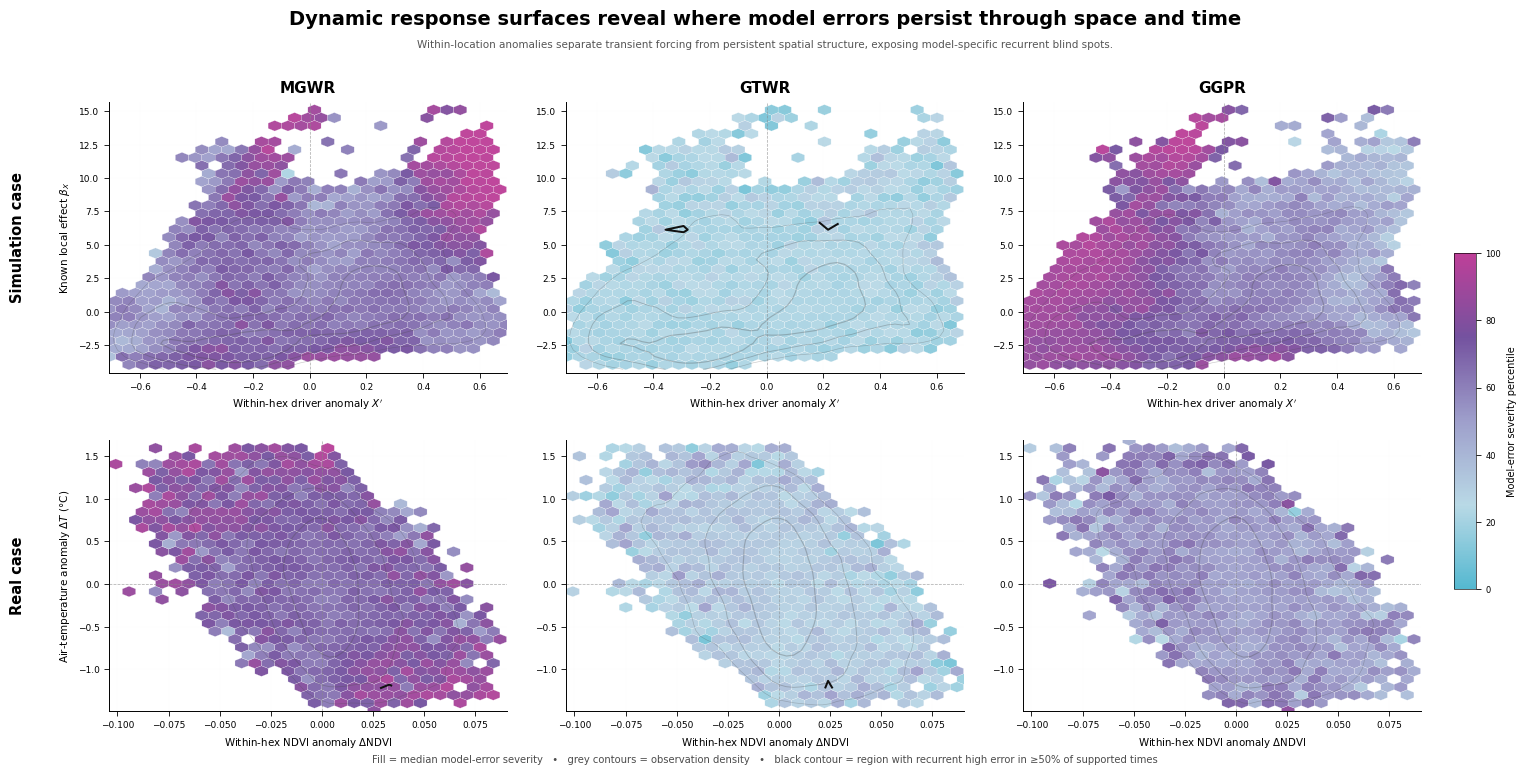


✅ FIGURE 10 REDESIGN COMPLETE
Output: /content/GVSTMR_MODELWISE_GVSTMR/final_main_figures/FIGURE_10_DYNAMIC_RESPONSE_SURFACES_FINAL
NO MODEL REFIT.
NO GOOGLE DRIVE WRITE.


In [ ]:
# ================================================================================================
# FIGURE 10 — FINAL VISUAL REDESIGN
#
# PROCESS–ENVIRONMENT RESPONSE SURFACES AND RECURRENT MODEL BLIND SPOTS
#
# Uses existing ALL dictionary from the successful previous Figure-10 preparation cell.
#
# SIMULATION:
#   X-axis = within-hex anomaly of simulated X
#   Y-axis = known TRUE_BETA_X / PROC_Y
#
# REAL:
#   X-axis = within-hex NDVI anomaly
#   Y-axis = within-hex air-temperature anomaly
#
# COLOR:
#   median absolute-error severity percentile
#
# GREY CONTOURS:
#   observation density
#
# BLACK CONTOUR:
#   recurrent high-error region
#
# NO MODEL FIT
# NO GOOGLE DRIVE WRITE
# ================================================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.ndimage import gaussian_filter

warnings.filterwarnings("ignore")


# ================================================================================================
# 0. INPUT
# ================================================================================================

if "ALL" not in globals():

    if (
        "SIM_DATA" in globals()
        and
        "REAL_DATA" in globals()
    ):

        ALL = {
            "SIMULATION":
                SIM_DATA,

            "REAL":
                REAL_DATA,
        }

    else:

        raise RuntimeError(
            "ALL is not in memory.\n"
            "Run the previous successful Figure-10 data-preparation cell once; "
            "this replacement cell does NOT refit any model."
        )


MODELS = [
    "MGWR",
    "GTWR",
    "GGPR",
]


ROOT = Path(
    "/content/GVSTMR_MODELWISE_GVSTMR"
)

FIG_ROOT = (
    ROOT
    /
    "final_main_figures"
)

TABLE_ROOT = (
    ROOT
    /
    "final_period_tables"
)

FIG_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================================================
# 1. PALETTE
# ================================================================================================

GV = {
    1: "#E5E4E9",
    2: "#B9D9E6",
    3: "#54B8D0",
    4: "#DB95CB",
    5: "#9E9FCB",
    6: "#4582BB",
    7: "#BE3F98",
    8: "#74529F",
    9: "#243A83",
}


ERROR_CMAP = LinearSegmentedColormap.from_list(
    "GVSTMR_ERROR",
    [
        GV[3],
        GV[2],
        GV[5],
        GV[8],
        GV[7],
    ]
)


# ================================================================================================
# 2. CLEAN AND CREATE RESPONSE VARIABLES
# ================================================================================================

DATA = {
    "SIMULATION": {},
    "REAL": {},
}


for case in [
    "SIMULATION",
    "REAL",
]:

    for model in MODELS:

        d = ALL[
            case
        ][
            model
        ].copy()

        d["HEX_ID"] = (
            d["HEX_ID"]
            .astype(str)
        )

        for c in [
            "T",
            "PROC_X",
            "PROC_Y",
            "MODEL_VALUE",
            "OBS_VALUE",
        ]:

            d[c] = pd.to_numeric(
                d[c],
                errors="coerce"
            )

        d = d.replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan
        )

        d = d.dropna(
            subset=[
                "HEX_ID",
                "T",
                "PROC_X",
                "PROC_Y",
                "MODEL_VALUE",
                "OBS_VALUE",
            ]
        ).copy()

        d["ABS_ERROR"] = np.abs(
            d["MODEL_VALUE"]
            -
            d["OBS_VALUE"]
        )

        # ----------------------------------------------------------------------------------------
        # Dynamic response-space variables
        # ----------------------------------------------------------------------------------------

        if case == "SIMULATION":

            # Remove each hexagon's structural mean X.
            # This isolates time-varying forcing.
            d["RESP_X"] = (
                d["PROC_X"]
                -
                d.groupby(
                    "HEX_ID"
                )[
                    "PROC_X"
                ].transform(
                    "mean"
                )
            )

            # known structural effect
            d["RESP_Y"] = (
                d["PROC_Y"]
            )

        else:

            # NDVI anomaly
            d["RESP_X"] = (
                d["PROC_X"]
                -
                d.groupby(
                    "HEX_ID"
                )[
                    "PROC_X"
                ].transform(
                    "mean"
                )
            )

            # air-temperature anomaly
            d["RESP_Y"] = (
                d["PROC_Y"]
                -
                d.groupby(
                    "HEX_ID"
                )[
                    "PROC_Y"
                ].transform(
                    "mean"
                )
            )

        DATA[
            case
        ][
            model
        ] = d


# ================================================================================================
# 3. COMMON ERROR PERCENTILE PER CASE
#
# Thus colors are directly comparable between MGWR / GTWR / GGPR.
# ================================================================================================

ERROR_REF = {}


for case in [
    "SIMULATION",
    "REAL",
]:

    values = np.concatenate(
        [
            DATA[
                case
            ][
                model
            ][
                "ABS_ERROR"
            ].to_numpy(float)
            for model in MODELS
        ]
    )

    values = values[
        np.isfinite(values)
    ]

    ERROR_REF[
        case
    ] = np.sort(
        values
    )


def error_percentile(
    values,
    reference
):

    values = np.asarray(
        values,
        float
    )

    return (
        100.0
        *
        np.searchsorted(
            reference,
            values,
            side="right"
        )
        /
        len(reference)
    )


for case in [
    "SIMULATION",
    "REAL",
]:

    for model in MODELS:

        d = DATA[
            case
        ][
            model
        ]

        d["ERROR_PCTL"] = (
            error_percentile(
                d["ABS_ERROR"],
                ERROR_REF[
                    case
                ]
            )
        )


# ================================================================================================
# 4. BALANCE TIME FOR VISUALIZATION
#
# Every year / simulation step contributes the same number of points.
# ================================================================================================

RNG = np.random.default_rng(
    123
)


def balance_times(
    df,
    max_per_time=4500
):

    groups = []

    counts = (
        df.groupby("T")
        .size()
    )

    n_take = min(
        int(
            counts.min()
        ),
        max_per_time
    )

    for t, q in df.groupby(
        "T"
    ):

        if len(q) > n_take:

            idx = RNG.choice(
                q.index.to_numpy(),
                size=n_take,
                replace=False
            )

            q = q.loc[idx]

        groups.append(
            q
        )

    return pd.concat(
        groups,
        ignore_index=True
    )


BAL = {
    case: {
        model:
            balance_times(
                DATA[
                    case
                ][
                    model
                ]
            )
        for model in MODELS
    }
    for case in [
        "SIMULATION",
        "REAL",
    ]
}


# ================================================================================================
# 5. COMMON AXIS LIMITS PER CASE
#
# Robust 1st–99th percentiles remove extreme tails without changing the calculations.
# ================================================================================================

LIMITS = {}


for case in [
    "SIMULATION",
    "REAL",
]:

    xx = np.concatenate(
        [
            BAL[
                case
            ][
                m
            ][
                "RESP_X"
            ].to_numpy(float)
            for m in MODELS
        ]
    )

    yy = np.concatenate(
        [
            BAL[
                case
            ][
                m
            ][
                "RESP_Y"
            ].to_numpy(float)
            for m in MODELS
        ]
    )

    xlo, xhi = np.nanquantile(
        xx,
        [
            0.01,
            0.99,
        ]
    )

    ylo, yhi = np.nanquantile(
        yy,
        [
            0.01,
            0.99,
        ]
    )

    xpad = (
        xhi - xlo
    ) * 0.04

    ypad = (
        yhi - ylo
    ) * 0.04

    LIMITS[
        case
    ] = (
        xlo - xpad,
        xhi + xpad,
        ylo - ypad,
        yhi + ypad,
    )


# ================================================================================================
# 6. RECURRENT HIGH-ERROR SURFACE
#
# For each time:
#   - bin response space
#   - identify cells whose median error is in the top 10% for that time
#
# Across time:
#   recurrence = fraction of times the cell was high-error
# ================================================================================================

def recurrent_surface(
    df,
    extent,
    nx=22,
    ny=18
):

    xmin, xmax, ymin, ymax = extent

    xedges = np.linspace(
        xmin,
        xmax,
        nx + 1
    )

    yedges = np.linspace(
        ymin,
        ymax,
        ny + 1
    )

    times = sorted(
        df["T"].unique()
    )

    recurrent = np.zeros(
        (
            nx,
            ny
        ),
        float
    )

    support = np.zeros(
        (
            nx,
            ny
        ),
        float
    )

    for t in times:

        q = df.loc[
            df["T"].eq(t)
        ].copy()

        q = q.loc[
            q["RESP_X"].between(
                xmin,
                xmax
            )
            &
            q["RESP_Y"].between(
                ymin,
                ymax
            )
        ]

        if len(q) == 0:
            continue

        q["XB"] = pd.cut(
            q["RESP_X"],
            bins=xedges,
            labels=False,
            include_lowest=True
        )

        q["YB"] = pd.cut(
            q["RESP_Y"],
            bins=yedges,
            labels=False,
            include_lowest=True
        )

        g = (
            q.dropna(
                subset=[
                    "XB",
                    "YB",
                ]
            )
            .groupby(
                [
                    "XB",
                    "YB",
                ],
                as_index=False
            )
            .agg(
                MED_ERROR=(
                    "ERROR_PCTL",
                    "median"
                ),
                N=(
                    "ERROR_PCTL",
                    "size"
                ),
            )
        )

        # sufficient observations only
        g = g.loc[
            g["N"] >= 8
        ]

        if len(g) == 0:
            continue

        cut = g[
            "MED_ERROR"
        ].quantile(
            0.90
        )

        for _, row in g.iterrows():

            i = int(
                row["XB"]
            )

            j = int(
                row["YB"]
            )

            support[
                i,
                j
            ] += 1

            if (
                row["MED_ERROR"]
                >=
                cut
            ):

                recurrent[
                    i,
                    j
                ] += 1

    recurrence = np.divide(
        recurrent,
        support,
        out=np.full_like(
            recurrent,
            np.nan
        ),
        where=support > 0
    )

    support_fraction = (
        support
        /
        max(
            len(times),
            1
        )
    )

    recurrence[
        support_fraction
        <
        0.40
    ] = np.nan

    xc = (
        xedges[:-1]
        +
        xedges[1:]
    ) / 2

    yc = (
        yedges[:-1]
        +
        yedges[1:]
    ) / 2

    return (
        recurrence,
        xc,
        yc
    )


# ================================================================================================
# 7. DENSITY SURFACE
# ================================================================================================

def density_surface(
    df,
    extent,
    nx=55,
    ny=42
):

    xmin, xmax, ymin, ymax = extent

    H, xedge, yedge = np.histogram2d(
        df["RESP_X"],
        df["RESP_Y"],
        bins=[
            nx,
            ny,
        ],
        range=[
            [
                xmin,
                xmax,
            ],
            [
                ymin,
                ymax,
            ],
        ]
    )

    H = gaussian_filter(
        H.astype(float),
        sigma=1.25
    )

    xc = (
        xedge[:-1]
        +
        xedge[1:]
    ) / 2

    yc = (
        yedge[:-1]
        +
        yedge[1:]
    ) / 2

    return (
        H,
        xc,
        yc
    )


# ================================================================================================
# 8. DRAW PANEL
# ================================================================================================

def draw_panel(
    ax,
    case,
    model
):

    d = BAL[
        case
    ][
        model
    ].copy()

    xmin, xmax, ymin, ymax = (
        LIMITS[
            case
        ]
    )

    d = d.loc[
        d["RESP_X"].between(
            xmin,
            xmax
        )
        &
        d["RESP_Y"].between(
            ymin,
            ymax
        )
    ].copy()

    # --------------------------------------------------------------------------------------------
    # Main error surface
    # --------------------------------------------------------------------------------------------

    hb = ax.hexbin(
        d["RESP_X"],
        d["RESP_Y"],
        C=d["ERROR_PCTL"],
        gridsize=30,
        extent=[
            xmin,
            xmax,
            ymin,
            ymax,
        ],
        reduce_C_function=np.nanmedian,
        mincnt=8,
        cmap=ERROR_CMAP,
        vmin=0,
        vmax=100,
        linewidths=0.16,
        edgecolors="white",
        alpha=0.96
    )

    # --------------------------------------------------------------------------------------------
    # Density contours
    # --------------------------------------------------------------------------------------------

    H, dx, dy = density_surface(
        d,
        (
            xmin,
            xmax,
            ymin,
            ymax,
        )
    )

    positive = H[
        H > 0
    ]

    if len(positive) > 20:

        levels = np.quantile(
            positive,
            [
                0.60,
                0.80,
                0.93,
            ]
        )

        levels = np.unique(
            levels
        )

        if len(levels) >= 2:

            XX, YY = np.meshgrid(
                dx,
                dy,
                indexing="ij"
            )

            ax.contour(
                XX,
                YY,
                H,
                levels=levels,
                colors="#4A4A4A",
                linewidths=[
                    0.45,
                    0.65,
                    0.85,
                ][
                    :len(levels)
                ],
                alpha=0.30
            )

    # --------------------------------------------------------------------------------------------
    # Recurrent blind-spot contour
    # --------------------------------------------------------------------------------------------

    recurrence, rx, ry = (
        recurrent_surface(
            d,
            (
                xmin,
                xmax,
                ymin,
                ymax,
            )
        )
    )

    finite_rec = recurrence[
        np.isfinite(
            recurrence
        )
    ]

    if (
        len(finite_rec) > 10
        and
        np.nanmax(
            finite_rec
        ) >= 0.50
    ):

        RX, RY = np.meshgrid(
            rx,
            ry,
            indexing="ij"
        )

        try:

            ax.contour(
                RX,
                RY,
                recurrence,
                levels=[
                    0.50
                ],
                colors="#111111",
                linewidths=1.45,
                linestyles="-"
            )

        except Exception:
            pass

    ax.axvline(
        0,
        color="#888888",
        lw=0.55,
        ls="--",
        alpha=0.65
    )

    if case == "REAL":

        ax.axhline(
            0,
            color="#888888",
            lw=0.55,
            ls="--",
            alpha=0.65
        )

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.set_ylim(
        ymin,
        ymax
    )

    ax.tick_params(
        labelsize=6.5
    )

    ax.grid(
        alpha=0.055,
        linewidth=0.35
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    return hb


# ================================================================================================
# 9. FIGURE
# ================================================================================================

fig = plt.figure(
    figsize=(
        15.8,
        8.4
    ),
    facecolor="white"
)

gs = fig.add_gridspec(
    2,
    3,
    left=0.085,
    right=0.915,
    bottom=0.13,
    top=0.855,
    wspace=0.15,
    hspace=0.25
)


AX = {}


for r, case in enumerate(
    [
        "SIMULATION",
        "REAL",
    ]
):

    AX[
        case
    ] = {}

    for c, model in enumerate(
        MODELS
    ):

        AX[
            case
        ][
            model
        ] = fig.add_subplot(
            gs[
                r,
                c
            ]
        )


# ================================================================================================
# 10. DRAW ALL PANELS
# ================================================================================================

for model in MODELS:

    draw_panel(
        AX[
            "SIMULATION"
        ][
            model
        ],
        "SIMULATION",
        model
    )

    draw_panel(
        AX[
            "REAL"
        ][
            model
        ],
        "REAL",
        model
    )


# ================================================================================================
# 11. MODEL TITLES
# ================================================================================================

for model in MODELS:

    AX[
        "SIMULATION"
    ][
        model
    ].set_title(
        model,
        fontsize=11,
        fontweight="bold",
        pad=7
    )


# ================================================================================================
# 12. LABELS
# ================================================================================================

for model in MODELS:

    AX[
        "SIMULATION"
    ][
        model
    ].set_xlabel(
        r"Within-hex driver anomaly $X'$",
        fontsize=7.4
    )

    AX[
        "REAL"
    ][
        model
    ].set_xlabel(
        r"Within-hex NDVI anomaly $\Delta$NDVI",
        fontsize=7.4
    )


AX[
    "SIMULATION"
][
    "MGWR"
].set_ylabel(
    r"Known local effect $\beta_X$",
    fontsize=7.5
)


AX[
    "REAL"
][
    "MGWR"
].set_ylabel(
    r"Air-temperature anomaly $\Delta T$ (°C)",
    fontsize=7.5
)


for model in [
    "GTWR",
    "GGPR",
]:

    AX[
        "SIMULATION"
    ][
        model
    ].set_ylabel(
        ""
    )

    AX[
        "REAL"
    ][
        model
    ].set_ylabel(
        ""
    )


# ================================================================================================
# 13. ROW LABELS
# ================================================================================================

fig.canvas.draw()


for case, label in [
    (
        "SIMULATION",
        "Simulation case",
    ),
    (
        "REAL",
        "Real case",
    ),
]:

    p = AX[
        case
    ][
        "MGWR"
    ].get_position()

    yc = (
        p.y0 + p.y1
    ) / 2

    fig.text(
        0.027,
        yc,
        label,
        rotation=90,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )


# ================================================================================================
# 14. COLORBAR
# ================================================================================================

cax = fig.add_axes(
    [
        0.936,
        0.275,
        0.014,
        0.40,
    ]
)

sm = mpl.cm.ScalarMappable(
    cmap=ERROR_CMAP,
    norm=Normalize(
        0,
        100
    )
)

cb = fig.colorbar(
    sm,
    cax=cax
)

cb.set_label(
    "Model-error severity percentile",
    fontsize=7
)

cb.ax.tick_params(
    labelsize=6
)

cb.outline.set_linewidth(
    0.45
)


# ================================================================================================
# 15. EXPLANATION KEY
# ================================================================================================

fig.text(
    0.50,
    0.068,
    "Fill = median model-error severity   •   "
    "grey contours = observation density   •   "
    "black contour = region with recurrent high error in ≥50% of supported times",
    ha="center",
    fontsize=7.2,
    color="#4C4C4C"
)


# ================================================================================================
# 16. TITLE
# ================================================================================================

fig.suptitle(
    "Dynamic response surfaces reveal where model errors persist through space and time",
    fontsize=14,
    fontweight="bold",
    y=0.965
)

fig.text(
    0.50,
    0.920,
    "Within-location anomalies separate transient forcing from persistent spatial structure, exposing model-specific recurrent blind spots.",
    ha="center",
    fontsize=7.5,
    color="#555555"
)


# ================================================================================================
# 17. SAVE
# ================================================================================================

OUTBASE = (
    FIG_ROOT
    /
    "FIGURE_10_DYNAMIC_RESPONSE_SURFACES_FINAL"
)

for ext in [
    "png",
    "tif",
]:

    fig.savefig(
        f"{OUTBASE}.{ext}",
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

fig.savefig(
    f"{OUTBASE}.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close(fig)


print("\n" + "=" * 105)
print("✅ FIGURE 10 REDESIGN COMPLETE")
print("=" * 105)

print("Output:", OUTBASE)
print("NO MODEL REFIT.")
print("NO GOOGLE DRIVE WRITE.")